# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of two diffusion-based synthetic data generation models:
1. **TabDDPM** - Conditional Tabular GAN plus
2. **ForestDiffusion** - Forest-based diffusion for tabular data

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# Generating synthetic data

In [1]:
# Diffusion model dependencies
# TabDDPM: yandex-research/tab-ddpm (_vendor/tab-ddpm)
# ForestDiffusion: pip install ForestDiffusion
# libzero/rtdl pin torch<2; use --no-deps on torch 2.x (TabDDPM still works)
%pip install -q ForestDiffusion xgboost category-encoders imbalanced-learn absl-py tensorboardX icecream dython optuna skorch pyarrow tomli tomli-w
%pip install -q "pynvml>=11,<12"
%pip install -q "libzero==0.0.8" "rtdl==0.0.13" --no-deps

import sys
from pathlib import Path

NOTEBOOK_DIR = Path(".").resolve()
REPO_ROOT = next(
    (p for p in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
     if (p / "_vendor" / "tab-ddpm").is_dir()),
    NOTEBOOK_DIR.parents[1],
)
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm"))
sys.path.insert(0, str(REPO_ROOT / "_vendor" / "tab-ddpm" / "scripts"))
sys.path.insert(0, str(NOTEBOOK_DIR))

# Verify vendored TabDDPM checkouts (see README Setup)
_vendor_missing = [
    p.name for p in [
        REPO_ROOT / "_vendor" / "tab-ddpm",
    ]
    if not p.exists()
]
if _vendor_missing:
    raise FileNotFoundError(
        "Missing _vendor checkouts: "
        + ", ".join(_vendor_missing)
        + ". Clone per README: git clone https://github.com/yandex-research/tab-ddpm _vendor/tab-ddpm"
    )

from diffusion_generators import (
    MODEL_ORDER,
    train_tabddpm,
    train_forestdiffusion,
)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

# -----------------------------
# Load Covertype dataset (UCI id=31)
# -----------------------------
covertype = fetch_ucirepo(id=31)
X = covertype.data.features
y = covertype.data.targets
data = pd.concat([X, y], axis=1)
target_col = y.columns[0]

binary_columns = [
    col for col in X.columns if col.startswith(("Wilderness_Area", "Soil_Type"))
]

# Benchmark subsample + leak-safe split
_bench_n = min(1000, len(data))
data = data.sample(n=_bench_n, random_state=42).reset_index(drop=True)

_strat = data[target_col] if data[target_col].nunique() <= 30 else None
train_real, test_real = train_test_split(
    data, test_size=0.2, random_state=42, stratify=_strat,
)

# Diffusion models (TabDDPM, ForestDiffusion)
SYNTHETIC_N = 1000
DIFFUSION_SEED = 42
_categorical_columns = binary_columns

print("Training TabDDPM...")
synthetic_tabddpm = train_tabddpm(
    train_real,
    target_col=target_col,
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)
print("Training ForestDiffusion...")
synthetic_forestdiffusion = train_forestdiffusion(
    train_real,
    target_col=target_col,
    categorical_columns=_categorical_columns,
    n_samples=SYNTHETIC_N,
    seed=DIFFUSION_SEED,
)

synthetic_outputs = {
    "TabDDPM": synthetic_tabddpm,
    "ForestDiffusion": synthetic_forestdiffusion,
}
model_order = ["TabDDPM", "ForestDiffusion"]

Training TabDDPM...
[0]
97
{'num_classes': 7, 'is_y_cond': False, 'rtdl_params': {'d_layers': [256, 256, 256], 'dropout': 0.0}, 'd_in': np.int64(97)}
mlp
Step 500/1000 MLoss: 0.0 GLoss: 0.3557 Sum: 0.3557
Step 1000/1000 MLoss: 0.0 GLoss: 0.2838 Sum: 0.2838
mlp
Sample timestep    0
Discrete cols: []
Num shape:  (1000, 10)
Training ForestDiffusion...


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Target standardized as 'Cover_Type'
Real data shape: (1000, 55)
Target column count: 1
Columns: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology']... Cover_Type

--- Evaluating TabDDPM ---
55 common columns aligned
Cover_Type present: True
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 1975.75it/s]|
Column Shapes Score: 10.43%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:03<00:00, 469.30it/s]|
Column Pair Trends Score: 10.05%

Overall Score (Average): 10.24%


--- Evaluating ForestDiffusion ---
55 common columns aligned
Cover_Type present: True
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 1307.03it/s]|
Column Shapes Score: 18.89%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:03<00:00, 471.00it/s]|
Column Pair Trends Score: 13.11%

Overall Score (Average): 16.0%


=== MODEL RANKING ===


,Model,Avg_Column_Score,Cover_Type_Score,Rank
1,ForestDiffusion,0.1889,0.985,55
0,TabDDPM,0.1043,0.979,55



=== Cover_Type DISTRIBUTION ===
Real proportions: {1: np.float64(0.353), 2: np.float64(0.483), 3: np.float64(0.074), 4: np.float64(0.002), 5: np.float64(0.021), 6: np.float64(0.035), 7: np.float64(0.032)}


,Real,TabDDPM,ForestDiffusion
Cover_Type,,,
1,353,362,354
2,483,479,469
3,74,58,86
4,2,1,2
5,21,24,20
6,35,37,37
7,32,39,32


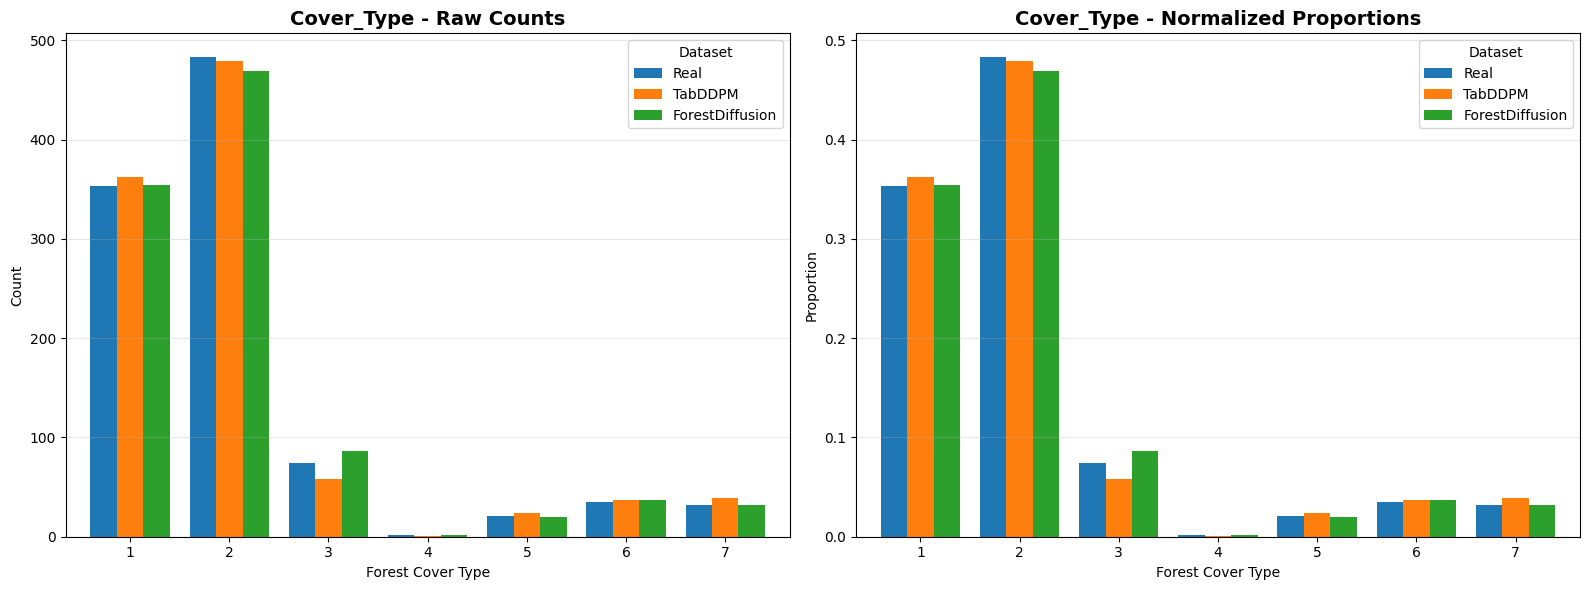

/tmp/ipykernel_3559824/3387534390.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3559824/3387534390.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


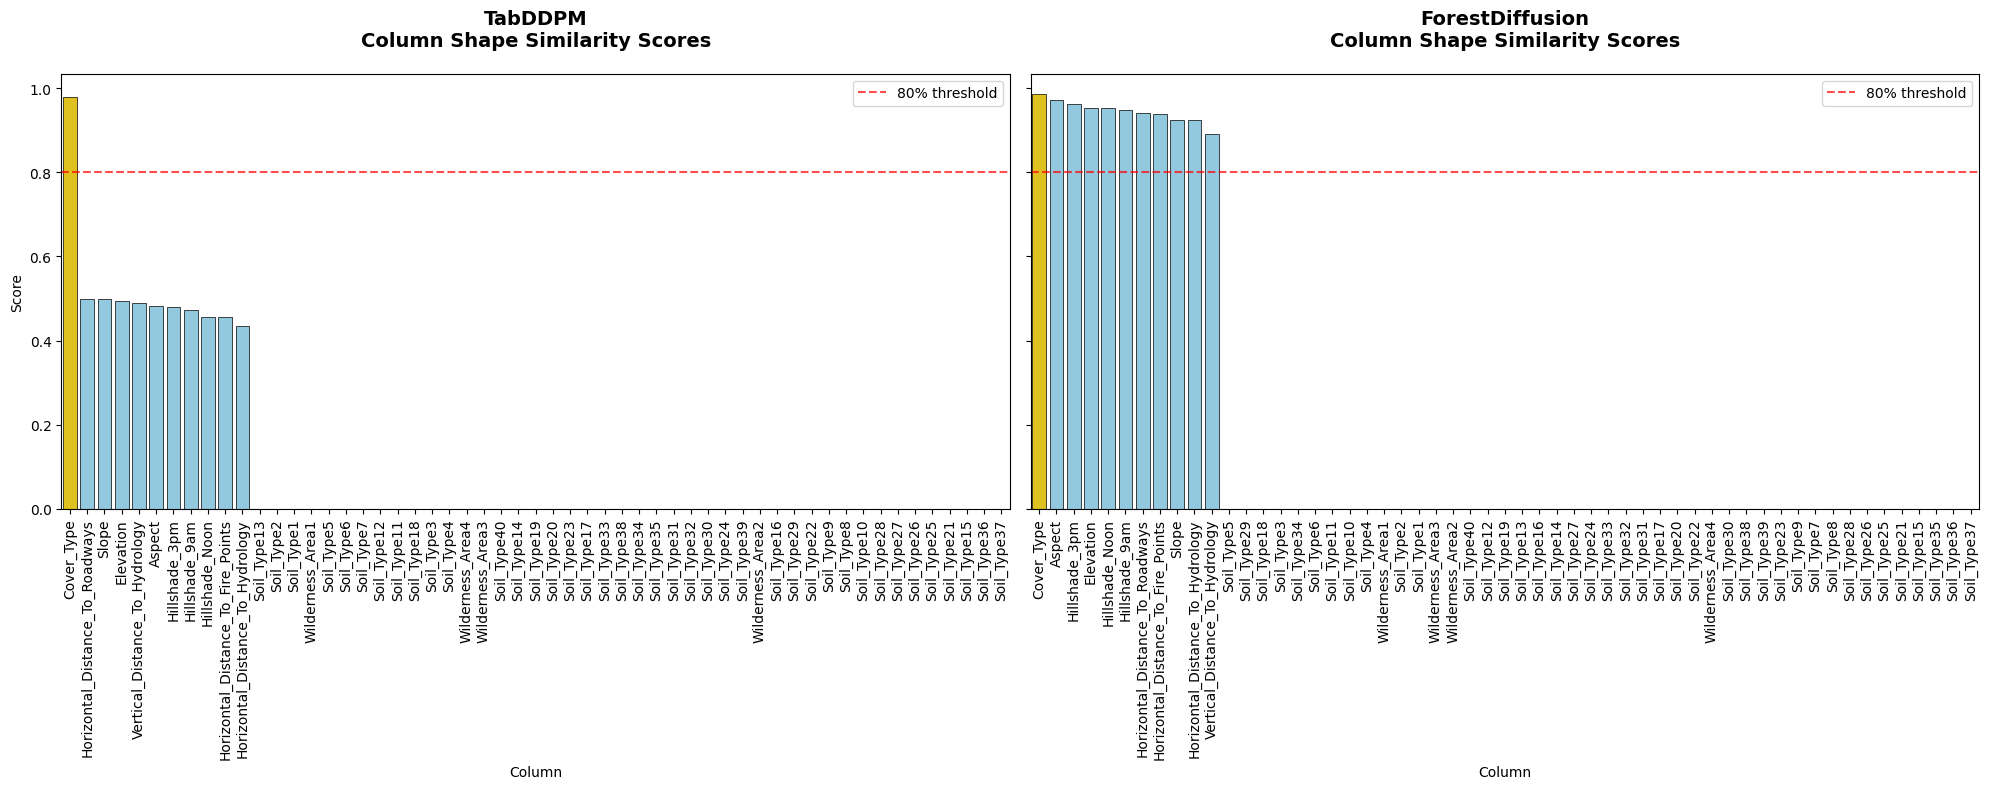


=== DETAILED COLUMN SHAPES (Top 20, Cover_Type highlighted) ===


,Column,Metric,Score,Model
0,Cover_Type,TVComplement,0.979000,TabDDPM
1,Horizontal_Distance_To_Roadways,KSComplement,0.499000,TabDDPM
2,Slope,KSComplement,0.498000,TabDDPM
3,Elevation,KSComplement,0.493000,TabDDPM
4,Vertical_Distance_To_Hydrology,KSComplement,0.488000,TabDDPM
5,Aspect,KSComplement,0.482000,TabDDPM
6,Hillshade_3pm,KSComplement,0.480000,TabDDPM
7,Hillshade_9am,KSComplement,0.472000,TabDDPM
8,Hillshade_Noon,KSComplement,0.457000,TabDDPM
9,Horizontal_Distance_To_Fire_Points,KSComplement,0.456000,TabDDPM



=== SAVING REPORTS ===
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 1967.43it/s]|
Column Shapes Score: 10.43%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:03<00:00, 463.00it/s]|
Column Pair Trends Score: 10.05%

Overall Score (Average): 10.24%

covertype_quality_report_tabddpm.html
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 55/55 [00:00<00:00, 1976.36it/s]|
Column Shapes Score: 18.89%

(2/2) Evaluating Column Pair Trends: |██████████| 1485/1485 [00:03<00:00, 476.90it/s]|
Column Pair Trends Score: 13.11%

Overall Score (Average): 16.0%

covertype_quality_report_forestdiffusion.html
covertype_class_distributions.csv

=== EVALUATION COMPLETE ===
Key metrics to check:
1. Cover_Type distribution match (proportions chart)
2. Average column shape scores (>0.8 = good)
3. Cover_Type specific scores (should be highest priority)
4. HTML reports for full SDV analysis


In [10]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sdv.metadata import SingleTableMetadata

# -----------------------------
# 1. Use cleaned real data + standardize Cover_Type target
# -----------------------------
real_data = data.copy()
target_col = "Cover_Type"

# Rename only if Cover_Type is missing, using the last column as target
if target_col not in real_data.columns:
    old_target_col = real_data.columns[-1]
    real_data = real_data.rename(columns={old_target_col: target_col})

real_data = real_data.loc[:, ~real_data.columns.duplicated()].copy()

# Standardize synthetic outputs
for model_name in synthetic_outputs:
    synth_df = synthetic_outputs[model_name].copy()

    if target_col not in synth_df.columns:
        synth_old_target_col = synth_df.columns[-1]
        synth_df = synth_df.rename(columns={synth_old_target_col: target_col})

    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()
    synthetic_outputs[model_name] = synth_df


def _normalize_labels(series, reference=None):
    """Align label dtypes so value_counts/sort_index do not mix strings and ints."""
    ref = pd.Series(reference).reset_index(drop=True) if reference is not None else pd.Series(series)
    ref_num = pd.to_numeric(ref, errors="coerce")
    if ref_num.notna().all():
        return pd.to_numeric(series, errors="coerce").round().astype(int)
    return pd.Series(series).astype(str)


real_data[target_col] = _normalize_labels(real_data[target_col])
for model_name in synthetic_outputs:
    synthetic_outputs[model_name][target_col] = _normalize_labels(
        synthetic_outputs[model_name][target_col],
        reference=real_data[target_col],
    )


def _align_dtypes_to_reference(df, reference):
    """Coerce synthetic columns to match real dtypes (fixes str vs int floats)."""
    out = df.copy()
    for col in reference.columns:
        if col not in out.columns:
            continue
        if pd.api.types.is_numeric_dtype(reference[col]):
            out[col] = pd.to_numeric(out[col], errors="coerce")
        elif pd.api.types.is_bool_dtype(reference[col]):
            out[col] = out[col].astype(bool)
        else:
            out[col] = out[col].astype(str)
    return out


for model_name in synthetic_outputs:
    synthetic_outputs[model_name] = _align_dtypes_to_reference(
        synthetic_outputs[model_name], real_data
    )


def _coerce_numeric_df(df, cols):
    """Ensure feature columns are numeric before stats/scaling."""
    out = df[cols].copy()
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out.replace([np.inf, -np.inf], np.nan)


# Alias used by downstream evaluation cells (JS, Wasserstein, t-SNE, etc.)
real_sample = real_data.copy()

print(f"Target standardized as '{target_col}'")
print(f"Real data shape: {real_data.shape}")
print(f"Target column count: {(real_data.columns == target_col).sum()}")
print(f"Columns: {list(real_data.columns[:5])}... {target_col}")

# Detect metadata and mark Cover_Type as categorical
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)
metadata.update_column(
    column_name=target_col,
    sdtype="categorical"
)

model_order = ["TabDDPM", "ForestDiffusion"]
column_shape_details = {}
summary_rows = {}

# -----------------------------
# 2. Generate QualityReport for each model
# -----------------------------
for model_name in model_order:
    print(f"\n--- Evaluating {model_name} ---")

    qr = QualityReport()
    synthetic_data = synthetic_outputs[model_name].copy()

    common_cols = real_data.columns.intersection(synthetic_data.columns)
    real_eval = real_data[common_cols].copy()
    synth_eval = synthetic_data[common_cols].copy()

    # Use metadata only for aligned columns
    eval_metadata = SingleTableMetadata()
    eval_metadata.detect_from_dataframe(real_eval)
    eval_metadata.update_column(
        column_name=target_col,
        sdtype="categorical"
    )

    print(f"{len(common_cols)} common columns aligned")
    print(f"Cover_Type present: {target_col in real_eval.columns}")

    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=eval_metadata.to_dict()
    )

    details = qr.get_details("Column Shapes")
    score_col = "Score" if "Score" in details.columns else "Quality Score"
    details = details.sort_values(score_col, ascending=False)
    column_shape_details[model_name] = details

    target_score = (
        float(details.loc[details["Column"] == target_col, score_col].iloc[0])
        if target_col in details["Column"].values
        else "N/A"
    )

    summary_rows[model_name] = {
        "Model": model_name,
        "Avg_Column_Score": float(details[score_col].mean()),
        f"{target_col}_Score": target_score,
        "Rank": len(details)
    }

# -----------------------------
# 3. Summary table
# -----------------------------
summary_df = pd.DataFrame(summary_rows.values()).sort_values(
    "Avg_Column_Score", ascending=False
)

print("\n=== MODEL RANKING ===")
display(summary_df.round(4))

# -----------------------------
# 4. Cover_Type class distribution analysis
# -----------------------------
print(f"\n=== {target_col} DISTRIBUTION ===")

class_dist = pd.DataFrame({
    "Real": real_data[target_col].value_counts().sort_index(),
    "TabDDPM": synthetic_outputs["TabDDPM"][target_col].value_counts().sort_index(),
    "ForestDiffusion": synthetic_outputs["ForestDiffusion"][target_col].value_counts().sort_index()
}).fillna(0).astype(int)

real_props = real_data[target_col].value_counts(normalize=True).sort_index().round(3)
print("Real proportions:", dict(real_props))
display(class_dist)

# -----------------------------
# 5. Visualize Cover_Type distributions
# -----------------------------
fig, axes = plt.subplots(1, len(model_order), figsize=(16, 6))

class_dist.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title(f"{target_col} - Raw Counts", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].legend(title="Dataset", frameon=True)
axes[0].grid(axis="y", alpha=0.3)

class_dist.div(class_dist.sum(axis=0), axis=1).plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title(f"{target_col} - Normalized Proportions", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="Dataset", frameon=True)
axes[1].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.set_xlabel("Forest Cover Type")

plt.tight_layout()
plt.show()

# -----------------------------
# 6. Column shape comparison plots
# -----------------------------
fig, axes = plt.subplots(1, len(model_order), figsize=(20, 8), sharey=True)

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    score_col = "Score" if "Score" in details.columns else "Quality Score"

    colors = [
        "gold" if row == target_col else "skyblue"
        for row in details["Column"]
    ]

    sns.barplot(
        x="Column",
        y=score_col,
        data=details,
        palette=colors,
        ax=ax,
        edgecolor="black",
        linewidth=0.5
    )

    ax.set_title(
        f"{model_name}\nColumn Shape Similarity Scores",
        fontsize=14,
        fontweight="bold",
        pad=20
    )
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(y=0.8, color="red", linestyle="--", alpha=0.7, label="80% threshold")
    ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 7. Detailed column shapes table
# -----------------------------
print(f"\n=== DETAILED COLUMN SHAPES (Top 20, {target_col} highlighted) ===")

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)

score_col = "Score" if "Score" in combined_details.columns else "Quality Score"

def highlight_cover_type(row):
    if row["Column"] == target_col:
        return [
            "background-color: #ffeb3b" if col in ["Column", score_col] else ""
            for col in row.index
        ]
    return [""] * len(row)

styled_df = combined_details.head(20).style.apply(highlight_cover_type, axis=1)
display(styled_df)

# -----------------------------
# 8. Save comprehensive reports
# -----------------------------
print("\n=== SAVING REPORTS ===")

for model_name in model_order:
    qr = QualityReport()
    synthetic_data = synthetic_outputs[model_name].copy()
    common_cols = real_data.columns.intersection(synthetic_data.columns)

    real_eval = real_data[common_cols].copy()
    synth_eval = synthetic_data[common_cols].copy()

    eval_metadata = SingleTableMetadata()
    eval_metadata.detect_from_dataframe(real_eval)
    eval_metadata.update_column(
        column_name=target_col,
        sdtype="categorical"
    )

    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=eval_metadata.to_dict()
    )

    filename = f"covertype_quality_report_{model_name.lower().replace('_', '')}.html"
    qr.save(filename)
    print(f"{filename}")

class_dist.to_csv("covertype_class_distributions.csv")
print("covertype_class_distributions.csv")

print("\n=== EVALUATION COMPLETE ===")
print("Key metrics to check:")
print("1. Cover_Type distribution match (proportions chart)")
print("2. Average column shape scores (>0.8 = good)")
print("3. Cover_Type specific scores (should be highest priority)")
print("4. HTML reports for full SDV analysis")


### 1.2. Jensen–Shannon divergence

In [11]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

Computing JS divergence for TabDDPM...
Computing JS divergence for ForestDiffusion...


/tmp/ipykernel_3559824/4269298144.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_3559824/4269298144.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


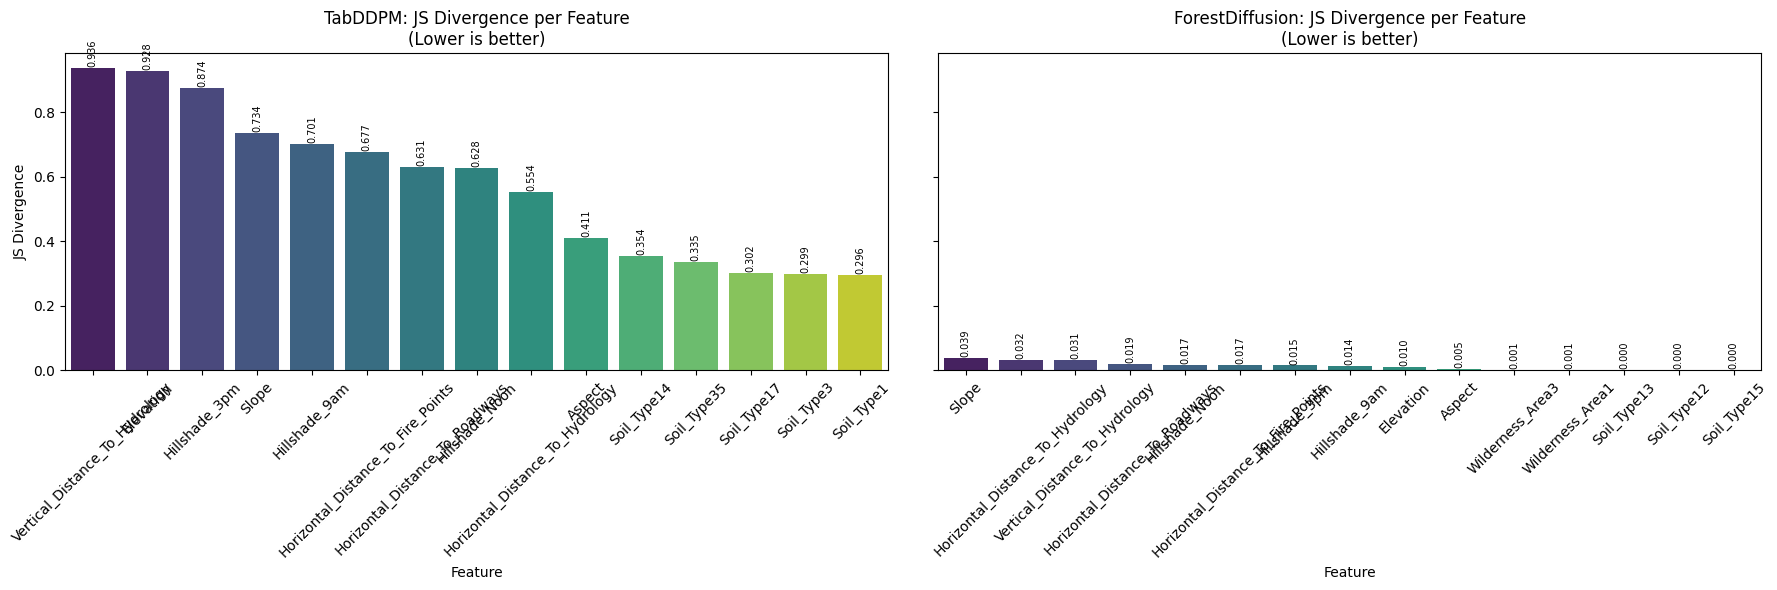

Top 20 features by JS Divergence:


,Feature,JS_Divergence,Model
0,Vertical_Distance_To_Hydrology,0.936194,TabDDPM
1,Elevation,0.928193,TabDDPM
2,Hillshade_3pm,0.874489,TabDDPM
3,Slope,0.734322,TabDDPM
4,Hillshade_9am,0.700810,TabDDPM
5,Horizontal_Distance_To_Fire_Points,0.677258,TabDDPM
6,Horizontal_Distance_To_Roadways,0.631303,TabDDPM
7,Hillshade_Noon,0.627868,TabDDPM
8,Horizontal_Distance_To_Hydrology,0.553702,TabDDPM
9,Aspect,0.411071,TabDDPM



Model Comparison Summary (Lower JS = Better):


,Model,Mean_JS,Median_JS,Max_JS,Features_with_JS_gt_0.1
1,ForestDiffusion,0.003717,0.000000,0.039346,0
0,TabDDPM,0.214195,0.153967,0.936194,29


In [12]:
# Use the real_sample from previous cell (1000 rows)
real_df = real_sample.drop(columns=[target_col])

model_order = ["TabDDPM", "ForestDiffusion"]
js_results_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])

    print(f"Computing JS divergence for {model_name}...")
    js_df = compute_js_divergence(
        real_df,
        synth_df,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)

    js_results_by_model[model_name] = js_df

# -----------------------------
# Plot JS Divergence
# -----------------------------
fig, axes = plt.subplots(1, len(model_order), figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df.head(15),  # Top 15 features for cleaner plot
        palette="viridis",
        ax=ax
    )

    # Add value labels on bars
    for bar in bars.patches:
        yval = bar.get_height()
        if not np.isnan(yval):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval + 0.003,
                f"{yval:.3f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=90
            )

    ax.set_title(f"{model_name}: JS Divergence per Feature\n(Lower is better)", fontsize=12)
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# -----------------------------
# Summary table
# -----------------------------
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)

print("Top 20 features by JS Divergence:")
display(all_js.head(20))

# -----------------------------
# Model comparison summary
# -----------------------------
summary_stats = []
for model_name, js_df in js_results_by_model.items():
    valid_js = js_df["JS_Divergence"].dropna()
    summary_stats.append({
        "Model": model_name,
        "Mean_JS": valid_js.mean(),
        "Median_JS": valid_js.median(),
        "Max_JS": valid_js.max(),
        "Features_with_JS_gt_0.1": (valid_js > 0.1).sum()
    })

summary_df = pd.DataFrame(summary_stats).sort_values("Mean_JS")
print("\nModel Comparison Summary (Lower JS = Better):")
display(summary_df)


### 1.3 Wasserstein Distance


Numeric columns (54): ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology']...
Categorical columns (0): []...

Using 54 numeric features for Wasserstein distance

Computing Wasserstein distances...

TabDDPM - Wasserstein Distance (numeric features only):
  Elevation      : 0.3801
  Aspect         : 0.2282
  Slope          : 0.3367
  Horizontal_Distance_To_Hydrology: 0.4146
  Vertical_Distance_To_Hydrology: 0.3728
  Horizontal_Distance_To_Roadways: 0.3170
  Hillshade_9am  : 0.2955
  Hillshade_Noon : 0.3786
  Hillshade_3pm  : 0.3287
  Horizontal_Distance_To_Fire_Points: 0.3223
  Wilderness_Area1: 0.2260
  Soil_Type1     : 0.5070
  Soil_Type2     : 0.4400
  Soil_Type3     : 0.5130
  Soil_Type4     : 0.4490
  Soil_Type5     : 0.4810
  Soil_Type6     : 0.4720
  Soil_Type7     : 0.4940
  Soil_Type8     : 0.0000
  Soil_Type9     : 0.0000
  Soil_Type10    : 0.0690
  Soil_Type11    : 0.5000
  Soil_Type12    : 0.4170
  Soil_Type13    : 0.4610
  So

,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein,Num_Valid_Features
0,ForestDiffusion,0.007472,0.0020,0.031,54
1,TabDDPM,0.313269,0.4005,0.557,54


/tmp/ipykernel_3559824/193278229.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
/tmp/ipykernel_3559824/193278229.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


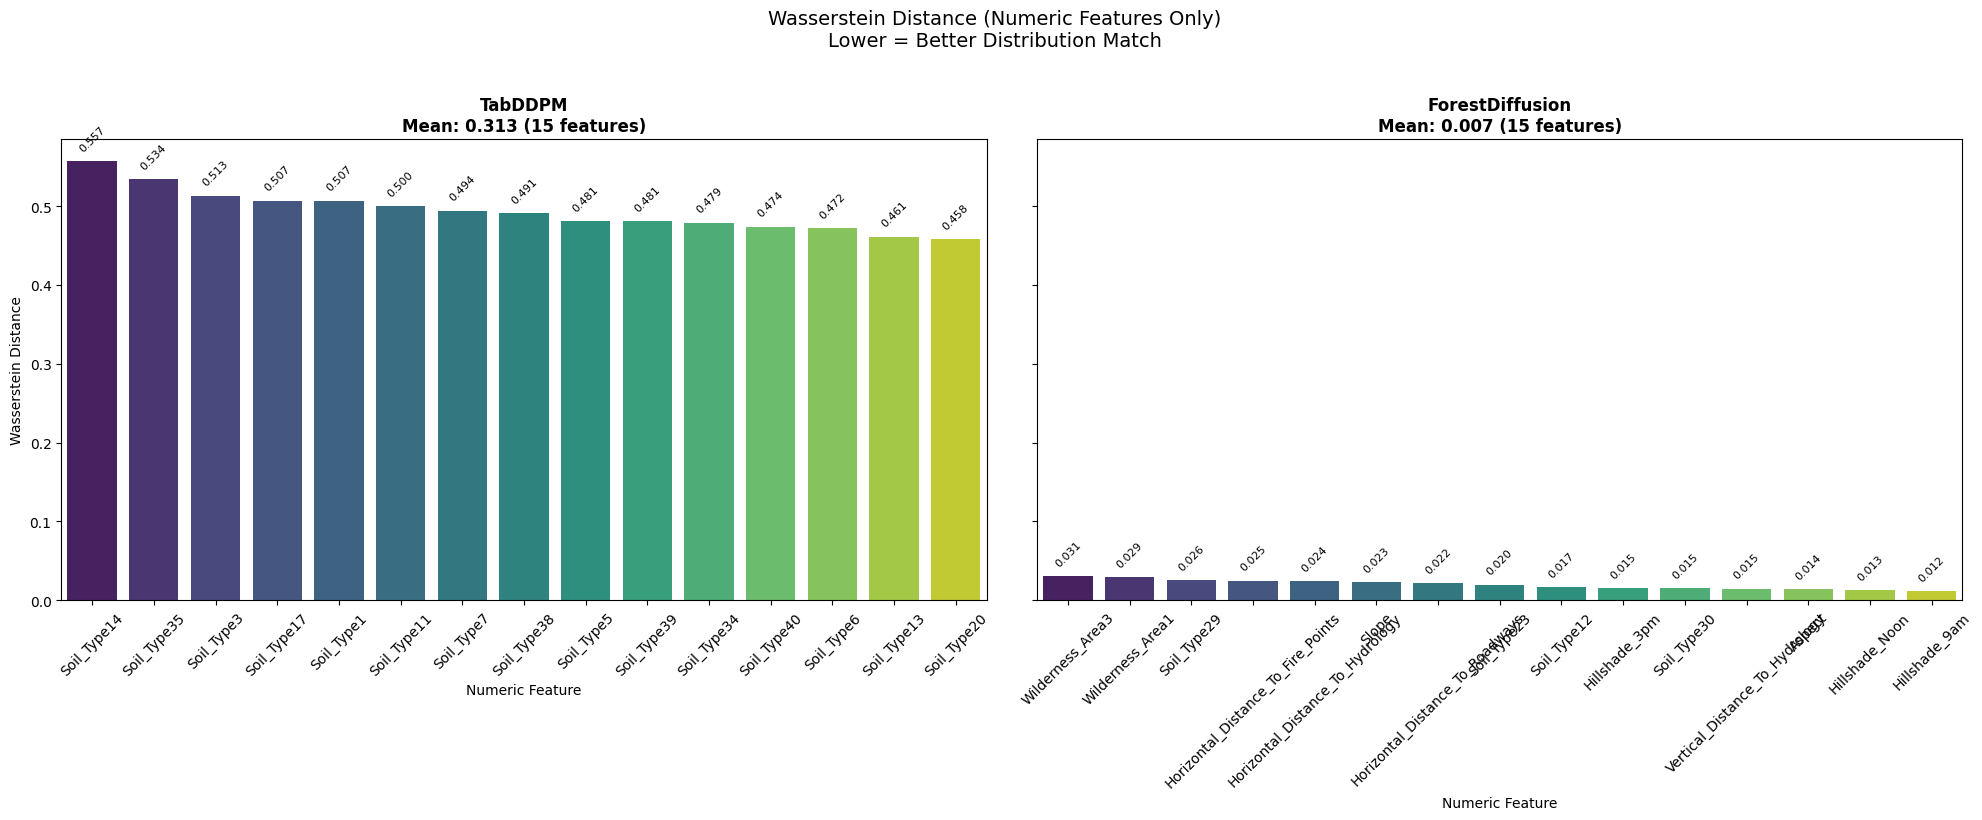


Top 20 numeric features by Wasserstein Distance:


,Feature,Wasserstein_Distance,Model
0,Soil_Type14,0.557,TabDDPM
1,Soil_Type35,0.534,TabDDPM
2,Soil_Type3,0.513,TabDDPM
3,Soil_Type17,0.507,TabDDPM
4,Soil_Type1,0.507,TabDDPM
5,Soil_Type11,0.500,TabDDPM
6,Soil_Type7,0.494,TabDDPM
7,Soil_Type38,0.491,TabDDPM
8,Soil_Type5,0.481,TabDDPM
9,Soil_Type39,0.481,TabDDPM


In [14]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

# Use real_sample and target_col from previous generation cell
real_df = real_sample.drop(columns=[target_col])

# -----------------------------
# SEPARATE NUMERIC AND CATEGORICAL COLUMNS
# -----------------------------
numeric_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = real_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:5]}...")

# Only use NUMERIC columns for Wasserstein (skip categorical)
def _coerce_numeric_df(df, cols):
    """Ensure synthetic/real feature columns are numeric before stats."""
    out = df[cols].copy()
    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


real_numeric = _coerce_numeric_df(real_df, numeric_cols)
real_numeric = real_numeric.fillna(real_numeric.median(numeric_only=True))
print(f"\nUsing {len(numeric_cols)} numeric features for Wasserstein distance")

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_numeric),
    columns=numeric_cols,
    index=real_numeric.index
)

wasserstein_by_model = {}
summary_rows = []

print("\nComputing Wasserstein distances...\n")

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    synth_numeric = _coerce_numeric_df(synth_df, numeric_cols)
    synth_numeric = synth_numeric.fillna(real_numeric.median(numeric_only=True))

    # Scale synthetic data using real data's scaler
    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols,
        index=synth_numeric.index
    )

    dists = []
    print(f"{model_name} - Wasserstein Distance (numeric features only):")

    for col in numeric_cols:
        try:
            real_col = real_scaled[col].dropna()
            synth_col = synthetic_scaled[col].dropna()

            if len(real_col) > 1 and len(synth_col) > 1:
                dist = wasserstein_distance(real_col, synth_col)
                dists.append((col, float(dist)))
                print(f"  {col:15}: {dist:.4f}")
            else:
                dists.append((col, np.nan))
                print(f"  {col:15}: NaN (insufficient data)")
        except Exception as e:
            dists.append((col, np.nan))
            print(f"  {col:15}: NaN (error: {str(e)[:30]})")

    # FIXED: Remove na_last parameter for older pandas
    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)

    wasserstein_by_model[model_name] = dist_df

    valid_dists = dist_df["Wasserstein_Distance"].dropna()
    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": valid_dists.mean() if len(valid_dists) > 0 else np.nan,
        "Median_Wasserstein": valid_dists.median() if len(valid_dists) > 0 else np.nan,
        "Max_Wasserstein": valid_dists.max() if len(valid_dists) > 0 else np.nan,
        "Num_Valid_Features": len(valid_dists)
    })

# FIXED: Remove na_last parameter
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot TOP 15 numeric features only
fig, axes = plt.subplots(1, len(model_order), figsize=(20, 8), sharey=True)

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name].dropna().head(15)

    if len(df_plot) > 0:
        bars = sns.barplot(
            x="Feature",
            y="Wasserstein_Distance",
            data=df_plot,
            palette="viridis",
            ax=ax
        )

        # Add value labels
        for bar in bars.patches:
            yval = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval + 0.01,
                f"{yval:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=45
            )

        mean_ws = summary_df[summary_df['Model']==model_name]['Mean_Wasserstein'].iloc[0]
        ax.set_title(f"{model_name}\nMean: {mean_ws:.3f} ({len(df_plot)} features)",
                    fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No numeric data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(model_name)

    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Numeric Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.suptitle("Wasserstein Distance (Numeric Features Only)\nLower = Better Distribution Match",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# FIXED: Remove na_last parameter
all_wasserstein = pd.concat(
    [df.assign(Model=name) for name, df in wasserstein_by_model.items()],
    ignore_index=True
).sort_values("Wasserstein_Distance", ascending=False)

print("\nTop 20 numeric features by Wasserstein Distance:")
display(all_wasserstein.head(20))


### 1.4 Gower Distance

In [ ]:
pip install gower

In [15]:
import numpy as np
import pandas as pd
import gower
from IPython.display import display

data = real_sample.copy()
model_order = ["TabDDPM", "ForestDiffusion"]
target_col = data.columns[-1]

X_real = data.drop(columns=[target_col], errors="ignore")

def prepare_for_gower(real_df, synth_df):
    common_cols = real_df.columns.intersection(synth_df.columns)
    Xr = real_df[common_cols].reset_index(drop=True).copy()
    Xs = synth_df[common_cols].reset_index(drop=True).copy()

    for col in common_cols:
        real_numeric = pd.api.types.is_numeric_dtype(Xr[col])
        synth_numeric = pd.api.types.is_numeric_dtype(Xs[col])

        if real_numeric or synth_numeric:
            Xr[col] = pd.to_numeric(Xr[col], errors="coerce").astype(float)
            Xs[col] = pd.to_numeric(Xs[col], errors="coerce").astype(float)

            fill_value = Xr[col].median()
            if pd.isna(fill_value):
                fill_value = 0.0

            Xr[col] = Xr[col].fillna(fill_value)
            Xs[col] = Xs[col].fillna(fill_value)
        else:
            Xr[col] = Xr[col].astype(str).fillna("Missing")
            Xs[col] = Xs[col].astype(str).fillna("Missing")

    return Xr, Xs, common_cols

gower_results = []

print("Computing Gower distances (mixed data)...\n")

for model_name in model_order:
    X_synth = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    Xr, Xs, common_cols = prepare_for_gower(X_real, X_synth)

    print(f"{model_name}: {len(Xr)} real vs {len(Xs)} synth samples, {len(common_cols)} features")

    try:
        gower_real = 1 - gower.gower_matrix(Xr)
        gower_synth = 1 - gower.gower_matrix(Xs)

        real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
        synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

        max_intra_real = np.max(real_upper)
        avg_intra_real = np.mean(real_upper)
        max_intra_synth = np.max(synth_upper)
        avg_intra_synth = np.mean(synth_upper)

        combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
        gower_combined = 1 - gower.gower_matrix(combined)

        n_real = len(Xr)
        cross_block = gower_combined[:n_real, n_real:]

        max_cross = np.max(cross_block)
        avg_cross = np.mean(cross_block)

        print(f"\n{model_name} - Gower Similarity:")
        print("Intra-set Similarity (Real):")
        print(f"  Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}")
        print("Intra-set Similarity (Synthetic):")
        print(f"  Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}")
        print("Cross-set Similarity (Real vs Synthetic):")
        print(f"  Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

        gower_results.append({
            "Model": model_name,
            "Max_Intra_Real": max_intra_real,
            "Avg_Intra_Real": avg_intra_real,
            "Max_Intra_Synth": max_intra_synth,
            "Avg_Intra_Synth": avg_intra_synth,
            "Max_Cross_Real_vs_Synth": max_cross,
            "Avg_Cross_Real_vs_Synth": avg_cross,
        })

    except Exception as e:
        print(f"Error computing Gower for {model_name}: {e}")
        continue

if gower_results:
    gower_summary_df = pd.DataFrame(gower_results)
    print("\nGower Similarity Summary:")
    print("(Higher similarity = better; ideal: synth intra ≈ real intra ≈ cross)")
    display(gower_summary_df)

    for _, row in gower_summary_df.iterrows():
        model = row["Model"]
        real_avg = row["Avg_Intra_Real"]
        synth_avg = row["Avg_Intra_Synth"]
        cross_avg = row["Avg_Cross_Real_vs_Synth"]

        print(f"\n{model} interpretation:")
        if abs(synth_avg - real_avg) < 0.05 and abs(cross_avg - real_avg) < 0.05:
            print("Good: Synthetic matches real data distribution")
        elif synth_avg > real_avg * 1.1:
            print("Synthetic data is less diverse than real")
        elif cross_avg < real_avg * 0.8:
            print("Poor: Synthetic does not resemble real data")
        else:
            print("Moderate quality")
else:
    print("No valid Gower results computed")


Computing Gower distances (mixed data)...

TabDDPM: 1000 real vs 1000 synth samples, 54 features

TabDDPM - Gower Similarity:
Intra-set Similarity (Real):
  Max = 0.9985, Avg = 0.9078
Intra-set Similarity (Synthetic):
  Max = 0.9815, Avg = 0.6320
Cross-set Similarity (Real vs Synthetic):
  Max = 0.9468, Avg = 0.6337
ForestDiffusion: 1000 real vs 1000 synth samples, 54 features

ForestDiffusion - Gower Similarity:
Intra-set Similarity (Real):
  Max = 0.9985, Avg = 0.9078
Intra-set Similarity (Synthetic):
  Max = 0.9981, Avg = 0.9121
Cross-set Similarity (Real vs Synthetic):
  Max = 0.9997, Avg = 0.9119

Gower Similarity Summary:
(Higher similarity = better; ideal: synth intra ≈ real intra ≈ cross)


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,TabDDPM,0.998498,0.90781,0.981481,0.631983,0.946805,0.633701
1,ForestDiffusion,0.998498,0.90781,0.998081,0.912063,0.999739,0.911891



TabDDPM interpretation:
Poor: Synthetic does not resemble real data

ForestDiffusion interpretation:
Good: Synthetic matches real data distribution


### 1.5 t-SNE Visualization


Using 54 numeric features for t-SNE: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology']...


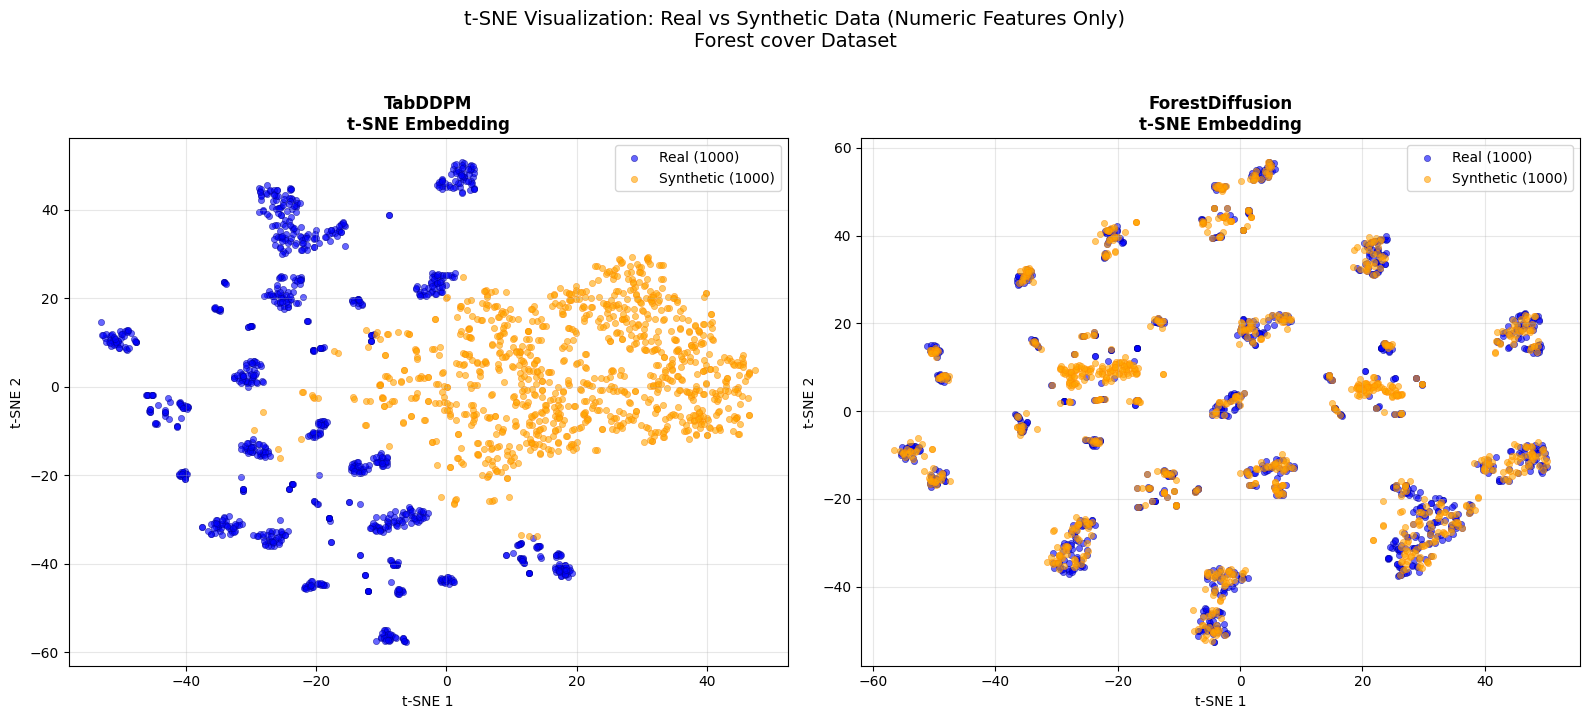


Overlap Analysis:
TabDDPM: Centroid distance = 2.797
Good overlap
ForestDiffusion: Centroid distance = 2.797
Good overlap


In [17]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Forest Cover dataset
model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = "Cover_Type"

# Remove target and separate numeric/categorical
X_real = data.drop(columns=[target_col], errors="ignore")

# -----------------------------
# USE ONLY NUMERIC COLUMNS (like before)
# -----------------------------
numeric_cols = X_real.select_dtypes(include=[np.number]).columns.tolist()
print(f"Using {len(numeric_cols)} numeric features for t-SNE: {numeric_cols[:5]}...")

X_real_numeric = _coerce_numeric_df(X_real, numeric_cols)
real_medians = X_real_numeric.median(numeric_only=True)
X_real_numeric = X_real_numeric.fillna(real_medians)

# Scale numeric data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(X_real_numeric),
    columns=numeric_cols,
    index=X_real_numeric.index
)

# Create t-SNE plots
fig, axes = plt.subplots(1, len(model_order), figsize=(16, 7))
axes = axes.flatten()

for i, model_name in enumerate(model_order):
    ax = axes[i]

    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    synth_numeric = _coerce_numeric_df(synth_df, numeric_cols)
    synth_numeric = synth_numeric.fillna(real_medians)

    # Scale synthetic data using real scaler
    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols,
        index=synth_numeric.index
    )

    # Combine real + synthetic
    combined = np.vstack([
        real_scaled.values,
        synthetic_scaled.values
    ])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(combined)

    # Plot
    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=20, label="Real (1000)",
        edgecolors='darkblue', linewidth=0.5
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=20, label="Synthetic (1000)",
        edgecolors='darkorange', linewidth=0.5
    )

    ax.set_title(f"{model_name}\nt-SNE Embedding", fontsize=12, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("t-SNE Visualization: Real vs Synthetic Data (Numeric Features Only)\nForest cover Dataset",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print overlap statistics
print("\nOverlap Analysis:")
for model_name in model_order:
    # Simple convex hull overlap check (optional advanced metric)
    real_points = tsne_result[labels == "Real"][:1000]  # First 1000 real points
    synth_points = tsne_result[labels == "Synthetic"][:1000]  # First 1000 synth points

    # Distance between centroids
    real_center = np.mean(real_points, axis=0)
    synth_center = np.mean(synth_points, axis=0)
    centroid_dist = np.linalg.norm(real_center - synth_center)

    print(f"{model_name}: Centroid distance = {centroid_dist:.3f}")
    if centroid_dist < 5:
        print("Good overlap")
    else:
        print("Limited overlap")

### 1.6 MMD (Maximum Mean Discrepancy)


In [18]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = "Cover_Type"

# Real features (exclude target) - NUMERIC COLUMNS ONLY
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = _coerce_numeric_df(real_features, numeric_cols)
real_medians = X_real.median(numeric_only=True)
X_real = X_real.fillna(real_medians)

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = _coerce_numeric_df(synth_df, numeric_cols)
    X_synth = X_synth.fillna(real_medians)

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Lower MMD is better
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

TabDDPM - MMD score: 0.5110
ForestDiffusion - MMD score: 0.0034

MMD comparison (lower is better):


,Model,MMD_Score
0,ForestDiffusion,0.003424
1,TabDDPM,0.511001


### 1.7 Cosine Similarity


In [19]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = "Cover_Type"

# Real features (exclude target) - NUMERIC COLUMNS ONLY
real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = _coerce_numeric_df(real_features, numeric_cols)
real_medians = X_real.median(numeric_only=True)
X_real = X_real.fillna(real_medians)

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = _coerce_numeric_df(synth_df, numeric_cols)
    X_synth = X_synth.fillna(real_medians)

    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)



TabDDPM - Sample-Level Similarity:
Average cosine similarity: -0.0209
Maximum cosine similarity: 0.9600

ForestDiffusion - Sample-Level Similarity:
Average cosine similarity: 0.0048
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,ForestDiffusion,0.004782,0.999996
1,TabDDPM,-0.020852,0.960009


### 1.8 Nearest Neighbours


In [20]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]
data = real_sample.copy()
target_col = "Cover_Type"

real_features = data.drop(columns=[target_col], errors="ignore")
numeric_cols = real_features.select_dtypes(include=[np.number]).columns.tolist()
X_real = _coerce_numeric_df(real_features, numeric_cols)
real_medians = X_real.median(numeric_only=True)
X_real = X_real.fillna(real_medians)

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")
    X_synth = _coerce_numeric_df(synth_df, numeric_cols)
    X_synth = X_synth.fillna(real_medians)

    # Scale using real data statistics
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Nearest-neighbor privacy check: Synthetic -> Real
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)



TabDDPM - Privacy Check:
Average NN Distance (Synthetic -> Real): 43.7629
Minimum NN Distance (Synthetic -> Real): 6.5260
5th Percentile NN Distance: 15.2445

ForestDiffusion - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.9364
Minimum NN Distance (Synthetic -> Real): 0.0314
5th Percentile NN Distance: 0.5008

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,TabDDPM,43.762868,6.526011,15.244545
1,ForestDiffusion,1.936433,0.031350,0.500801


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,5790.181813,568.236715,317.150983
1,ForestDiffusion,28.684330,11.507937,23.838702


/tmp/ipykernel_3559824/3606113473.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
/tmp/ipykernel_3559824/3606113473.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
/tmp/ipykernel_3559824/3606113473.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")


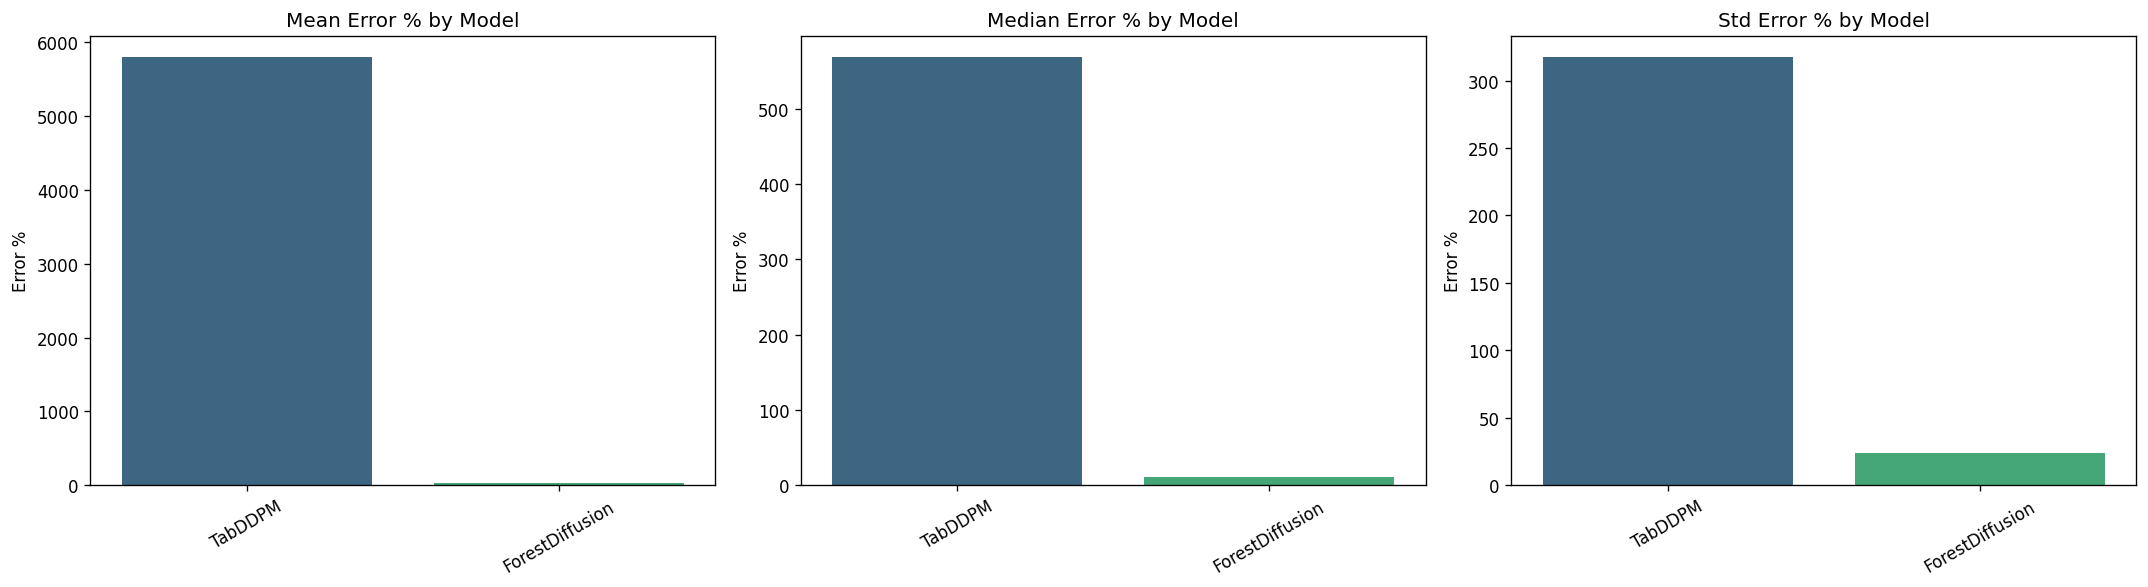

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

data = real_sample.copy()
data = data.loc[:, ~data.columns.duplicated()].copy()

target_col = "Cover_Type"

real_df = data.copy()
real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    common_num_cols = [
        col for col in num_cols
        if col in synth_df.columns
    ]

    real_num = real_df[common_num_cols].copy()
    synth_num = synth_df[common_num_cols].copy()

    real_num = real_num.apply(pd.to_numeric, errors="coerce")
    synth_num = synth_num.apply(pd.to_numeric, errors="coerce")

    real_num = real_num.fillna(real_num.median(numeric_only=True))
    synth_num = synth_num.fillna(synth_num.median(numeric_only=True))

    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (
        np.abs(synth_means - real_means)
        / real_means.replace(0, np.nan).abs()
    ) * 100

    std_error_pct = (
        np.abs(synth_stds - real_stds)
        / real_stds.replace(0, np.nan).abs()
    ) * 100

    feature_error_df = pd.DataFrame({
        "Feature": common_num_cols,
        "Mean_Error_%": [mean_error_pct.get(col, np.nan) for col in common_num_cols],
        "Std_Error_%": [std_error_pct.get(col, np.nan) for col in common_num_cols]
    }).replace([np.inf, -np.inf], np.nan)

    summary_rows.append({
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    })

    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


/tmp/ipykernel_3559824/3873890449.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")


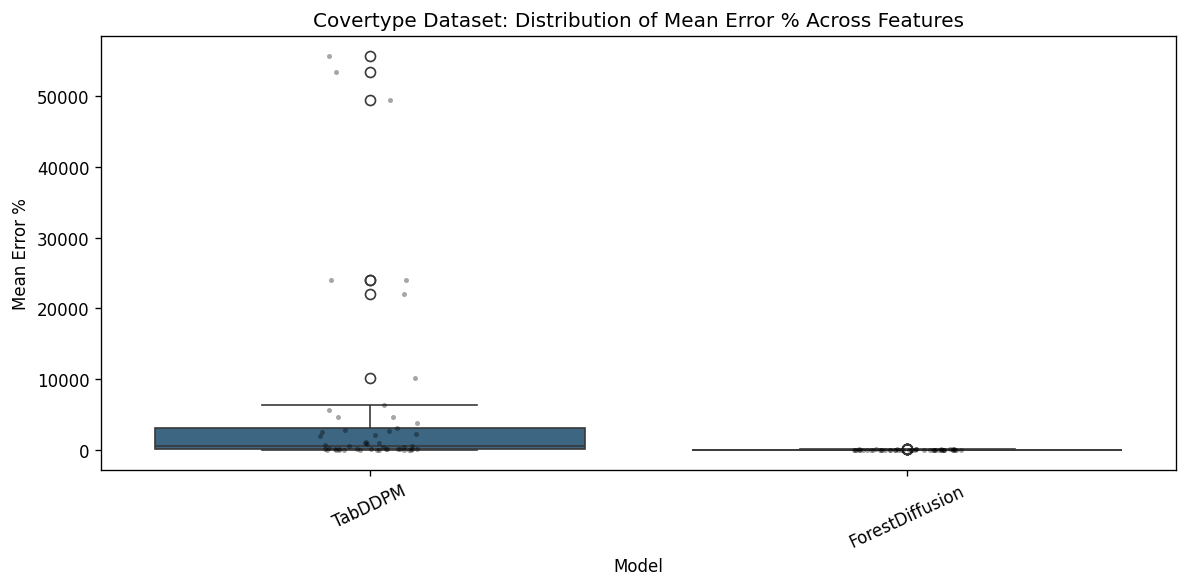

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["TabDDPM", "ForestDiffusion"]

plot_rows = [
    feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
    for m in model_list
    if m in feature_error_by_model and not feature_error_by_model[m].empty
]

if plot_rows:
    dist_df = (
        pd.concat(plot_rows, ignore_index=True)
        .replace([float("inf"), float("-inf")], pd.NA)
        .dropna(subset=["Mean_Error_%"])
    )

    plt.figure(figsize=(10, 5), dpi=120)
    sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
    sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)

    plt.title("Covertype Dataset: Distribution of Mean Error % Across Features")
    plt.xlabel("Model")
    plt.ylabel("Mean Error %")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
else:
    print("No feature error results available. Run the previous error-summary cell first.")


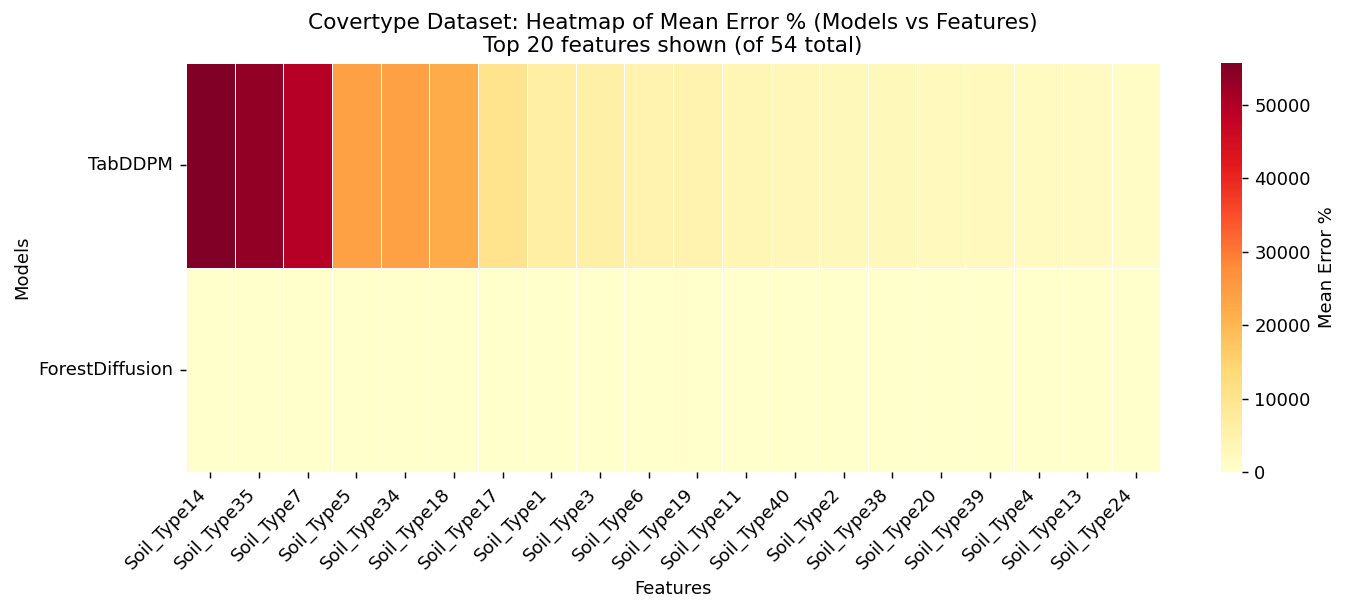

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

heatmap_rows = {}

for m in model_order:
    if m in feature_error_by_model and not feature_error_by_model[m].empty:
        temp = feature_error_by_model[m][["Feature", "Mean_Error_%"]].copy()
        temp = temp.drop_duplicates(subset="Feature", keep="first")
        temp["Mean_Error_%"] = pd.to_numeric(temp["Mean_Error_%"], errors="coerce")
        heatmap_rows[m] = temp.set_index("Feature")["Mean_Error_%"]

if heatmap_rows:
    heatmap_df = pd.DataFrame(heatmap_rows).T
    heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

    max_features = 20

    if heatmap_df.shape[1] > max_features:
        top_features = (
            heatmap_df.mean(axis=0, skipna=True)
            .sort_values(ascending=False)
            .head(max_features)
            .index
        )
        heatmap_plot_df = heatmap_df[top_features]
        truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
    else:
        heatmap_plot_df = heatmap_df.copy()
        truncated_note = "All features shown"

    def truncate_label(s, max_len=18):
        s = str(s)
        return s if len(s) <= max_len else s[:max_len - 1] + "..."

    display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

    plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)

    sns.heatmap(
        heatmap_plot_df,
        cmap="YlOrRd",
        annot=False,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Mean Error %"}
    )

    plt.title(f"Covertype Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
    plt.xlabel("Features")
    plt.ylabel("Models")
    plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No feature error results available. Run the previous error-summary cell first.")


# 2 Bivariate Analysis


In [24]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality(real_df, synth_df, target="Cover_Type"):
    """Compute bivariate quality metrics for the Forest Cover Type dataset."""

    real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    if target not in real_df.columns or target not in synth_df.columns:
        raise KeyError(f"Target column '{target}' not found in both real_df and synth_df.")

    num_cols = [
        c for c in real_df.columns
        if (
            c != target
            and c in synth_df.columns
            and pd.api.types.is_numeric_dtype(real_df[c])
            and pd.api.types.is_numeric_dtype(synth_df[c])
        )
    ]

    if len(num_cols) < 2:
        empty_corr = pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])
        empty_target = pd.DataFrame(columns=["feature", "delta_wasserstein"])
        return empty_corr, empty_target

    real_scaled = real_df[num_cols].apply(pd.to_numeric, errors="coerce")
    synth_scaled = synth_df[num_cols].apply(pd.to_numeric, errors="coerce")

    real_scaled = real_scaled.fillna(real_scaled.median(numeric_only=True))
    synth_scaled = synth_scaled.fillna(synth_scaled.median(numeric_only=True))

    scaler = MinMaxScaler()
    real_scaled = pd.DataFrame(
        scaler.fit_transform(real_scaled),
        columns=num_cols,
        index=real_scaled.index
    )
    synth_scaled = pd.DataFrame(
        scaler.transform(synth_scaled),
        columns=num_cols,
        index=synth_scaled.index
    )

    results_corr = []
    results_target = []

    # Pairwise numeric correlations
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]

        if pd.notna(r_corr) and pd.notna(s_corr):
            results_corr.append({
                "var_a": a,
                "var_b": b,
                "delta_corr": abs(r_corr - s_corr)
            })

    # Target-conditional Wasserstein distances across all Cover_Type classes
    real_classes = sorted(real_df[target].dropna().unique())
    synth_classes = sorted(synth_df[target].dropna().unique())
    common_classes = sorted(set(real_classes).intersection(set(synth_classes)))

    for col in num_cols:
        class_deltas = []

        for class_a, class_b in combinations(common_classes, 2):
            r_a = pd.to_numeric(real_df.loc[real_df[target] == class_a, col], errors="coerce").dropna()
            r_b = pd.to_numeric(real_df.loc[real_df[target] == class_b, col], errors="coerce").dropna()
            s_a = pd.to_numeric(synth_df.loc[synth_df[target] == class_a, col], errors="coerce").dropna()
            s_b = pd.to_numeric(synth_df.loc[synth_df[target] == class_b, col], errors="coerce").dropna()

            if len(r_a) > 0 and len(r_b) > 0 and len(s_a) > 0 and len(s_b) > 0:
                d_real = stats.wasserstein_distance(r_a, r_b)
                d_synth = stats.wasserstein_distance(s_a, s_b)
                class_deltas.append(abs(d_real - d_synth))

        if class_deltas:
            results_target.append({
                "feature": col,
                "delta_wasserstein": np.mean(class_deltas)
            })

    corr_df = pd.DataFrame(results_corr)
    if not corr_df.empty:
        corr_df = corr_df.sort_values("delta_corr", ascending=False)
    else:
        corr_df = pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])

    target_df = pd.DataFrame(results_target)
    if not target_df.empty:
        target_df = target_df.sort_values("delta_wasserstein", ascending=False)
    else:
        target_df = pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df

In [25]:
import pandas as pd
import numpy as np

model_order = ["TabDDPM", "ForestDiffusion"]

data = real_sample.copy()
data = data.loc[:, ~data.columns.duplicated()].copy()

target_col = "Cover_Type"

if target_col not in data.columns:
    data = data.rename(columns={data.columns[-1]: target_col})

real_df = data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    if target_col not in synth_df.columns:
        synth_df = synth_df.rename(columns={synth_df.columns[-1]: target_col})

    if target_col not in synth_df.columns:
        print(f"Warning: {target_col} not found in synthetic data for {model_name}")
        continue

    corr_df, target_df = bivariate_quality(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_df
    all_target_results[model_name] = target_df

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_df.head(10))

    print("=" * 60)
    print(f"{model_name} - Features that differ most by {target_col} class:")
    display(
        target_df.head(10)
        if not target_df.empty
        else pd.DataFrame({"message": ["No target-conditional features found"]})
    )
    print("=" * 60)

    corr_metric_col = "delta_corr" if "delta_corr" in corr_df.columns else None
    target_metric_col = "delta_wasserstein" if "delta_wasserstein" in target_df.columns else None

    top_corr_diff = corr_df[corr_metric_col].iloc[0] if corr_metric_col and not corr_df.empty else np.nan
    mean_top10_corr_diff = corr_df[corr_metric_col].head(10).mean() if corr_metric_col and not corr_df.empty else np.nan

    top_target_diff = target_df[target_metric_col].iloc[0] if target_metric_col and not target_df.empty else np.nan
    mean_top10_target_diff = target_df[target_metric_col].head(10).mean() if target_metric_col and not target_df.empty else np.nan

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": top_corr_diff,
        "MeanTop10CorrDiff": mean_top10_corr_diff,
        "TopTargetDiff": top_target_diff,
        "MeanTop10TargetDiff": mean_top10_target_diff,
    })

summary_df = pd.DataFrame(summary_rows)

print("\nBivariate Quality Summary")
display(summary_df)



TabDDPM - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
42,Hillshade_Noon,Hillshade_3pm,0.485208
14,Aspect,Hillshade_Noon,0.436089
20,Slope,Hillshade_9am,0.357349
13,Aspect,Hillshade_9am,0.354446
28,Horizontal_Distance_To_Hydrology,Hillshade_3pm,0.311718
27,Horizontal_Distance_To_Hydrology,Hillshade_Noon,0.299485
15,Aspect,Hillshade_3pm,0.297819
21,Slope,Hillshade_Noon,0.295406
6,Elevation,Hillshade_Noon,0.254924
2,Elevation,Horizontal_Distance_To_Hydrology,0.238690


TabDDPM - Features that differ most by Cover_Type class:


,feature,delta_wasserstein
5,Horizontal_Distance_To_Roadways,1213.447818
9,Horizontal_Distance_To_Fire_Points,1106.032411
0,Elevation,407.310735
3,Horizontal_Distance_To_Hydrology,201.699188
4,Vertical_Distance_To_Hydrology,59.956583
1,Aspect,46.653835
7,Hillshade_Noon,25.216901
8,Hillshade_3pm,23.683716
6,Hillshade_9am,19.428932
2,Slope,6.540108



ForestDiffusion - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
24,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,0.094384
16,Aspect,Horizontal_Distance_To_Fire_Points,0.074857
21,Slope,Hillshade_Noon,0.072169
18,Slope,Vertical_Distance_To_Hydrology,0.063809
15,Aspect,Hillshade_3pm,0.056546
22,Slope,Hillshade_3pm,0.053913
44,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,0.052119
29,Horizontal_Distance_To_Hydrology,Horizontal_Distance_To_Fire_Points,0.049778
41,Hillshade_9am,Horizontal_Distance_To_Fire_Points,0.048462
8,Elevation,Horizontal_Distance_To_Fire_Points,0.046243


ForestDiffusion - Features that differ most by Cover_Type class:


,feature,delta_wasserstein
9,Horizontal_Distance_To_Fire_Points,124.418847
5,Horizontal_Distance_To_Roadways,103.775971
0,Elevation,30.107747
3,Horizontal_Distance_To_Hydrology,29.886992
1,Aspect,20.699581
8,Hillshade_3pm,11.344329
4,Vertical_Distance_To_Hydrology,5.417459
6,Hillshade_9am,4.661771
7,Hillshade_Noon,2.385714
2,Slope,1.599442



Bivariate Quality Summary


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,TabDDPM,0.485208,0.333113,1213.447818,310.997023
1,ForestDiffusion,0.094384,0.061228,124.418847,33.429785


### 3 Multivariate Analysis


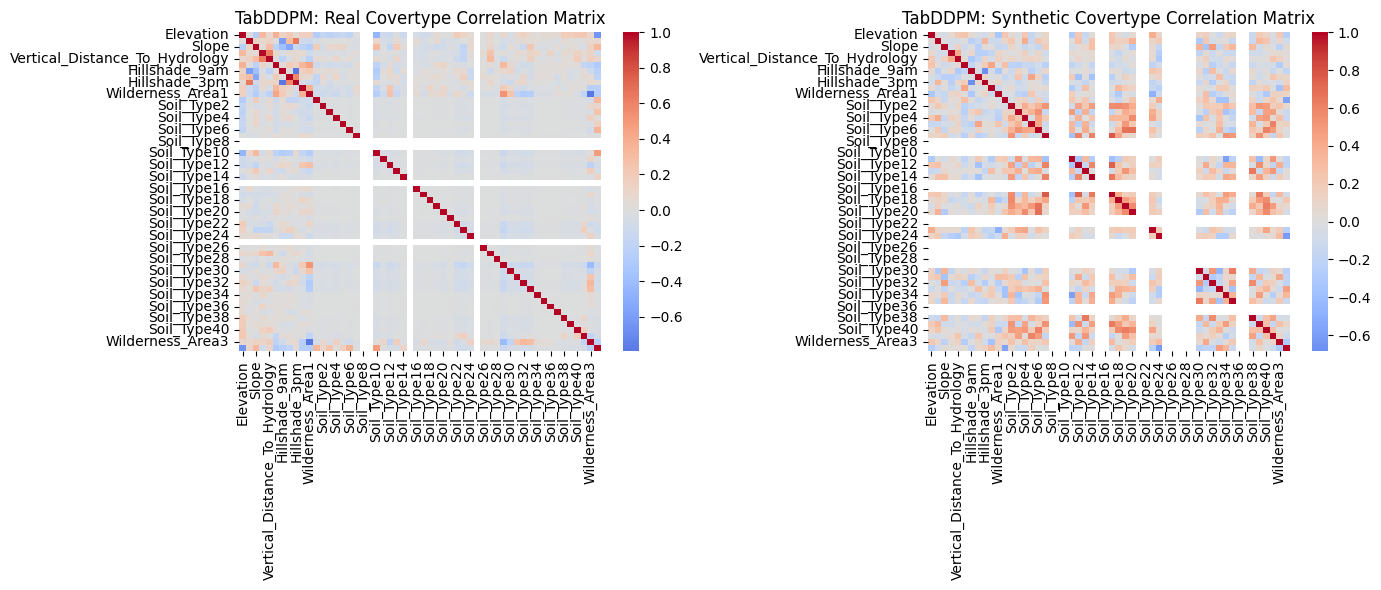

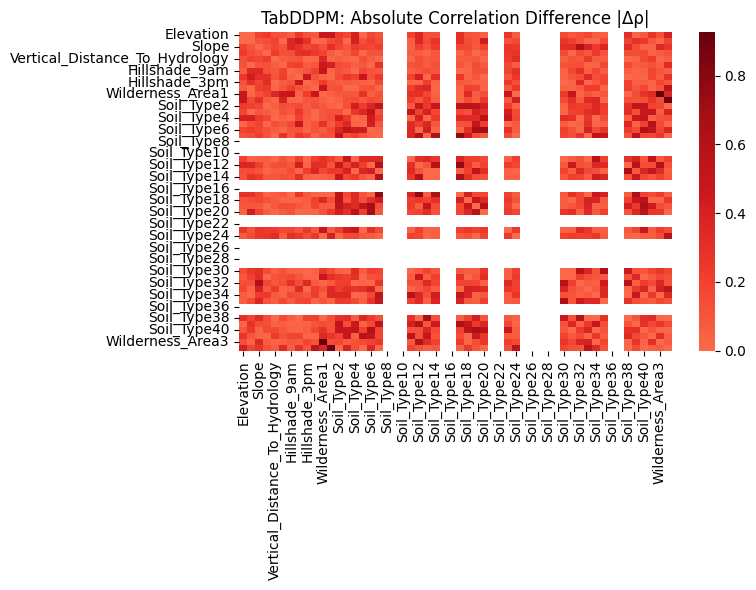

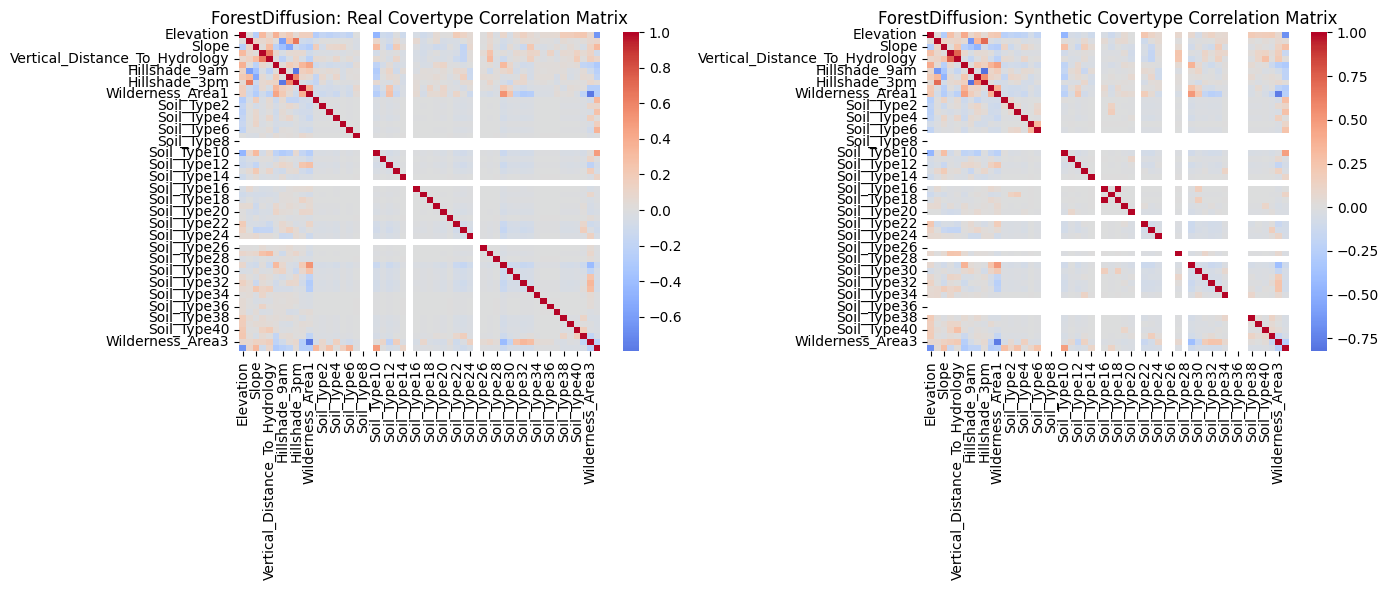

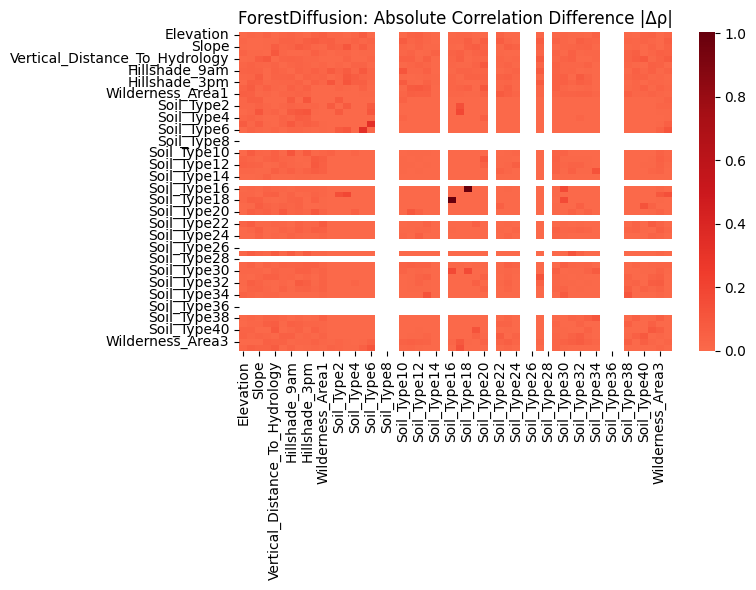

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

model_order = ["TabDDPM", "ForestDiffusion"]

real_df = real_sample.copy()
real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()

target_col = "Cover_Type"

if target_col not in real_df.columns:
    real_df = real_df.rename(columns={real_df.columns[-1]: target_col})

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

real_num = real_df[num_cols].apply(pd.to_numeric, errors="coerce")
real_num = real_num.fillna(real_num.median(numeric_only=True))
real_corr = real_num.corr()

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    if target_col not in synth_df.columns:
        synth_df = synth_df.rename(columns={synth_df.columns[-1]: target_col})

    common_num_cols = [
        c for c in num_cols
        if c in synth_df.columns
    ]

    if len(common_num_cols) < 2:
        print(f"{model_name}: Not enough numeric columns for correlation.")
        continue

    synth_num = synth_df[common_num_cols].apply(pd.to_numeric, errors="coerce")
    synth_num = synth_num.fillna(synth_num.median(numeric_only=True))
    synth_corr = synth_num.corr()

    real_corr_plot = real_corr.loc[common_num_cols, common_num_cols]
    synth_corr_plot = synth_corr.loc[common_num_cols, common_num_cols]

    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))

    sns.heatmap(real_corr_plot, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Covertype Correlation Matrix")

    sns.heatmap(synth_corr_plot, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Covertype Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr_plot - synth_corr_plot).abs()

    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



TabDDPM - Global MMD (RBF): 0.189755


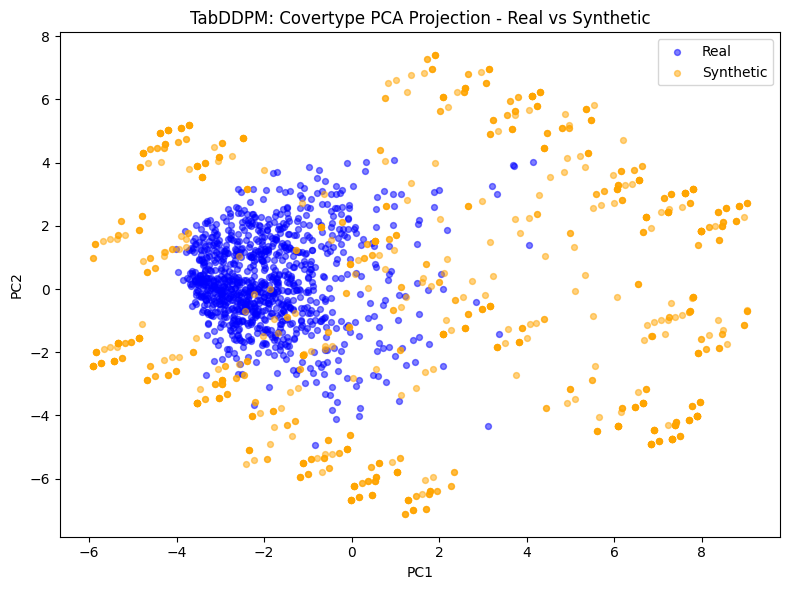

TabDDPM - Two-Sample Classifier Accuracy: 1.0000

ForestDiffusion - Global MMD (RBF): 0.002604


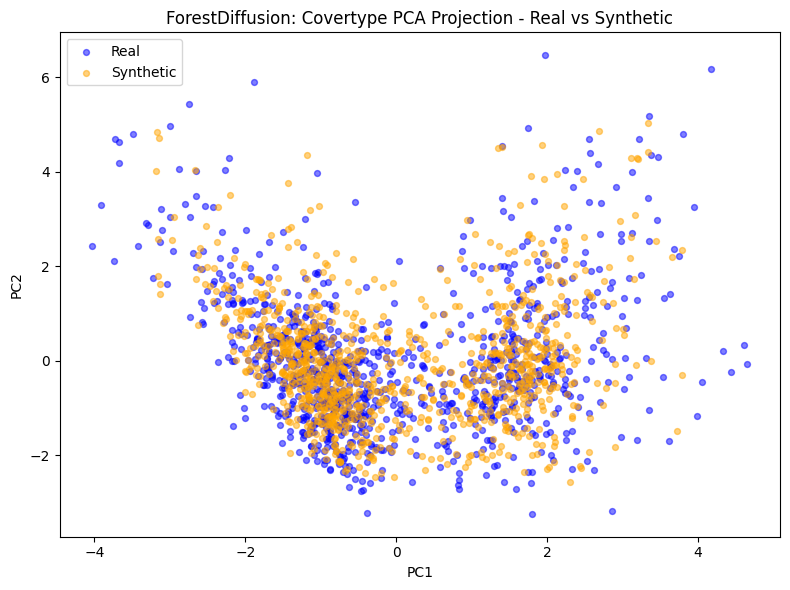

ForestDiffusion - Two-Sample Classifier Accuracy: 0.6667

Summary:
Lower MMD is better. C2ST accuracy closer to 0.50 means real and synthetic are harder to distinguish.


,Model,Features_Used,Global_MMD_RBF,C2ST_Accuracy
0,ForestDiffusion,10,0.002604,0.666667
1,TabDDPM,10,0.189755,1.000000


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "Cover_Type"

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        positive_dists = dists[dists > 0]
        med = np.median(positive_dists) if len(positive_dists) > 0 else 1.0
        gamma = 1.0 / (2 * (med ** 2)) if med > 0 else 1.0

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    n, m = len(X), len(Y)

    return (
        (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
        + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
        - 2 * Kxy.mean()
    )

real_df = real_sample.copy()
real_df = real_df.loc[:, ~real_df.columns.duplicated()].copy()

if target_col not in real_df.columns:
    real_df = real_df.rename(columns={real_df.columns[-1]: target_col})

X_real_df = real_df.drop(columns=[target_col], errors="ignore")
X_real_df = X_real_df.select_dtypes(include=[np.number])
X_real_df = X_real_df.apply(pd.to_numeric, errors="coerce")

results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.loc[:, ~synth_df.columns.duplicated()].copy()

    if target_col not in synth_df.columns:
        synth_df = synth_df.rename(columns={synth_df.columns[-1]: target_col})

    X_synth_df = synth_df.drop(columns=[target_col], errors="ignore")
    X_synth_df = X_synth_df.select_dtypes(include=[np.number])
    X_synth_df = X_synth_df.apply(pd.to_numeric, errors="coerce")

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)

    if len(common_cols) < 2:
        print(f"{model_name}: Not enough common numeric columns for MMD/PCA/C2ST.")
        continue

    X_real_num = X_real_df[common_cols].copy()
    X_synth_num = X_synth_df[common_cols].copy()

    real_medians = X_real_num.median(numeric_only=True)
    X_real_num = X_real_num.fillna(real_medians)
    X_synth_num = X_synth_num.fillna(real_medians)

    X_real = X_real_num.to_numpy(dtype=float)
    X_synth = X_synth_num.to_numpy(dtype=float)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_pca[labels == "Real", 0],
        X_pca[labels == "Real", 1],
        color="blue",
        alpha=0.5,
        label="Real",
        s=18
    )
    plt.scatter(
        X_pca[labels == "Synthetic", 0],
        X_pca[labels == "Synthetic", 1],
        color="orange",
        alpha=0.5,
        label="Synthetic",
        s=18
    )
    plt.title(f"{model_name}: Covertype PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))

    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st,
        y_c2st,
        test_size=0.3,
        stratify=y_c2st,
        random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Features_Used": len(common_cols),
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)

print("\nSummary:")
print("Lower MMD is better. C2ST accuracy closer to 0.50 means real and synthetic are harder to distinguish.")
display(results_df)


# 4 Utility with 10 classifiers

In [28]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(),
    "SVM-RBF": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "MLP": MLPClassifier(),
}

def clean_cover_type_labels(y):
    y = pd.Series(y).copy()
    y = pd.to_numeric(y, errors="coerce")
    y = y.round().astype("Int64")
    return y

def evaluate_models(train_df, test_df, label_col, models=models, test_size=0.2, seed=42, no_split=False):
    train_df = train_df.loc[:, ~train_df.columns.duplicated()].copy()
    test_df = test_df.loc[:, ~test_df.columns.duplicated()].copy()

    if label_col not in train_df.columns:
        train_df = train_df.rename(columns={train_df.columns[-1]: label_col})
    if label_col not in test_df.columns:
        test_df = test_df.rename(columns={test_df.columns[-1]: label_col})

    common_cols = train_df.columns.intersection(test_df.columns)
    train_df = train_df[common_cols].copy()
    test_df = test_df[common_cols].copy()

    num_cols = [
        c for c in common_cols
        if c != label_col
        and pd.api.types.is_numeric_dtype(train_df[c])
        and pd.api.types.is_numeric_dtype(test_df[c])
    ]

    X_train = train_df[num_cols].apply(pd.to_numeric, errors="coerce")
    X_test = test_df[num_cols].apply(pd.to_numeric, errors="coerce")

    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    y_train = pd.to_numeric(train_df[label_col], errors="coerce").round()
    y_test = pd.to_numeric(test_df[label_col], errors="coerce").round()

    train_valid = y_train.notna()
    test_valid = y_test.notna()

    X_train = X_train.loc[train_valid]
    y_train = y_train.loc[train_valid].astype(int)

    X_test = X_test.loc[test_valid]
    y_test = y_test.loc[test_valid].astype(int)

    common_classes = sorted(set(y_train.unique()).intersection(set(y_test.unique())))

    X_train = X_train.loc[y_train.isin(common_classes)]
    y_train = y_train.loc[y_train.isin(common_classes)]

    X_test = X_test.loc[y_test.isin(common_classes)]
    y_test = y_test.loc[y_test.isin(common_classes)]

    if len(common_classes) < 2:
        raise ValueError("Need at least 2 common Cover_Type classes for classification.")

    stratify_train = y_train if y_train.value_counts().min() >= 2 else None
    stratify_test = y_test if y_test.value_counts().min() >= 2 else None

    if not no_split:
        if len(X_train) > 1:
            X_train, _, y_train, _ = train_test_split(
                X_train, y_train, test_size=test_size, random_state=seed, stratify=stratify_train
            )
        if len(X_test) > 1:
            _, X_test, _, y_test = train_test_split(
                X_test, y_test, test_size=test_size, random_state=seed, stratify=stratify_test
            )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []

    for name, clf in models.items():
        try:
            clf.fit(X_train_s, y_train)
            y_pred = clf.predict(X_test_s)

            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
            f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

            auc = np.nan
            if hasattr(clf, "predict_proba"):
                y_prob = clf.predict_proba(X_test_s)
                if len(clf.classes_) >= 2 and set(y_test.unique()).issubset(set(clf.classes_)):
                    try:
                        auc = roc_auc_score(
                            y_test,
                            y_prob,
                            multi_class="ovr",
                            average="macro"
                        )
                    except Exception:
                        auc = np.nan

            rows.append({
                "Model": name,
                "Accuracy": acc,
                "F1_Macro": f1_macro,
                "F1_Weighted": f1_weighted,
                "AUC_OVR_Macro": auc
            })

        except Exception as e:
            print(f"Error with {name}: {str(e)[:120]}")
            rows.append({
                "Model": name,
                "Accuracy": np.nan,
                "F1_Macro": np.nan,
                "F1_Weighted": np.nan,
                "AUC_OVR_Macro": np.nan
            })

    return pd.DataFrame(rows).sort_values(by="F1_Weighted", ascending=False)


In [29]:
import pandas as pd
import numpy as np

label_col = "Cover_Type"
model_order = ["TabDDPM", "ForestDiffusion"]

# Prepare real eval data
real_eval = real_sample.copy()
real_eval = real_eval.loc[:, ~real_eval.columns.duplicated()].copy()

if label_col not in real_eval.columns:
    real_eval = real_eval.rename(columns={real_eval.columns[-1]: label_col})

# Ensure numeric dtypes in real_eval
for col in real_eval.columns:
    if real_eval[col].dtype == 'object':
        real_eval[col] = pd.to_numeric(real_eval[col], errors='coerce')
real_eval = real_eval.dropna()

# TRTR: Train Real, Test Real
trtr_results = evaluate_models(
    train_df=real_eval,
    test_df=real_eval,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    synth_eval = synthetic_outputs[synth_name].copy()
    synth_eval = synth_eval.loc[:, ~synth_eval.columns.duplicated()].copy()

    if label_col not in synth_eval.columns:
        synth_eval = synth_eval.rename(columns={synth_eval.columns[-1]: label_col})

    # Ensure numeric dtypes in synth_eval
    for col in synth_eval.columns:
        if synth_eval[col].dtype == 'object':
            synth_eval[col] = pd.to_numeric(synth_eval[col], errors='coerce')
    synth_eval = synth_eval.dropna()

    # Align columns to match real_eval
    shared_cols = [c for c in real_eval.columns if c in synth_eval.columns]
    synth_eval = synth_eval[shared_cols]
    real_eval_aligned = real_eval[shared_cols]

    # TSTR: Train Synthetic, Test Real
    tstr_results = evaluate_models(
        train_df=synth_eval,
        test_df=real_eval_aligned,
        label_col=label_col,
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    drop_metrics = {
        "AUC_OVR_Macro_Drop": ("AUC_OVR_Macro_TRTR", "AUC_OVR_Macro_TSTR"),
        "F1_Macro_Drop":      ("F1_Macro_TRTR",      "F1_Macro_TSTR"),
        "F1_Weighted_Drop":   ("F1_Weighted_TRTR",   "F1_Weighted_TSTR"),
        "Accuracy_Drop":      ("Accuracy_TRTR",      "Accuracy_TSTR"),
    }

    for drop_col, (trtr_col, tstr_col) in drop_metrics.items():
        if trtr_col in comparison.columns and tstr_col in comparison.columns:
            comparison[drop_col] = comparison[trtr_col] - comparison[tstr_col]

    comparison["Synthetic_Model"] = synth_name

    drop_priority = ["F1_Weighted_Drop", "Accuracy_Drop", "F1_Macro_Drop", "AUC_OVR_Macro_Drop"]
    sort_col = next((c for c in drop_priority if c in comparison.columns), None)

    if sort_col is not None:
        comparison = comparison.sort_values(sort_col, ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

if all_comparisons:
    combined_comparison = pd.concat(all_comparisons, ignore_index=True)

    metric_cols = [
        c for c in [
            "AUC_OVR_Macro_Drop",
            "F1_Macro_Drop",
            "F1_Weighted_Drop",
            "Accuracy_Drop"
        ]
        if c in combined_comparison.columns
    ]

    if metric_cols:
        summary = (
            combined_comparison
            .groupby("Synthetic_Model", as_index=False)[metric_cols]
            .mean()
            .sort_values(metric_cols[0])
        )
        print("Average performance drop by synthetic generator (lower is better):")
        display(summary)
    else:
        print("No drop metrics were available for summarization.")
else:
    print("No synthetic model comparisons were computed.")


TRTR (Train Real, Test Real)


/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
7,GradientBoost,0.780,0.597911,0.771990,NaN
5,RandomForest,0.770,0.514465,0.751167,NaN
9,MLP,0.755,0.493690,0.743660,NaN
0,LogReg,0.740,0.464726,0.725980,NaN
6,ExtraTrees,0.730,0.512573,0.718531,NaN
1,SVM-RBF,0.705,0.426397,0.687801,NaN
2,KNN,0.690,0.439719,0.677804,NaN
4,DecisionTree,0.660,0.469802,0.667549,NaN
8,AdaBoost,0.610,0.371315,0.563940,NaN
3,NaiveBayes,0.185,0.226705,0.174666,NaN


/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


TabDDPM - TSTR (Train Synthetic, Test Real)


...

,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
0,LogReg,0.745,0.457529,0.744371,NaN
5,RandomForest,0.750,0.475456,0.730707,NaN
7,GradientBoost,0.730,0.525800,0.729115,NaN
6,ExtraTrees,0.740,0.448333,0.719604,NaN
9,MLP,0.725,0.523855,0.718042,NaN
1,SVM-RBF,0.725,0.447730,0.706718,NaN
4,DecisionTree,0.630,0.413816,0.638668,NaN
2,KNN,0.645,0.392335,0.634809,NaN
8,AdaBoost,0.665,0.335928,0.626216,NaN
3,NaiveBayes,0.250,0.248258,0.206575,NaN


ForestDiffusion - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_Macro_TRTR,F1_Weighted_TRTR,AUC_OVR_Macro_TRTR,Accuracy_TSTR,F1_Macro_TSTR,F1_Weighted_TSTR,AUC_OVR_Macro_TSTR,AUC_OVR_Macro_Drop,F1_Macro_Drop,F1_Weighted_Drop,Accuracy_Drop,Synthetic_Model
6,KNN,0.690,0.439719,0.677804,NaN,0.645,0.392335,0.634809,NaN,NaN,0.047384,0.042996,0.045,ForestDiffusion
0,GradientBoost,0.780,0.597911,0.771990,NaN,0.730,0.525800,0.729115,NaN,NaN,0.072111,0.042876,0.050,ForestDiffusion
7,DecisionTree,0.660,0.469802,0.667549,NaN,0.630,0.413816,0.638668,NaN,NaN,0.055986,0.028881,0.030,ForestDiffusion
2,MLP,0.755,0.493690,0.743660,NaN,0.725,0.523855,0.718042,NaN,NaN,-0.030166,0.025618,0.030,ForestDiffusion
1,RandomForest,0.770,0.514465,0.751167,NaN,0.750,0.475456,0.730707,NaN,NaN,0.039009,0.020460,0.020,ForestDiffusion
4,ExtraTrees,0.730,0.512573,0.718531,NaN,0.740,0.448333,0.719604,NaN,NaN,0.064240,-0.001073,-0.010,ForestDiffusion
3,LogReg,0.740,0.464726,0.725980,NaN,0.745,0.457529,0.744371,NaN,NaN,0.007197,-0.018391,-0.005,ForestDiffusion
5,SVM-RBF,0.705,0.426397,0.687801,NaN,0.725,0.447730,0.706718,NaN,NaN,-0.021333,-0.018917,-0.020,ForestDiffusion
9,NaiveBayes,0.185,0.226705,0.174666,NaN,0.250,0.248258,0.206575,NaN,NaN,-0.021553,-0.031909,-0.065,ForestDiffusion
8,AdaBoost,0.610,0.371315,0.563940,NaN,0.665,0.335928,0.626216,NaN,NaN,0.035388,-0.062275,-0.055,ForestDiffusion


Average performance drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_OVR_Macro_Drop,F1_Macro_Drop,F1_Weighted_Drop,Accuracy_Drop
0,ForestDiffusion,NaN,0.024826,0.002826,0.0020
1,TabDDPM,NaN,0.302803,0.284732,0.2125


TRTR (Train Real, Test Real)


/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
5,RandomForest,0.765,0.568868,0.751826,NaN
7,GradientBoost,0.745,0.562275,0.736804,NaN
0,LogReg,0.740,0.464726,0.725980,NaN
9,MLP,0.720,0.471317,0.710951,NaN
6,ExtraTrees,0.720,0.482937,0.703481,NaN
1,SVM-RBF,0.705,0.426397,0.687801,NaN
2,KNN,0.690,0.439719,0.677804,NaN
4,DecisionTree,0.650,0.416868,0.657432,NaN
8,AdaBoost,0.610,0.371315,0.563940,NaN
3,NaiveBayes,0.185,0.226705,0.174666,NaN



TabDDPM - TSTR (Train Synthetic, Test Real)


/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
2,KNN,0.500,0.181159,0.455109,NaN
7,GradientBoost,0.450,0.159153,0.409042,NaN
5,RandomForest,0.420,0.201599,0.407710,NaN
1,SVM-RBF,0.390,0.141304,0.353261,NaN
9,MLP,0.405,0.142554,0.349224,NaN
6,ExtraTrees,0.365,0.130868,0.325292,NaN
4,DecisionTree,0.310,0.123625,0.319343,NaN
0,LogReg,0.485,0.109234,0.317872,NaN
3,NaiveBayes,0.465,0.106529,0.310000,NaN
8,AdaBoost,0.395,0.126254,0.299255,NaN


Skipping AUC_OVR_Macro: no valid values.


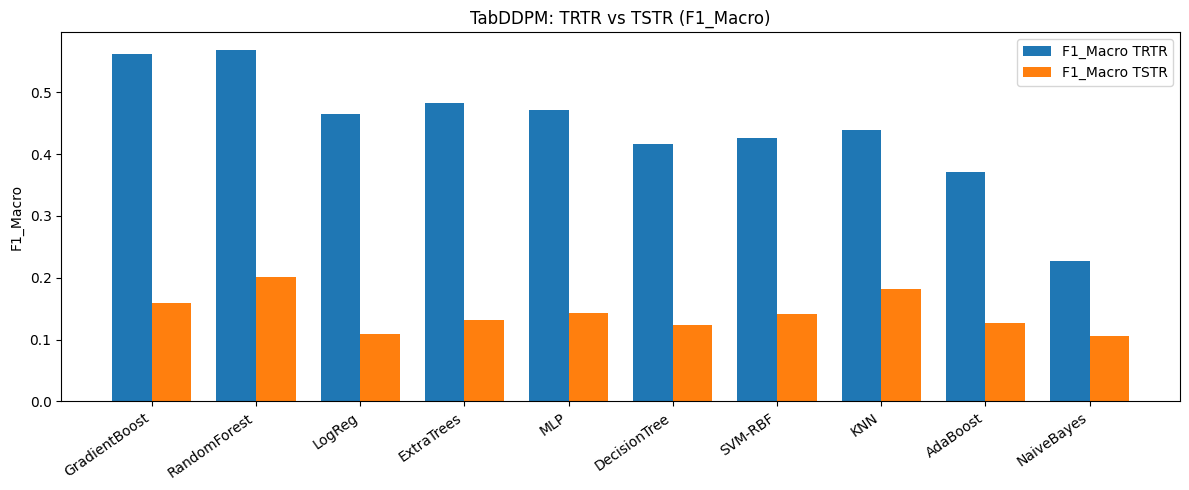

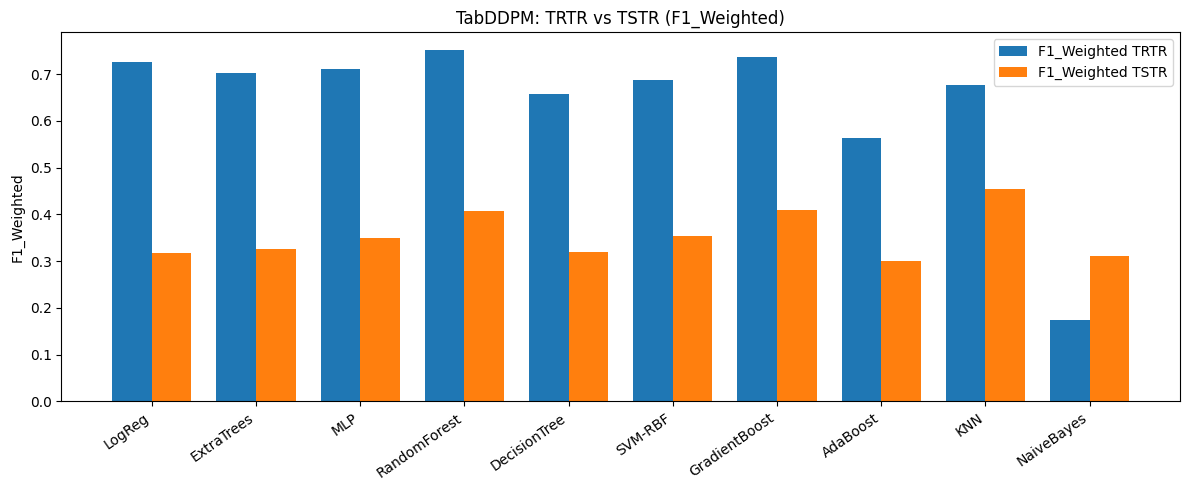

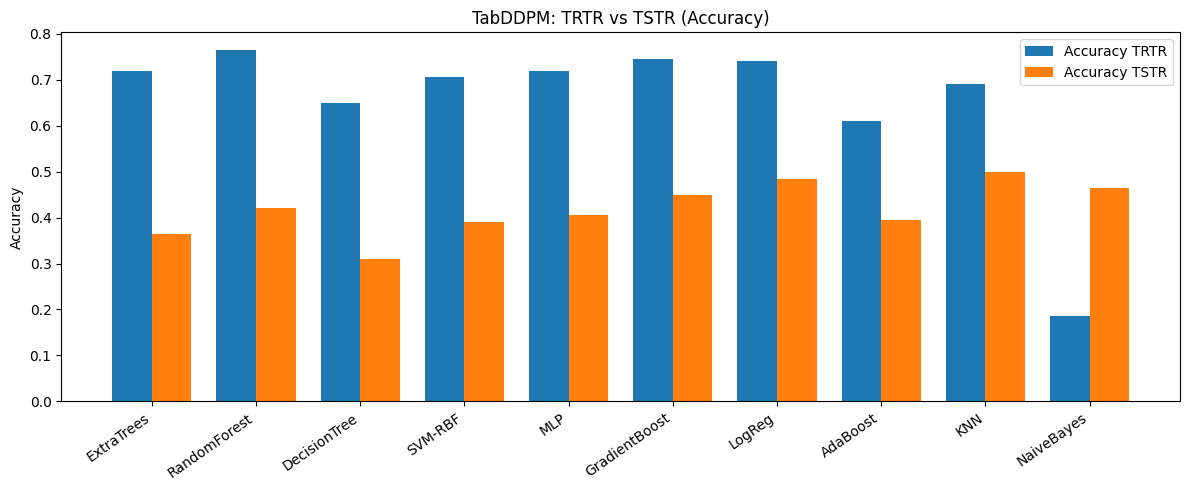

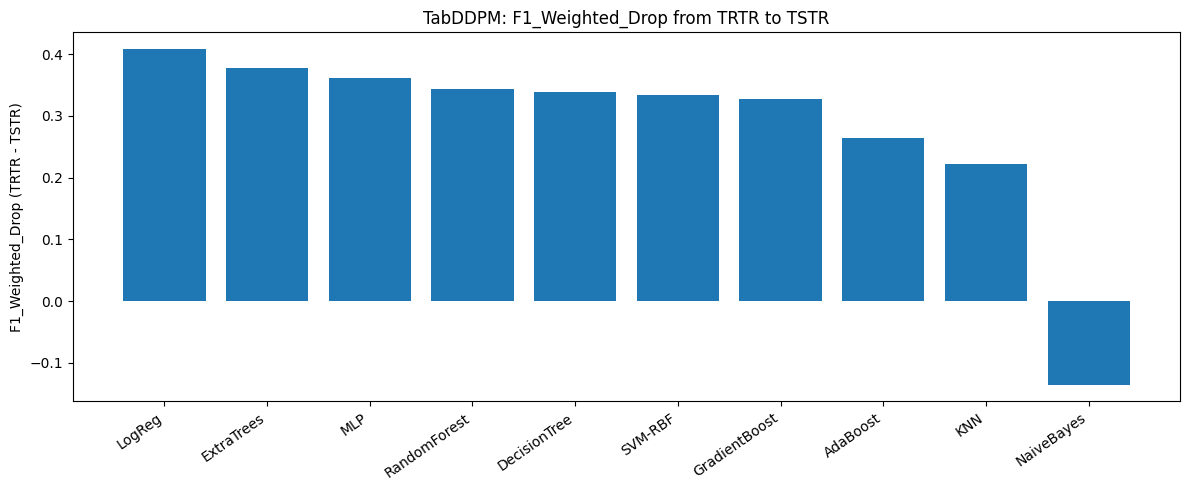

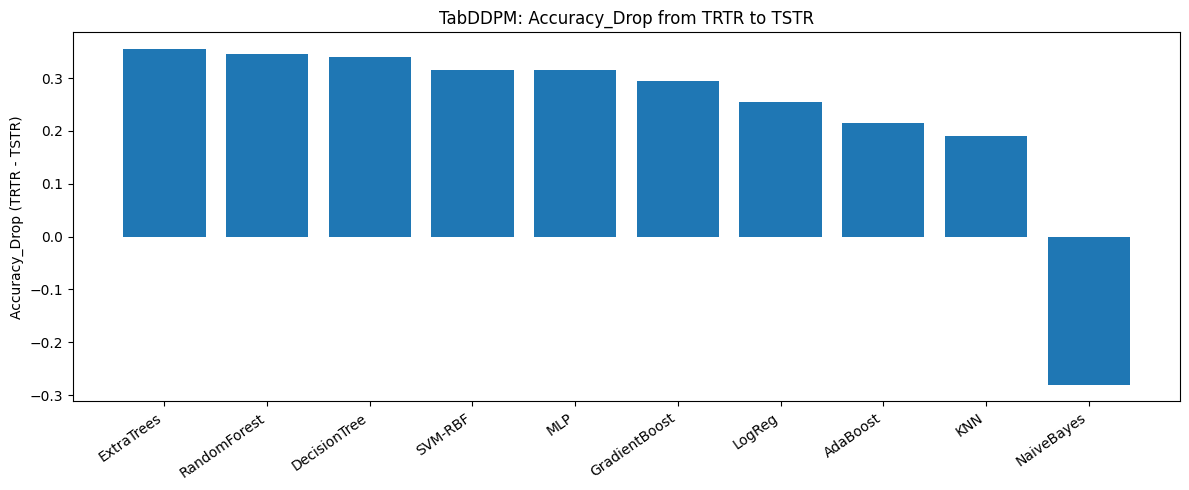


TabDDPM - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_Macro_TRTR,F1_Weighted_TRTR,AUC_OVR_Macro_TRTR,Accuracy_TSTR,F1_Macro_TSTR,F1_Weighted_TSTR,AUC_OVR_Macro_TSTR,AUC_OVR_Macro_Drop,F1_Macro_Drop,F1_Weighted_Drop,Accuracy_Drop,Synthetic_Model
0,RandomForest,0.765,0.568868,0.751826,NaN,0.420,0.201599,0.407710,NaN,NaN,0.367268,0.344116,0.345,TabDDPM
1,GradientBoost,0.745,0.562275,0.736804,NaN,0.450,0.159153,0.409042,NaN,NaN,0.403121,0.327762,0.295,TabDDPM
2,LogReg,0.740,0.464726,0.725980,NaN,0.485,0.109234,0.317872,NaN,NaN,0.355492,0.408108,0.255,TabDDPM
3,MLP,0.720,0.471317,0.710951,NaN,0.405,0.142554,0.349224,NaN,NaN,0.328764,0.361727,0.315,TabDDPM
4,ExtraTrees,0.720,0.482937,0.703481,NaN,0.365,0.130868,0.325292,NaN,NaN,0.352068,0.378188,0.355,TabDDPM
5,SVM-RBF,0.705,0.426397,0.687801,NaN,0.390,0.141304,0.353261,NaN,NaN,0.285093,0.334540,0.315,TabDDPM
6,KNN,0.690,0.439719,0.677804,NaN,0.500,0.181159,0.455109,NaN,NaN,0.258560,0.222696,0.190,TabDDPM
7,DecisionTree,0.650,0.416868,0.657432,NaN,0.310,0.123625,0.319343,NaN,NaN,0.293243,0.338089,0.340,TabDDPM
8,AdaBoost,0.610,0.371315,0.563940,NaN,0.395,0.126254,0.299255,NaN,NaN,0.245061,0.264685,0.215,TabDDPM
9,NaiveBayes,0.185,0.226705,0.174666,NaN,0.465,0.106529,0.310000,NaN,NaN,0.120176,-0.135334,-0.280,TabDDPM



ForestDiffusion - TSTR (Train Synthetic, Test Real)


/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,F1_Macro,F1_Weighted,AUC_OVR_Macro
0,LogReg,0.760,0.473770,0.745296,NaN
5,RandomForest,0.730,0.456143,0.713430,NaN
9,MLP,0.720,0.487140,0.708181,NaN
6,ExtraTrees,0.730,0.428391,0.706124,NaN
7,GradientBoost,0.710,0.525593,0.705131,NaN
1,SVM-RBF,0.705,0.413818,0.679537,NaN
2,KNN,0.680,0.415504,0.658520,NaN
3,NaiveBayes,0.635,0.448050,0.640845,NaN
8,AdaBoost,0.665,0.335928,0.626216,NaN
4,DecisionTree,0.620,0.525849,0.621112,NaN


Skipping AUC_OVR_Macro: no valid values.


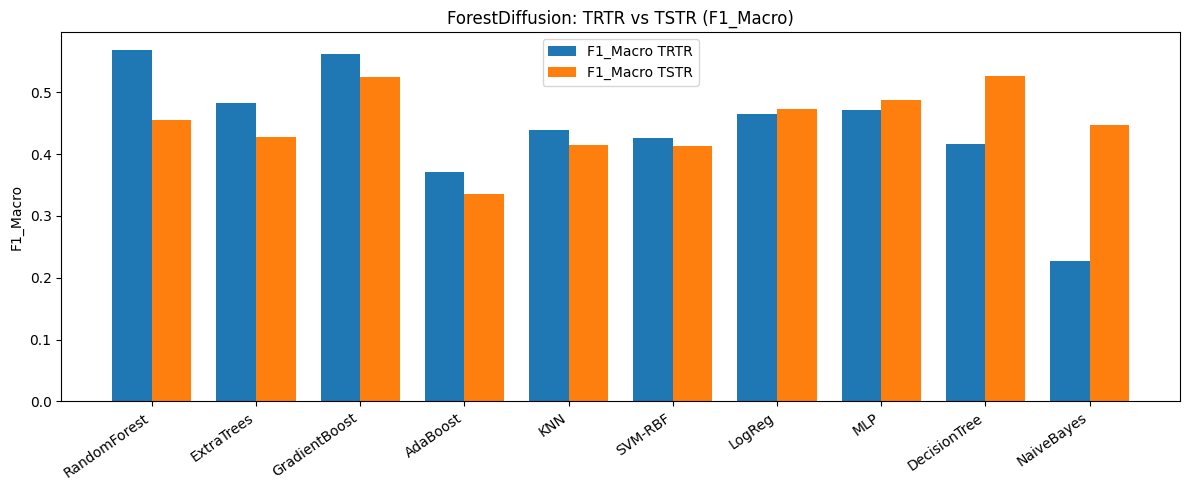

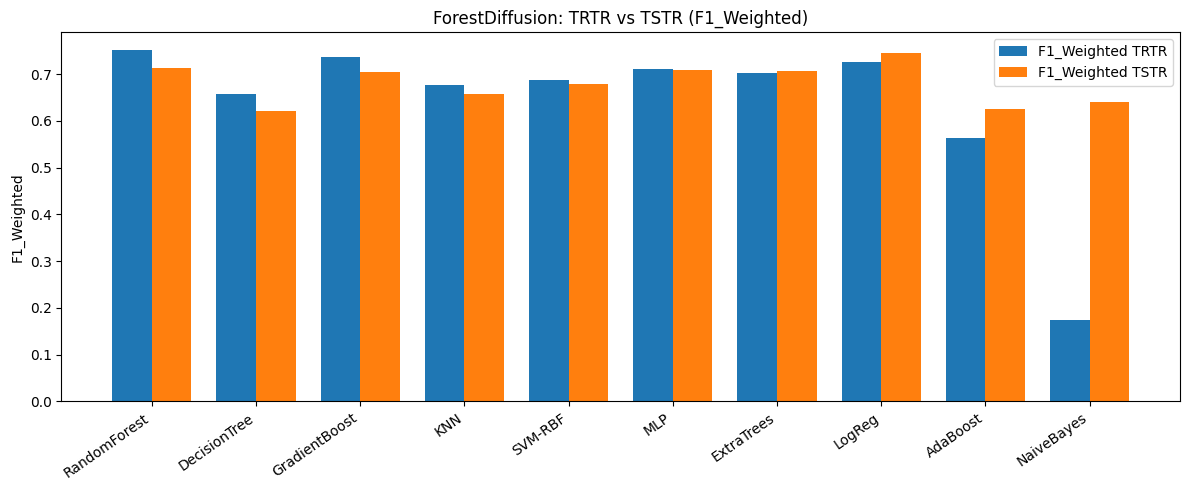

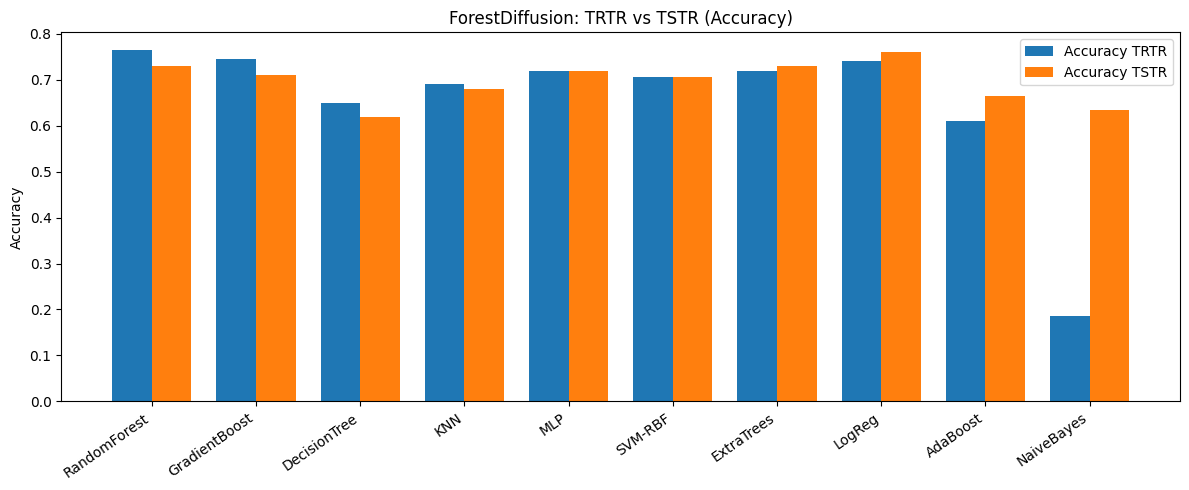

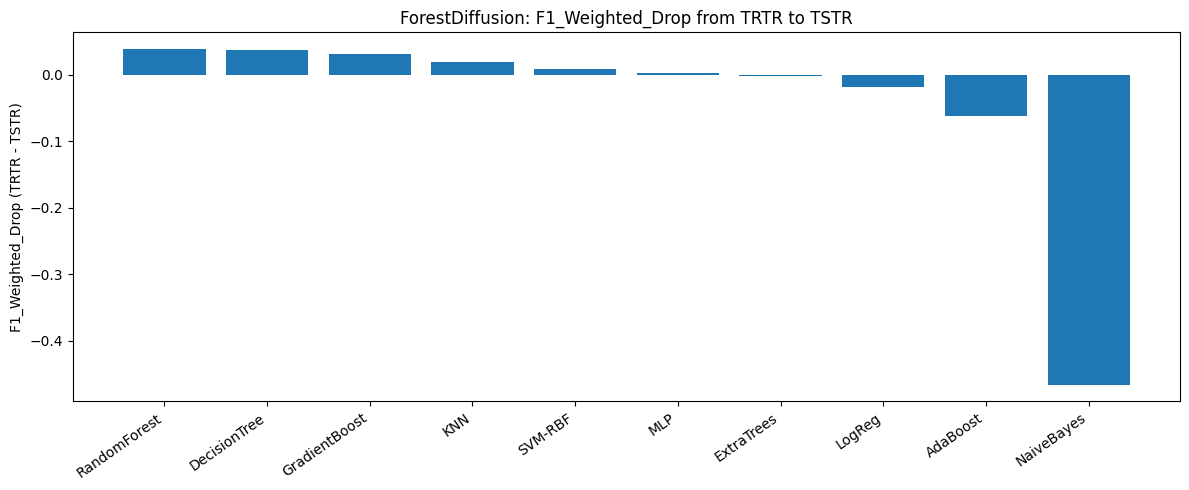

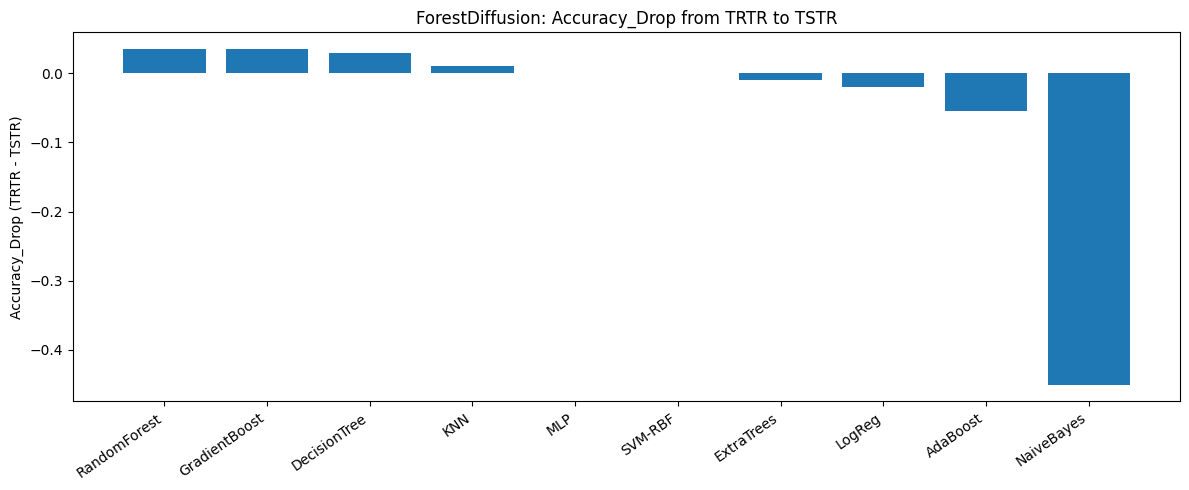


ForestDiffusion - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_Macro_TRTR,F1_Weighted_TRTR,AUC_OVR_Macro_TRTR,Accuracy_TSTR,F1_Macro_TSTR,F1_Weighted_TSTR,AUC_OVR_Macro_TSTR,AUC_OVR_Macro_Drop,F1_Macro_Drop,F1_Weighted_Drop,Accuracy_Drop,Synthetic_Model
0,RandomForest,0.765,0.568868,0.751826,NaN,0.730,0.456143,0.713430,NaN,NaN,0.112724,0.038396,0.035,ForestDiffusion
1,GradientBoost,0.745,0.562275,0.736804,NaN,0.710,0.525593,0.705131,NaN,NaN,0.036682,0.031673,0.035,ForestDiffusion
2,LogReg,0.740,0.464726,0.725980,NaN,0.760,0.473770,0.745296,NaN,NaN,-0.009044,-0.019316,-0.020,ForestDiffusion
3,MLP,0.720,0.471317,0.710951,NaN,0.720,0.487140,0.708181,NaN,NaN,-0.015823,0.002770,0.000,ForestDiffusion
4,ExtraTrees,0.720,0.482937,0.703481,NaN,0.730,0.428391,0.706124,NaN,NaN,0.054546,-0.002644,-0.010,ForestDiffusion
5,SVM-RBF,0.705,0.426397,0.687801,NaN,0.705,0.413818,0.679537,NaN,NaN,0.012579,0.008264,0.000,ForestDiffusion
6,KNN,0.690,0.439719,0.677804,NaN,0.680,0.415504,0.658520,NaN,NaN,0.024216,0.019284,0.010,ForestDiffusion
7,DecisionTree,0.650,0.416868,0.657432,NaN,0.620,0.525849,0.621112,NaN,NaN,-0.108980,0.036321,0.030,ForestDiffusion
8,AdaBoost,0.610,0.371315,0.563940,NaN,0.665,0.335928,0.626216,NaN,NaN,0.035388,-0.062275,-0.055,ForestDiffusion
9,NaiveBayes,0.185,0.226705,0.174666,NaN,0.635,0.448050,0.640845,NaN,NaN,-0.221345,-0.466178,-0.450,ForestDiffusion



Average performance drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_OVR_Macro_Drop,F1_Macro_Drop,F1_Weighted_Drop,Accuracy_Drop
0,ForestDiffusion,NaN,-0.007906,-0.041371,-0.0425
1,TabDDPM,NaN,0.300885,0.284458,0.2345


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        print(f"Skipping {metric}: not found.")
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    df = df.dropna(subset=[f"{metric}_TRTR", f"{metric}_TSTR"])

    if df.empty:
        print(f"Skipping {metric}: no valid values.")
        return

    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_drop(comparison_df, synth_name, drop_col):
    if drop_col not in comparison_df.columns:
        print(f"Skipping {drop_col}: not found.")
        return

    df = comparison_df.dropna(subset=[drop_col]).sort_values(drop_col, ascending=False)

    if df.empty:
        print(f"Skipping {drop_col}: no valid values.")
        return

    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[drop_col])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(f"{drop_col} (TRTR - TSTR)")
    plt.title(f"{synth_name}: {drop_col} from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "Cover_Type"
model_order = ["TabDDPM", "ForestDiffusion"]

data_eval = real_sample.copy()
data_eval = data_eval.loc[:, ~data_eval.columns.duplicated()].copy()

if label_col not in data_eval.columns:
    data_eval = data_eval.rename(columns={data_eval.columns[-1]: label_col})

synthetic_eval = {}

for name in model_order:
    df = synthetic_outputs[name].copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    if label_col not in df.columns:
        df = df.rename(columns={df.columns[-1]: label_col})

    synthetic_eval[name] = df

trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_eval[synth_name],
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    metric_cols = ["AUC_OVR_Macro", "F1_Macro", "F1_Weighted", "Accuracy"]

    for metric in metric_cols:
        trtr_col = f"{metric}_TRTR"
        tstr_col = f"{metric}_TSTR"

        if trtr_col in comparison.columns and tstr_col in comparison.columns:
            comparison[f"{metric}_Drop"] = comparison[trtr_col] - comparison[tstr_col]

    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    for metric in metric_cols:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_metric_drop(comparison, synth_name, "F1_Weighted_Drop")
    plot_metric_drop(comparison, synth_name, "Accuracy_Drop")

    print(f"\n{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

if all_comp:
    combined_comparison = pd.concat(all_comp, ignore_index=True)

    drop_cols = [
        c for c in [
            "AUC_OVR_Macro_Drop",
            "F1_Macro_Drop",
            "F1_Weighted_Drop",
            "Accuracy_Drop"
        ]
        if c in combined_comparison.columns
    ]

    if drop_cols:
        sort_col = "F1_Weighted_Drop" if "F1_Weighted_Drop" in drop_cols else drop_cols[0]
        summary = (
            combined_comparison
            .groupby("Synthetic_Model", as_index=False)[drop_cols]
            .mean()
            .sort_values(sort_col)
        )

        print("\nAverage performance drop by synthetic generator (lower is better):")
        display(summary)
    else:
        print("No drop metrics available.")
else:
    print("No comparisons computed.")


/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


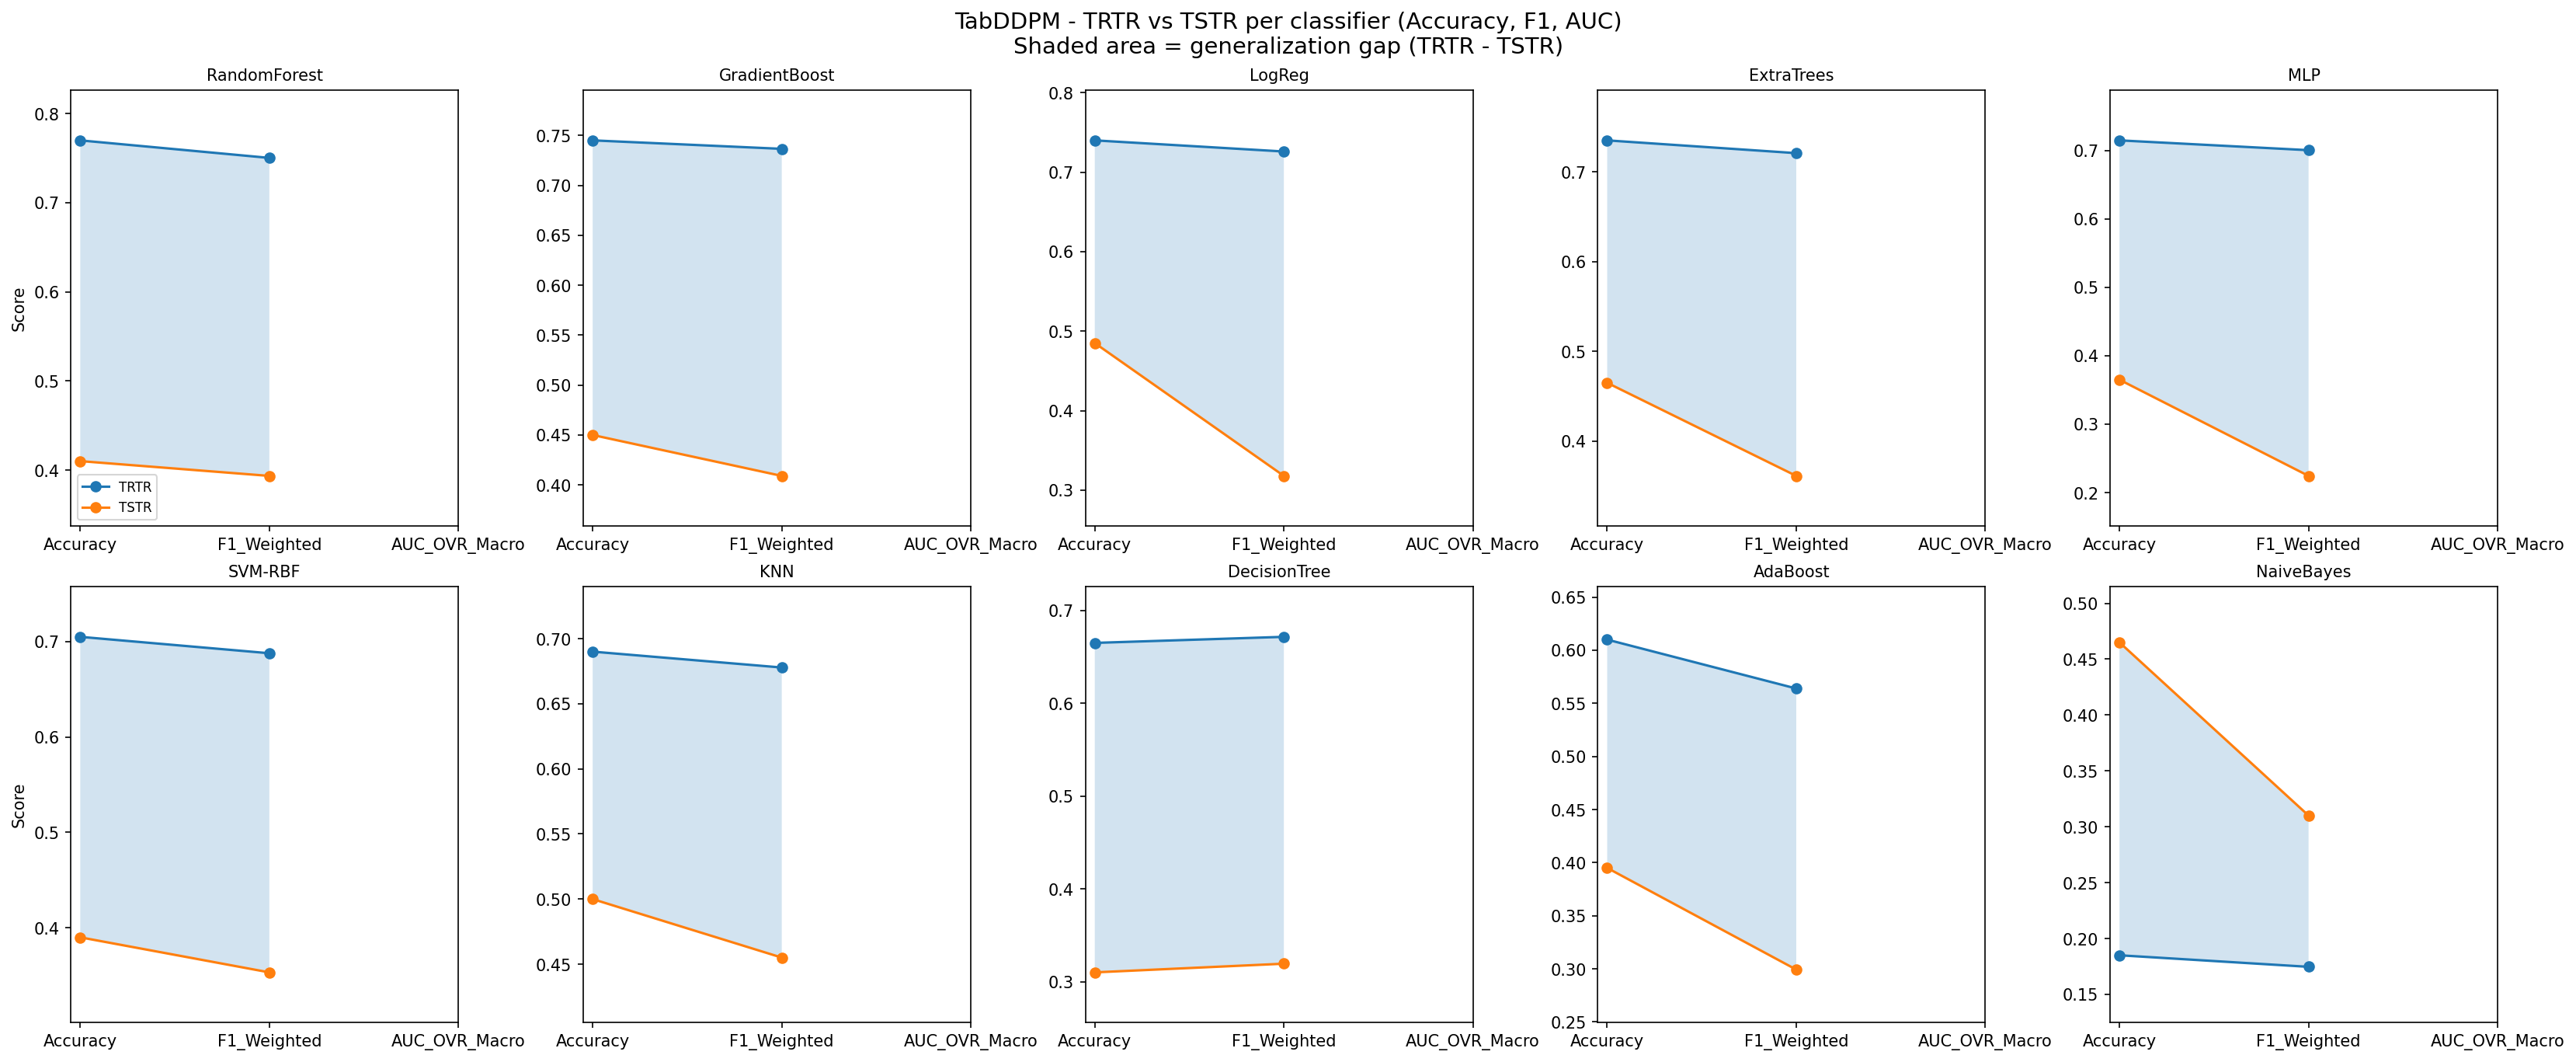

/home/gopi.battineni/.conda/envs/gopi/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


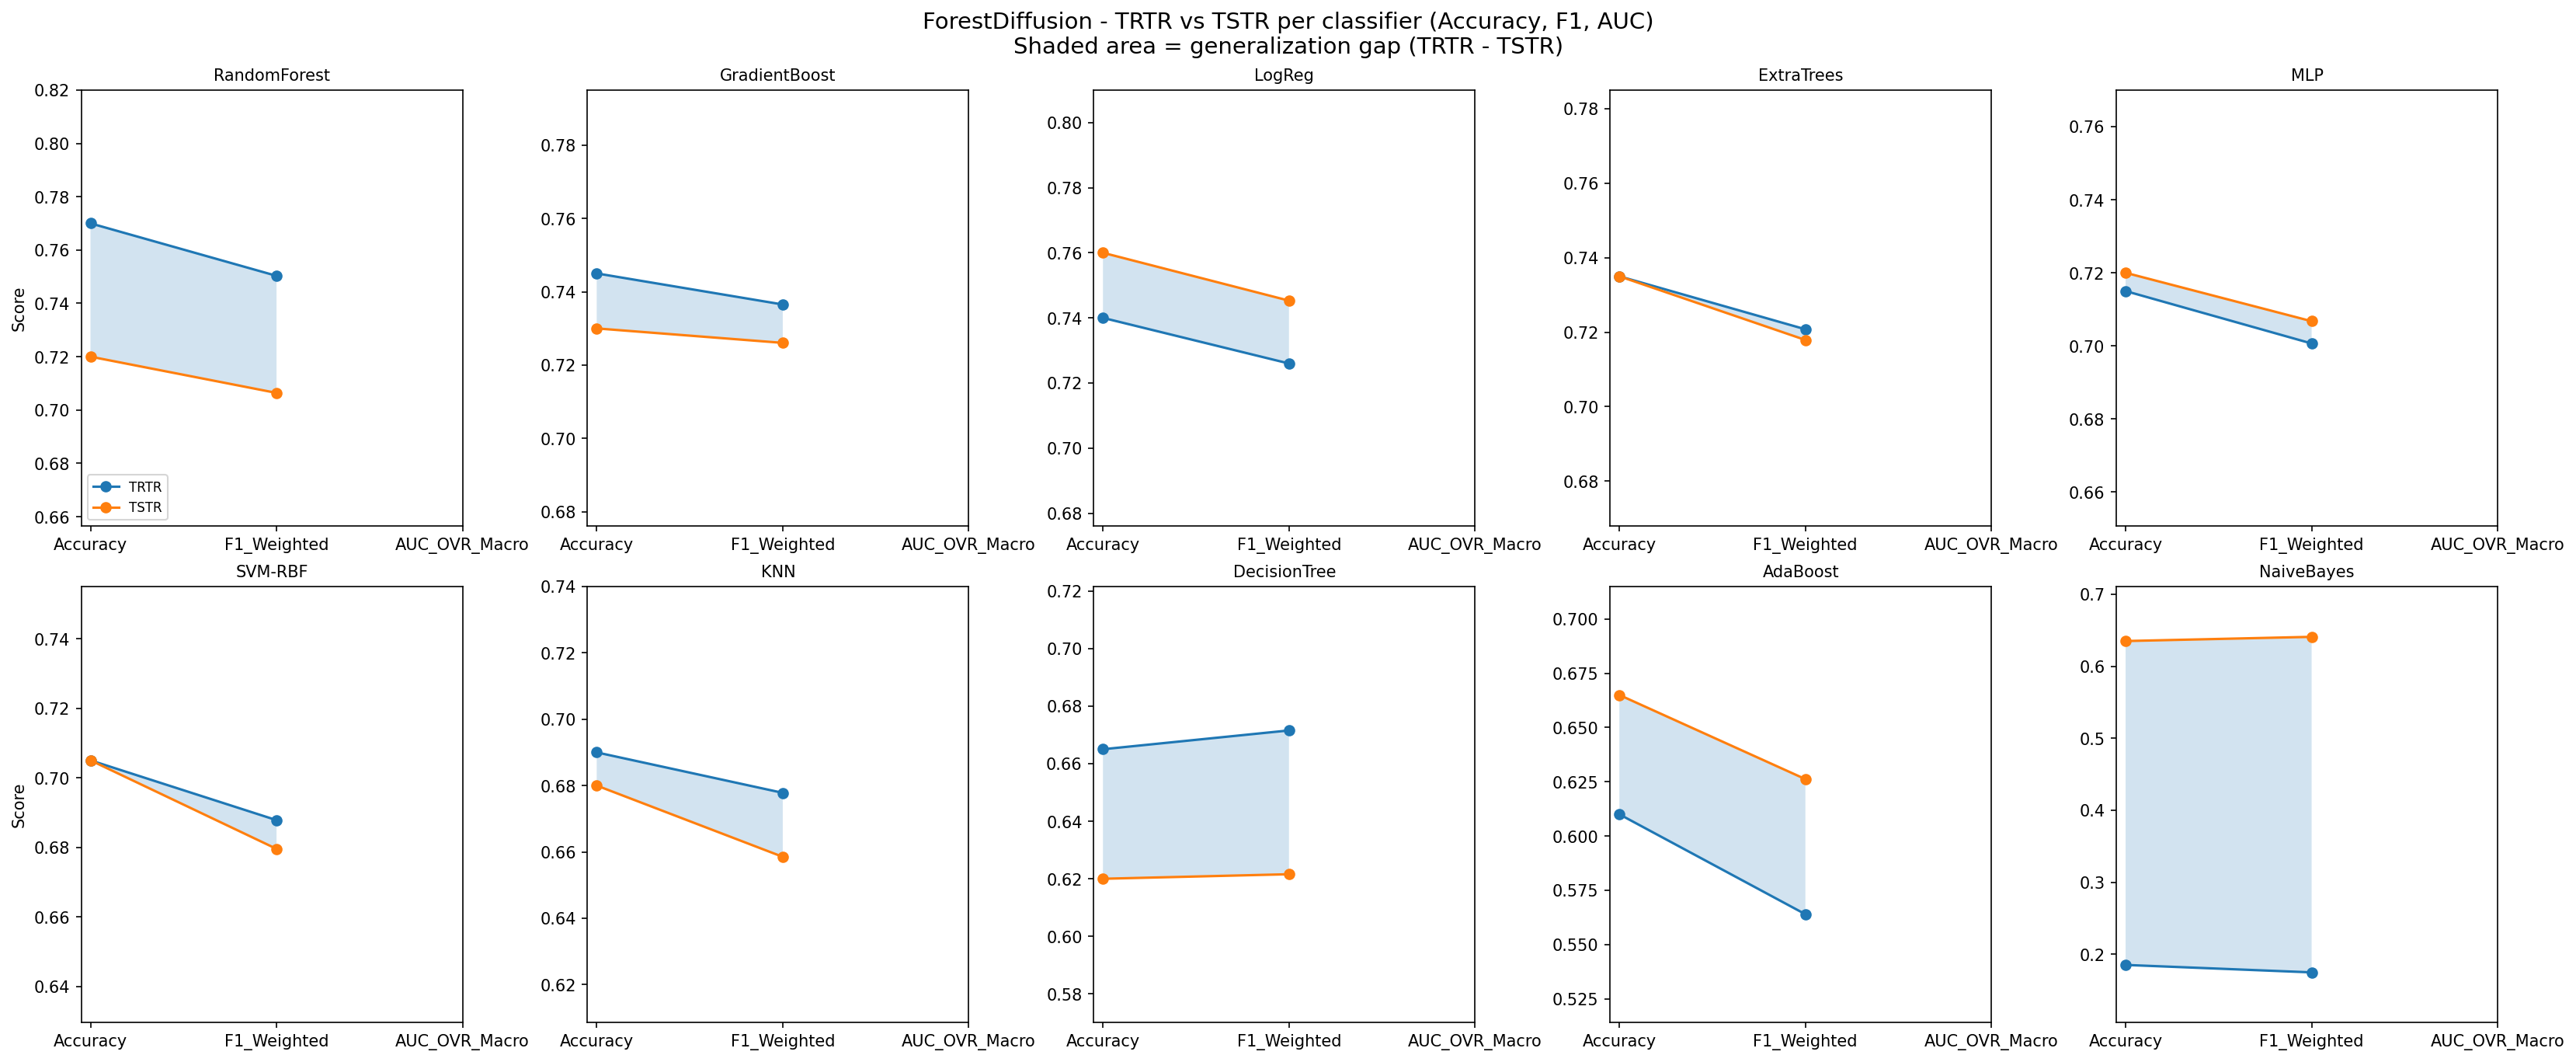

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1_Weighted", "AUC_OVR_Macro"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

# Fixed for Covertype dataset + clean labels
label_col = "Cover_Type"
generators = ["TabDDPM", "ForestDiffusion"]

# Clean and prepare real data (using clean_cover_type_labels from previous cell)
data_eval = real_sample.copy()
data_eval[label_col] = clean_cover_type_labels(data_eval[label_col])

# TRTR baseline
trtr_results = evaluate_models(
    train_df=data_eval,
    test_df=data_eval,
    label_col=label_col,
    models=models
)

for gen in generators:
    synth_eval = synthetic_outputs[gen].copy()
    if label_col in synth_eval.columns:
        synth_eval[label_col] = clean_cover_type_labels(synth_eval[label_col])

    tstr_results = evaluate_models(
        train_df=synth_eval,
        test_df=data_eval,
        label_col=label_col,
        models=models
    )

    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# Increasing accuracy of some classifers

Highly correlated features with Cover_Type
Threshold: |correlation| >= 0.1


Wilderness_Area4                      0.323804
Soil_Type10                           0.277650
Soil_Type2                            0.162093
Soil_Type38                           0.152037
Soil_Type40                           0.150283
Slope                                 0.146487
Vertical_Distance_To_Hydrology        0.141842
Soil_Type1                            0.130124
Soil_Type34                           0.124574
Soil_Type4                            0.116699
Soil_Type35                           0.110549
Soil_Type36                           0.110549
Soil_Type37                           0.110549
Soil_Type6                            0.100947
Soil_Type23                          -0.136655
Soil_Type29                          -0.145591
Horizontal_Distance_To_Fire_Points   -0.149603
Soil_Type22                          -0.170512
Horizontal_Distance_To_Roadways      -0.194107
Wilderness_Area1                     -0.238058
Elevation                            -0.310188
Name: Cover_T


Number of selected features: 21

Selected feature names:
['Wilderness_Area4', 'Soil_Type10', 'Soil_Type2', 'Soil_Type38', 'Soil_Type40', 'Slope', 'Vertical_Distance_To_Hydrology', 'Soil_Type1', 'Soil_Type34', 'Soil_Type4', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type6', 'Soil_Type23', 'Soil_Type29', 'Horizontal_Distance_To_Fire_Points', 'Soil_Type22', 'Horizontal_Distance_To_Roadways', 'Wilderness_Area1', 'Elevation', 'Cover_Type']

Filtered datasets created successfully.


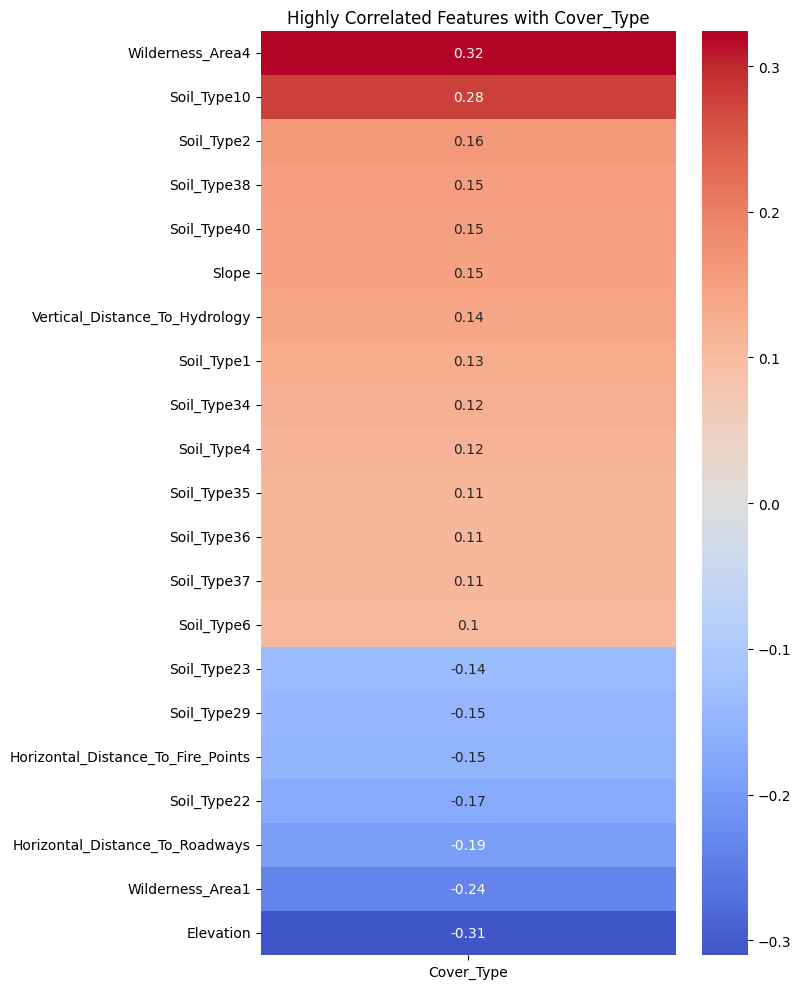

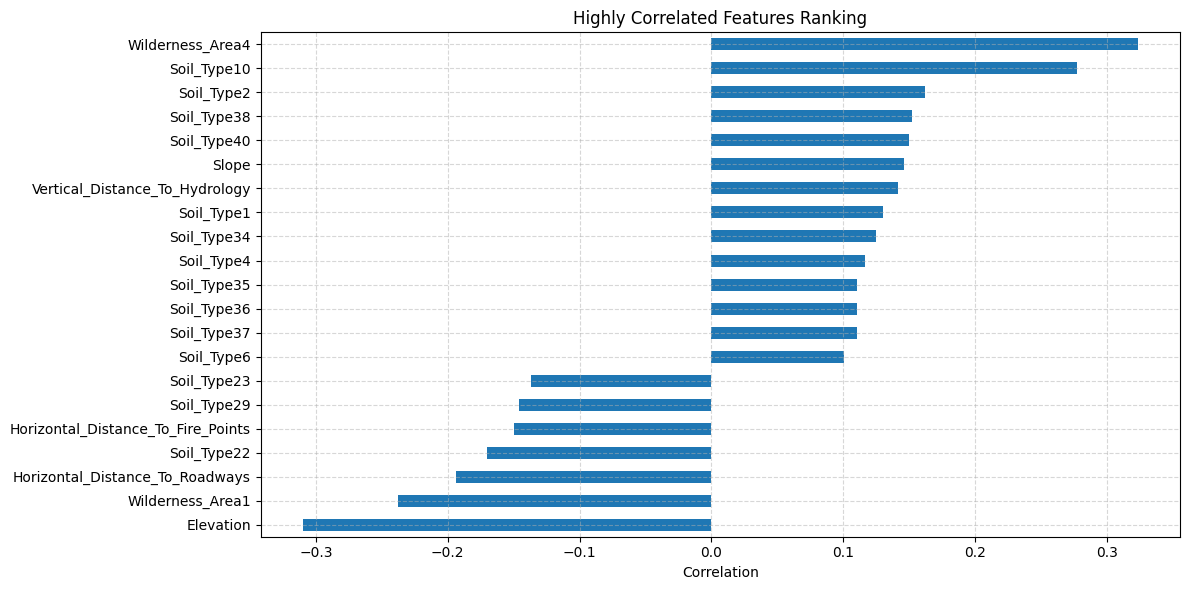

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "Cover_Type"

corr_data = real_sample.copy()

for col in corr_data.columns:
    corr_data[col] = pd.to_numeric(
        corr_data[col],
        errors="coerce"
    )

corr_data = corr_data.dropna()

target_corr = (
    corr_data.corr()[target_col]
    .sort_values(ascending=False)
)

target_corr_no_target = target_corr.drop(target_col)

threshold = 0.10

high_corr_features = target_corr_no_target[
    abs(target_corr_no_target) >= threshold
]

print("=" * 60)
print("Highly correlated features with Cover_Type")
print(f"Threshold: |correlation| >= {threshold}")
print("=" * 60)

display(high_corr_features)

print("\nNumber of selected features:",
      len(high_corr_features))

selected_features = (
    high_corr_features.index.tolist()
)

selected_features.append(target_col)

print("\nSelected feature names:")
print(selected_features)

real_sample_highcorr = real_sample[
    selected_features
].copy()

synthetic_outputs_highcorr = {}

for name, df in synthetic_outputs.items():

    common_cols = [
        c for c in selected_features
        if c in df.columns
    ]

    synthetic_outputs_highcorr[name] = (
        df[common_cols].copy()
    )

print("\nFiltered datasets created successfully.")

plt.figure(figsize=(8, 10))

sns.heatmap(
    high_corr_features.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Highly Correlated Features with Cover_Type"
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

high_corr_features.sort_values().plot(
    kind="barh"
)

plt.title(
    "Highly Correlated Features Ranking"
)

plt.xlabel("Correlation")

plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

Selected Features
Wilderness_Area4
Soil_Type10
Soil_Type2
Soil_Type38
Soil_Type40
Soil_Type22
Horizontal_Distance_To_Roadways
Wilderness_Area1
Elevation
Cover_Type

Number of selected features: 9

Removed Features:
Aspect
Slope
Horizontal_Distance_To_Hydrology
Vertical_Distance_To_Hydrology
Hillshade_9am
Hillshade_Noon
Hillshade_3pm
Horizontal_Distance_To_Fire_Points
Soil_Type1
Soil_Type3
Soil_Type4
Soil_Type5
Soil_Type6
Soil_Type7
Soil_Type8
Soil_Type9
Soil_Type11
Soil_Type12
Soil_Type13
Soil_Type14
Soil_Type15
Soil_Type16
Soil_Type17
Soil_Type18
Soil_Type19
Soil_Type20
Soil_Type21
Soil_Type23
Soil_Type24
Soil_Type25
Soil_Type26
Soil_Type27
Soil_Type28
Soil_Type29
Soil_Type30
Soil_Type31
Soil_Type32
Soil_Type33
Soil_Type34
Soil_Type35
Soil_Type36
Soil_Type37
Soil_Type39
Wilderness_Area2
Wilderness_Area3

Number of removed features: 45

Filtered datasets created successfully.

Dataset Shapes
Real: (1000, 10)
TabDDPM: (1000, 10)
ForestDiffusion: (1000, 10)


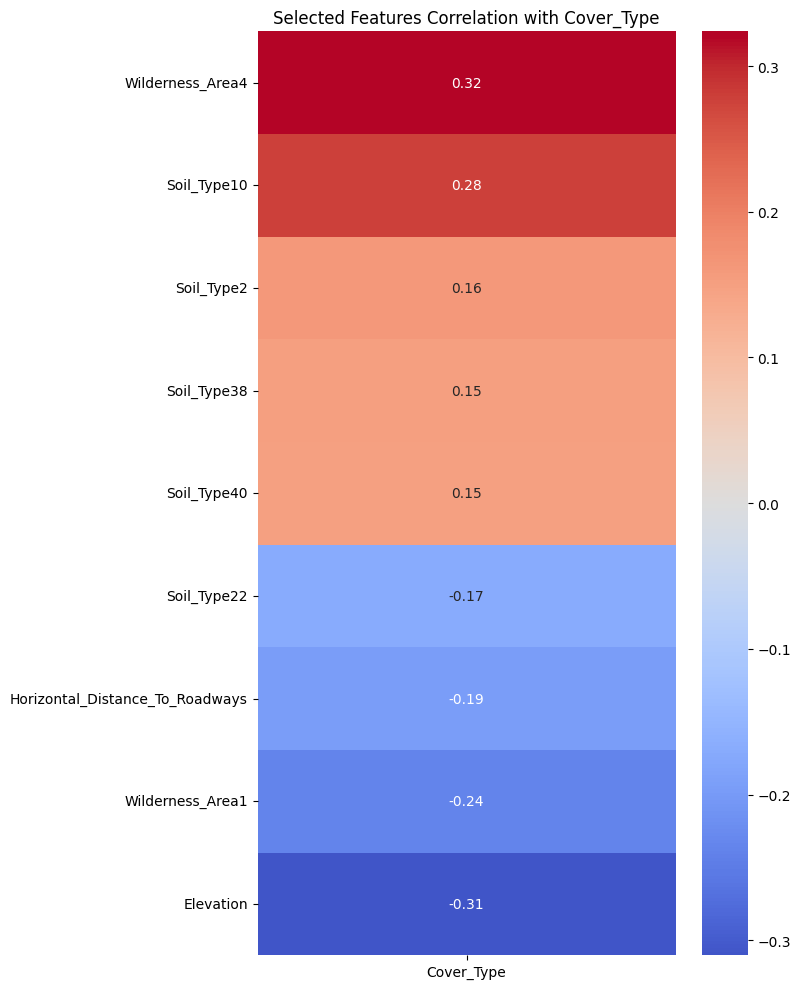

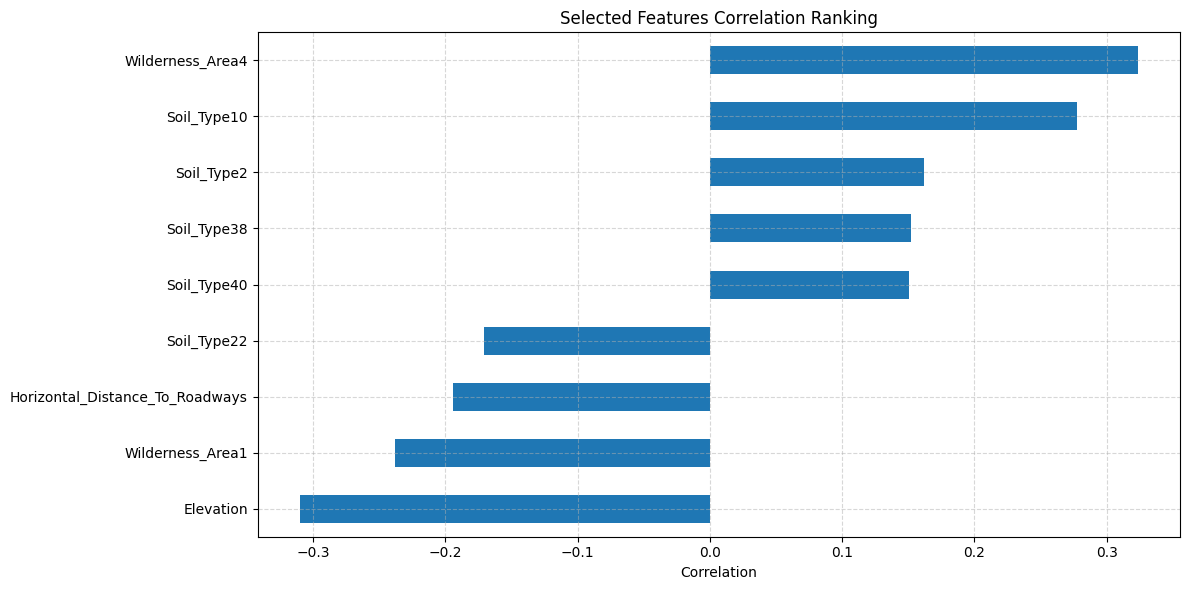

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

threshold = 0.15

target_col = "Cover_Type"

corr_data = real_sample.copy()

for col in corr_data.columns:
    corr_data[col] = pd.to_numeric(
        corr_data[col],
        errors="coerce"
    )

corr_data = corr_data.dropna()

target_corr = (
    corr_data.corr()[target_col]
    .sort_values(ascending=False)
)

target_corr = target_corr.drop(target_col)

selected_features = target_corr[
    abs(target_corr) >= threshold
].index.tolist()

selected_features.append(target_col)

print("=" * 60)
print("Selected Features")
print("=" * 60)

for feature in selected_features:
    print(feature)

print("\nNumber of selected features:",
      len(selected_features) - 1)

removed_features = [
    c for c in real_sample.columns
    if c not in selected_features
]

print("\nRemoved Features:")
print("=" * 60)

for feature in removed_features:
    print(feature)

print("\nNumber of removed features:",
      len(removed_features))

real_sample_filtered = real_sample[
    selected_features
].copy()

synthetic_outputs_filtered = {}

for name, df in synthetic_outputs.items():

    common_cols = [
        c for c in selected_features
        if c in df.columns
    ]

    synthetic_outputs_filtered[name] = (
        df[common_cols].copy()
    )

print("\nFiltered datasets created successfully.")

print("\nDataset Shapes")
print("=" * 60)

print(
    "Real:",
    real_sample_filtered.shape
)

for name, df in synthetic_outputs_filtered.items():

    print(
        f"{name}:",
        df.shape
    )

plt.figure(figsize=(8, 10))

sns.heatmap(
    target_corr[selected_features[:-1]].to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Selected Features Correlation with Cover_Type"
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

target_corr[selected_features[:-1]].sort_values().plot(
    kind="barh"
)

plt.title(
    "Selected Features Correlation Ranking"
)

plt.xlabel("Correlation")

plt.grid(
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

models = {

    "LogReg": LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ),

    "SVM-RBF": SVC(
        class_weight="balanced",
        probability=False
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "NaiveBayes": GaussianNB(),

    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoost": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=1000,
        random_state=42
    ),
}

def clean_cover_type_labels(y):

    y = pd.Series(y).copy()

    y = pd.to_numeric(
        y,
        errors="coerce"
    )

    y = y.round().astype("Int64")

    return y

def evaluate_models(
    train_df,
    test_df,
    label_col,
    models=models,
    test_size=0.2,
    seed=42,
    no_split=False
):

    train_df = (
        train_df
        .loc[:, ~train_df.columns.duplicated()]
        .copy()
    )

    test_df = (
        test_df
        .loc[:, ~test_df.columns.duplicated()]
        .copy()
    )

    if label_col not in train_df.columns:

        train_df = train_df.rename(
            columns={
                train_df.columns[-1]: label_col
            }
        )

    if label_col not in test_df.columns:

        test_df = test_df.rename(
            columns={
                test_df.columns[-1]: label_col
            }
        )

    common_cols = (
        train_df.columns
        .intersection(test_df.columns)
    )

    train_df = train_df[common_cols].copy()

    test_df = test_df[common_cols].copy()

    num_cols = [

        c for c in common_cols

        if c != label_col
    ]

    X_train = train_df[num_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    X_test = test_df[num_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    train_medians = X_train.median(
        numeric_only=True
    )

    X_train = X_train.fillna(
        train_medians
    )

    X_test = X_test.fillna(
        train_medians
    )

    y_train = pd.to_numeric(
        train_df[label_col],
        errors="coerce"
    ).round()

    y_test = pd.to_numeric(
        test_df[label_col],
        errors="coerce"
    ).round()

    train_valid = y_train.notna()

    test_valid = y_test.notna()

    X_train = X_train.loc[train_valid]

    y_train = y_train.loc[
        train_valid
    ].astype(int)

    X_test = X_test.loc[test_valid]

    y_test = y_test.loc[
        test_valid
    ].astype(int)

    common_classes = sorted(

        set(y_train.unique()).intersection(
            set(y_test.unique())
        )
    )

    X_train = X_train.loc[
        y_train.isin(common_classes)
    ]

    y_train = y_train.loc[
        y_train.isin(common_classes)
    ]

    X_test = X_test.loc[
        y_test.isin(common_classes)
    ]

    y_test = y_test.loc[
        y_test.isin(common_classes)
    ]

    if len(common_classes) < 2:

        raise ValueError(
            "Need at least 2 common classes."
        )

    print("\nTraining Class Distribution:")

    print(
        y_train.value_counts()
        .sort_index()
    )

    print("\nTraining Class Percentages:")

    print(
        (
            y_train.value_counts(
                normalize=True
            ) * 100
        )
        .sort_index()
        .round(2)
    )

    plt.figure(figsize=(8, 5))

    y_train.value_counts().sort_index().plot(
        kind="bar"
    )

    plt.title(
        "Training Class Distribution"
    )

    plt.xlabel("Class")

    plt.ylabel("Count")

    plt.grid(
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

    stratify_train = (

        y_train

        if y_train.value_counts().min() >= 2

        else None
    )

    stratify_test = (

        y_test

        if y_test.value_counts().min() >= 2

        else None
    )

    if not no_split:

        if len(X_train) > 1:

            X_train, _, y_train, _ = train_test_split(

                X_train,
                y_train,

                test_size=test_size,

                random_state=seed,

                stratify=stratify_train
            )

        if len(X_test) > 1:

            _, X_test, _, y_test = train_test_split(

                X_test,
                y_test,

                test_size=test_size,

                random_state=seed,

                stratify=stratify_test
            )

    scaler = StandardScaler()

    X_train_s = scaler.fit_transform(
        X_train
    )

    X_test_s = scaler.transform(
        X_test
    )

    rows = []

    for name, clf in models.items():

        try:

            clf.fit(
                X_train_s,
                y_train
            )

            y_pred = clf.predict(
                X_test_s
            )

            acc = accuracy_score(
                y_test,
                y_pred
            )

            precision_macro = precision_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            )

            recall_macro = recall_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            )

            precision_weighted = precision_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            recall_weighted = recall_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )

            rows.append({

                "Model": name,

                "Accuracy": acc,

                "Precision_Macro":
                    precision_macro,

                "Recall_Macro":
                    recall_macro,

                "Precision_Weighted":
                    precision_weighted,

                "Recall_Weighted":
                    recall_weighted
            })

        except Exception as e:

            print(
                f"Error with {name}: "
                f"{str(e)[:120]}"
            )

            rows.append({

                "Model": name,

                "Accuracy": np.nan,

                "Precision_Macro": np.nan,

                "Recall_Macro": np.nan,

                "Precision_Weighted": np.nan,

                "Recall_Weighted": np.nan
            })

    results = (

        pd.DataFrame(rows)

        .sort_values(
            by="Recall_Macro",
            ascending=False
        )
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=results,
        x="Recall_Macro",
        y="Model"
    )

    plt.title(
        "Model Recall Macro Comparison"
    )

    plt.xlabel("Recall Macro")

    plt.ylabel("Model")

    plt.tight_layout()
    plt.show()

    return results



Training Class Distribution:
Cover_Type
1    353
2    483
3     74
4      2
5     21
6     35
7     32
Name: count, dtype: int64

Training Class Percentages:
Cover_Type
1    35.3
2    48.3
3     7.4
4     0.2
5     2.1
6     3.5
7     3.2
Name: proportion, dtype: float64


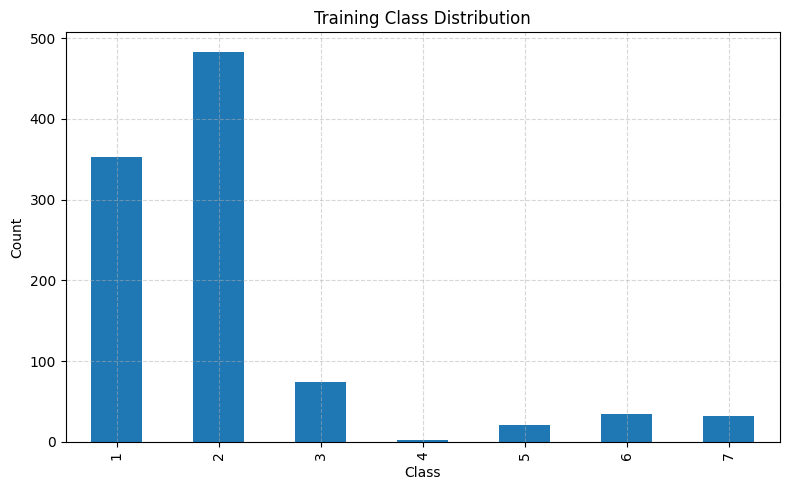

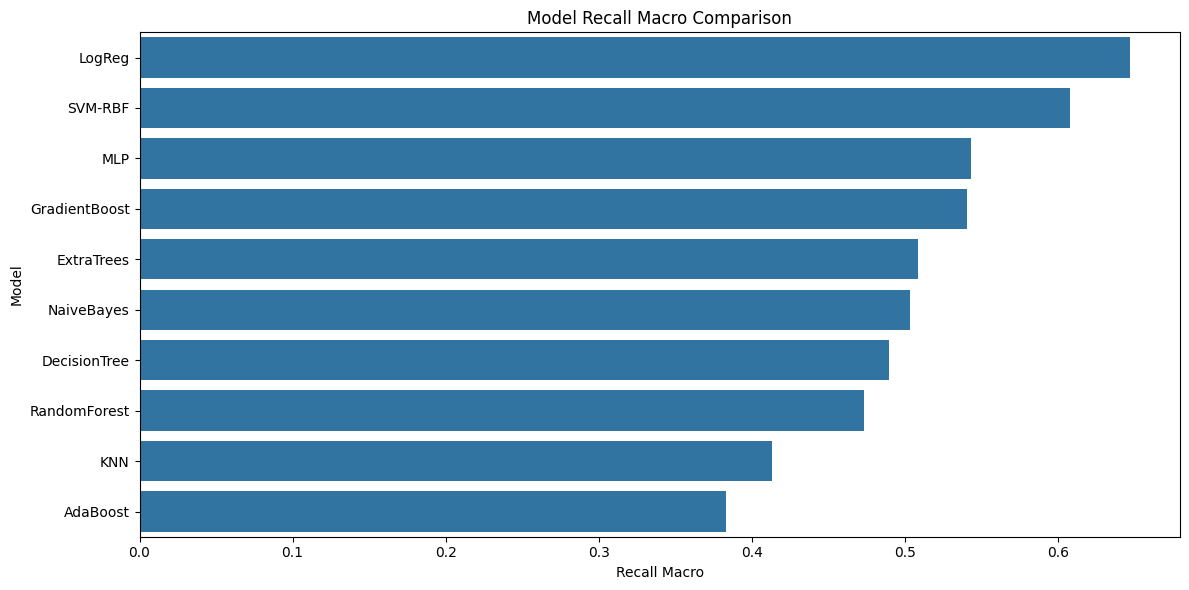


TRTR (Train Real, Test Real)


,Model,Accuracy,Precision_Macro,Recall_Macro,Precision_Weighted,Recall_Weighted
0,LogReg,0.645,0.527779,0.647350,0.733762,0.645
1,SVM-RBF,0.595,0.466460,0.607538,0.695333,0.595
9,MLP,0.750,0.607018,0.543350,0.743683,0.750
7,GradientBoost,0.745,0.590621,0.540475,0.731214,0.745
6,ExtraTrees,0.735,0.603885,0.508462,0.722590,0.735
3,NaiveBayes,0.185,0.384983,0.503330,0.689983,0.185
4,DecisionTree,0.700,0.485039,0.489752,0.704627,0.700
5,RandomForest,0.745,0.635124,0.473141,0.736211,0.745
2,KNN,0.690,0.569266,0.413330,0.687231,0.690
8,AdaBoost,0.610,0.404655,0.383038,0.609878,0.610



Processing: TabDDPM

Training Class Distribution:
Cover_Type
1    362
2    479
3     58
4      1
5     24
6     37
7     39
Name: count, dtype: int64

Training Class Percentages:
Cover_Type
1    36.2
2    47.9
3     5.8
4     0.1
5     2.4
6     3.7
7     3.9
Name: proportion, dtype: float64


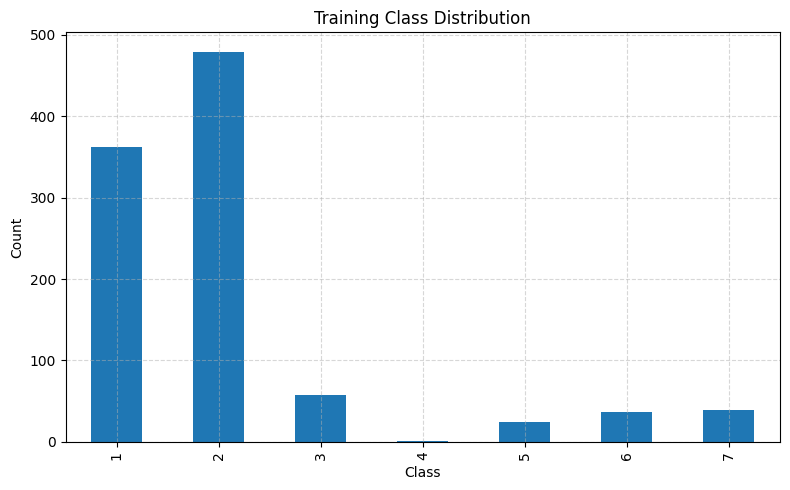

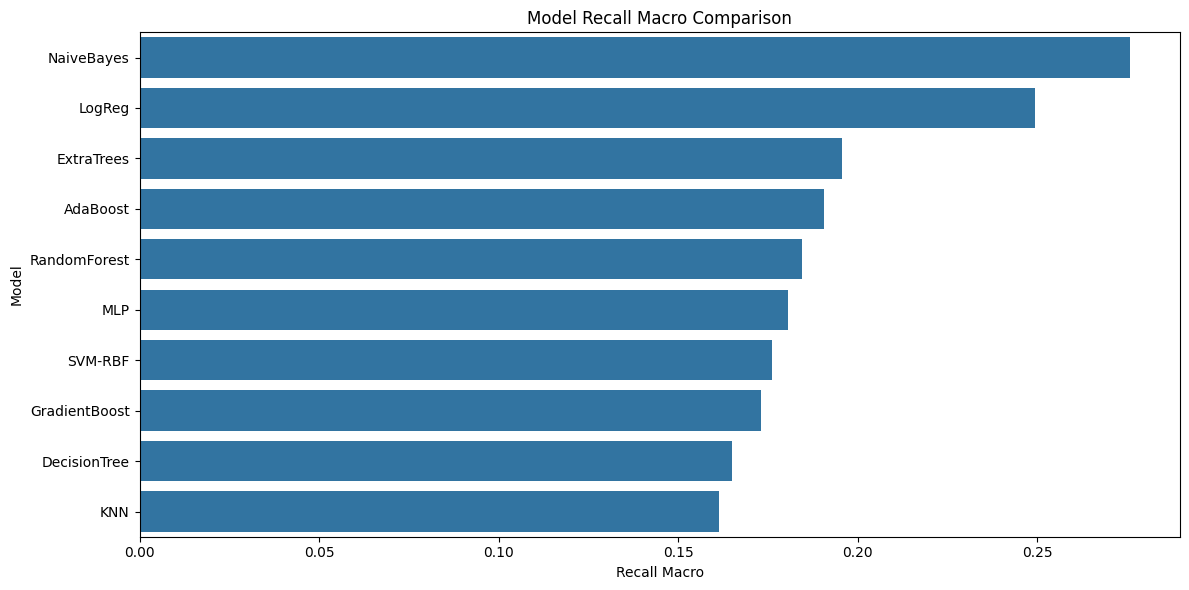


TabDDPM - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,Precision_Macro,Recall_Macro,Precision_Weighted,Recall_Weighted
3,NaiveBayes,0.475,0.135759,0.275945,0.280640,0.475
0,LogReg,0.225,0.192099,0.249273,0.418217,0.225
6,ExtraTrees,0.520,0.171233,0.195683,0.433288,0.520
8,AdaBoost,0.445,0.196970,0.190493,0.299848,0.445
5,RandomForest,0.500,0.157164,0.184405,0.403180,0.500
9,MLP,0.505,0.159048,0.180461,0.405629,0.505
1,SVM-RBF,0.230,0.165612,0.176007,0.370555,0.230
7,GradientBoost,0.460,0.149729,0.173177,0.385389,0.460
4,DecisionTree,0.370,0.137821,0.164900,0.348711,0.370
2,KNN,0.400,0.134217,0.161367,0.343966,0.400



TabDDPM - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,Precision_Macro_TRTR,Recall_Macro_TRTR,Precision_Weighted_TRTR,Recall_Weighted_TRTR,Accuracy_TSTR,Precision_Macro_TSTR,Recall_Macro_TSTR,Precision_Weighted_TSTR,Recall_Weighted_TSTR,Accuracy_Drop,Precision_Macro_Drop,Recall_Macro_Drop,Precision_Weighted_Drop,Recall_Weighted_Drop,Synthetic_Model
1,SVM-RBF,0.595,0.466460,0.607538,0.695333,0.595,0.230,0.165612,0.176007,0.370555,0.230,0.365,0.300848,0.431531,0.324779,0.365,TabDDPM
0,LogReg,0.645,0.527779,0.647350,0.733762,0.645,0.225,0.192099,0.249273,0.418217,0.225,0.420,0.335679,0.398077,0.315545,0.420,TabDDPM
3,GradientBoost,0.745,0.590621,0.540475,0.731214,0.745,0.460,0.149729,0.173177,0.385389,0.460,0.285,0.440892,0.367299,0.345824,0.285,TabDDPM
2,MLP,0.750,0.607018,0.543350,0.743683,0.750,0.505,0.159048,0.180461,0.405629,0.505,0.245,0.447970,0.362890,0.338054,0.245,TabDDPM
6,DecisionTree,0.700,0.485039,0.489752,0.704627,0.700,0.370,0.137821,0.164900,0.348711,0.370,0.330,0.347218,0.324852,0.355917,0.330,TabDDPM
4,ExtraTrees,0.735,0.603885,0.508462,0.722590,0.735,0.520,0.171233,0.195683,0.433288,0.520,0.215,0.432652,0.312780,0.289303,0.215,TabDDPM
7,RandomForest,0.745,0.635124,0.473141,0.736211,0.745,0.500,0.157164,0.184405,0.403180,0.500,0.245,0.477960,0.288735,0.333031,0.245,TabDDPM
8,KNN,0.690,0.569266,0.413330,0.687231,0.690,0.400,0.134217,0.161367,0.343966,0.400,0.290,0.435050,0.251963,0.343265,0.290,TabDDPM
5,NaiveBayes,0.185,0.384983,0.503330,0.689983,0.185,0.475,0.135759,0.275945,0.280640,0.475,-0.290,0.249224,0.227385,0.409343,-0.290,TabDDPM
9,AdaBoost,0.610,0.404655,0.383038,0.609878,0.610,0.445,0.196970,0.190493,0.299848,0.445,0.165,0.207685,0.192546,0.310030,0.165,TabDDPM



Processing: ForestDiffusion

Training Class Distribution:
Cover_Type
1    354
2    469
3     86
4      2
5     20
6     37
7     32
Name: count, dtype: int64

Training Class Percentages:
Cover_Type
1    35.4
2    46.9
3     8.6
4     0.2
5     2.0
6     3.7
7     3.2
Name: proportion, dtype: float64


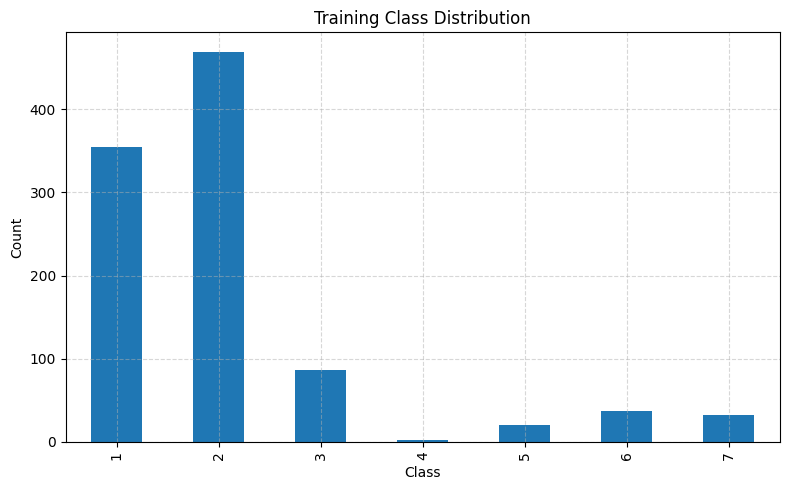

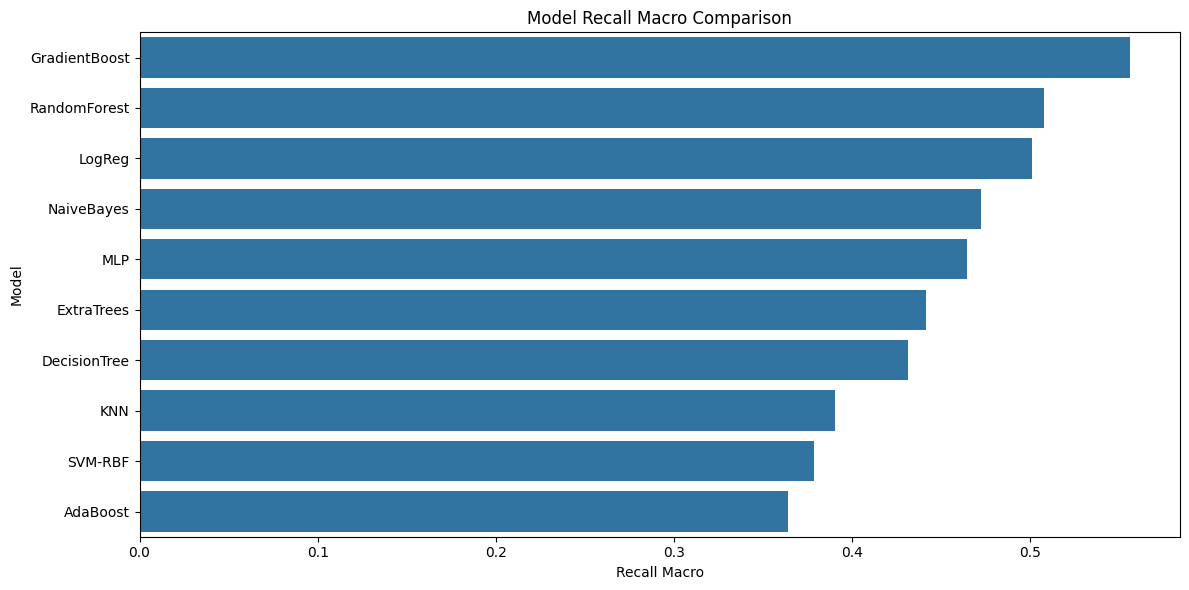


ForestDiffusion - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,Precision_Macro,Recall_Macro,Precision_Weighted,Recall_Weighted
7,GradientBoost,0.740,0.521827,0.556284,0.740178,0.740
5,RandomForest,0.745,0.660093,0.507771,0.738719,0.745
0,LogReg,0.665,0.446553,0.501123,0.739892,0.665
3,NaiveBayes,0.250,0.345849,0.472471,0.449010,0.250
9,MLP,0.705,0.520016,0.464588,0.696402,0.705
6,ExtraTrees,0.730,0.479921,0.441734,0.695469,0.730
4,DecisionTree,0.600,0.398260,0.431175,0.596879,0.600
2,KNN,0.645,0.405887,0.390156,0.629289,0.645
1,SVM-RBF,0.615,0.356976,0.378483,0.668920,0.615
8,AdaBoost,0.665,0.326661,0.363888,0.620789,0.665



ForestDiffusion - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,Precision_Macro_TRTR,Recall_Macro_TRTR,Precision_Weighted_TRTR,Recall_Weighted_TRTR,Accuracy_TSTR,Precision_Macro_TSTR,Recall_Macro_TSTR,Precision_Weighted_TSTR,Recall_Weighted_TSTR,Accuracy_Drop,Precision_Macro_Drop,Recall_Macro_Drop,Precision_Weighted_Drop,Recall_Weighted_Drop,Synthetic_Model
1,SVM-RBF,0.595,0.466460,0.607538,0.695333,0.595,0.615,0.356976,0.378483,0.668920,0.615,-0.020,0.109484,0.229056,0.026414,-0.020,ForestDiffusion
0,LogReg,0.645,0.527779,0.647350,0.733762,0.645,0.665,0.446553,0.501123,0.739892,0.665,-0.020,0.081226,0.146226,-0.006130,-0.020,ForestDiffusion
2,MLP,0.750,0.607018,0.543350,0.743683,0.750,0.705,0.520016,0.464588,0.696402,0.705,0.045,0.087002,0.078762,0.047281,0.045,ForestDiffusion
4,ExtraTrees,0.735,0.603885,0.508462,0.722590,0.735,0.730,0.479921,0.441734,0.695469,0.730,0.005,0.123964,0.066729,0.027121,0.005,ForestDiffusion
6,DecisionTree,0.700,0.485039,0.489752,0.704627,0.700,0.600,0.398260,0.431175,0.596879,0.600,0.100,0.086779,0.058576,0.107748,0.100,ForestDiffusion
5,NaiveBayes,0.185,0.384983,0.503330,0.689983,0.185,0.250,0.345849,0.472471,0.449010,0.250,-0.065,0.039133,0.030860,0.240973,-0.065,ForestDiffusion
8,KNN,0.690,0.569266,0.413330,0.687231,0.690,0.645,0.405887,0.390156,0.629289,0.645,0.045,0.163379,0.023174,0.057942,0.045,ForestDiffusion
9,AdaBoost,0.610,0.404655,0.383038,0.609878,0.610,0.665,0.326661,0.363888,0.620789,0.665,-0.055,0.077993,0.019150,-0.010910,-0.055,ForestDiffusion
3,GradientBoost,0.745,0.590621,0.540475,0.731214,0.745,0.740,0.521827,0.556284,0.740178,0.740,0.005,0.068794,-0.015809,-0.008964,0.005,ForestDiffusion
7,RandomForest,0.745,0.635124,0.473141,0.736211,0.745,0.745,0.660093,0.507771,0.738719,0.745,0.000,-0.024969,-0.034630,-0.002508,0.000,ForestDiffusion



Average Performance Drop (Lower is Better)


,Synthetic_Model,Accuracy_Drop,Precision_Macro_Drop,Recall_Macro_Drop,Precision_Weighted_Drop,Recall_Weighted_Drop
0,ForestDiffusion,0.004,0.081279,0.060209,0.047897,0.004
1,TabDDPM,0.227,0.367518,0.315806,0.336509,0.227


In [35]:
import pandas as pd
import numpy as np

# =====================================================
# SETTINGS
# =====================================================

label_col = "Cover_Type"

model_order = [
    "TabDDPM",
    "ForestDiffusion"
]

# =====================================================
# PREPARE REAL DATA
# =====================================================

real_eval = real_sample.copy()

real_eval = (
    real_eval
    .loc[:, ~real_eval.columns.duplicated()]
    .copy()
)

if label_col not in real_eval.columns:

    real_eval = real_eval.rename(
        columns={
            real_eval.columns[-1]: label_col
        }
    )

# -----------------------------------------------------
# Convert object columns to numeric
# -----------------------------------------------------

for col in real_eval.columns:

    if real_eval[col].dtype == "object":

        real_eval[col] = pd.to_numeric(
            real_eval[col],
            errors="coerce"
        )

real_eval = real_eval.dropna()

# =====================================================
# TRTR
# =====================================================

trtr_results = evaluate_models(

    train_df=real_eval,

    test_df=real_eval,

    label_col=label_col,

    models=models
)

print("\nTRTR (Train Real, Test Real)")

display(trtr_results)

print("=" * 100)

# =====================================================
# STORE COMPARISONS
# =====================================================

all_comparisons = []

# =====================================================
# LOOP THROUGH SYNTHETIC MODELS
# =====================================================

for synth_name in model_order:

    print(f"\nProcessing: {synth_name}")

    # -------------------------------------------------
    # PREPARE SYNTHETIC DATA
    # -------------------------------------------------

    synth_eval = synthetic_outputs[
        synth_name
    ].copy()

    synth_eval = (
        synth_eval
        .loc[:, ~synth_eval.columns.duplicated()]
        .copy()
    )

    if label_col not in synth_eval.columns:

        synth_eval = synth_eval.rename(
            columns={
                synth_eval.columns[-1]: label_col
            }
        )

    # -------------------------------------------------
    # Convert object columns
    # -------------------------------------------------

    for col in synth_eval.columns:

        if synth_eval[col].dtype == "object":

            synth_eval[col] = pd.to_numeric(
                synth_eval[col],
                errors="coerce"
            )

    synth_eval = synth_eval.dropna()

    # -------------------------------------------------
    # ALIGN COLUMNS
    # -------------------------------------------------

    shared_cols = [

        c for c in real_eval.columns

        if c in synth_eval.columns
    ]

    synth_eval = synth_eval[
        shared_cols
    ]

    real_eval_aligned = real_eval[
        shared_cols
    ]

    # =================================================
    # TSTR
    # =================================================

    tstr_results = evaluate_models(

        train_df=synth_eval,

        test_df=real_eval_aligned,

        label_col=label_col,

        models=models
    )

    print(
        f"\n{synth_name} - "
        f"TSTR (Train Synthetic, Test Real)"
    )

    display(tstr_results)

    # =================================================
    # MERGE RESULTS
    # =================================================

    comparison = trtr_results.merge(

        tstr_results,

        on="Model",

        suffixes=(
            "_TRTR",
            "_TSTR"
        )
    )

    # =================================================
    # PERFORMANCE DROPS
    # =================================================

    drop_metrics = {

        # ---------------- Accuracy ----------------

        "Accuracy_Drop": (

            "Accuracy_TRTR",

            "Accuracy_TSTR"
        ),

        # ------------ Macro Metrics ------------

        "Precision_Macro_Drop": (

            "Precision_Macro_TRTR",

            "Precision_Macro_TSTR"
        ),

        "Recall_Macro_Drop": (

            "Recall_Macro_TRTR",

            "Recall_Macro_TSTR"
        ),

        # ----------- Weighted Metrics -----------

        "Precision_Weighted_Drop": (

            "Precision_Weighted_TRTR",

            "Precision_Weighted_TSTR"
        ),

        "Recall_Weighted_Drop": (

            "Recall_Weighted_TRTR",

            "Recall_Weighted_TSTR"
        ),
    }

    # -------------------------------------------------
    # Compute drops
    # -------------------------------------------------

    for drop_col, (
        trtr_col,
        tstr_col
    ) in drop_metrics.items():

        if (
            trtr_col in comparison.columns
            and
            tstr_col in comparison.columns
        ):

            comparison[drop_col] = (

                comparison[trtr_col]

                -

                comparison[tstr_col]
            )

    # =================================================
    # ADD SYNTHETIC MODEL NAME
    # =================================================

    comparison[
        "Synthetic_Model"
    ] = synth_name

    # =================================================
    # SORT BY MOST IMPORTANT METRIC
    # =================================================

    # For imbalance problems,
    # Recall_Macro is most important

    sort_col = "Recall_Macro_Drop"

    if sort_col in comparison.columns:

        comparison = comparison.sort_values(

            by=sort_col,

            ascending=False
        )

    # =================================================
    # DISPLAY COMPARISON
    # =================================================

    print(
        f"\n{synth_name} "
        f"- TRTR vs TSTR Comparison"
    )

    display(comparison)

    print("=" * 100)

    all_comparisons.append(
        comparison
    )

# =====================================================
# COMBINED SUMMARY
# =====================================================

if all_comparisons:

    combined_comparison = pd.concat(

        all_comparisons,

        ignore_index=True
    )

    metric_cols = [

        c for c in [

            "Accuracy_Drop",

            "Precision_Macro_Drop",

            "Recall_Macro_Drop",

            "Precision_Weighted_Drop",

            "Recall_Weighted_Drop"
        ]

        if c in combined_comparison.columns
    ]

    if metric_cols:

        summary = (

            combined_comparison

            .groupby(
                "Synthetic_Model",
                as_index=False
            )[metric_cols]

            .mean()

            .sort_values(
                by="Recall_Macro_Drop"
            )
        )

        print(
            "\nAverage Performance Drop "
            "(Lower is Better)"
        )

        display(summary)

    else:

        print(
            "No drop metrics available."
        )

else:

    print(
        "No synthetic model "
        "comparisons computed."
    )


In [36]:
import pandas as pd

# Identify all 40 Soil_Type columns
soil_type_cols = [col for col in data.columns if col.startswith('Soil_Type')]

# Drop them to create a cleaned dataset
data_cleaned = data.drop(columns=soil_type_cols)

print(f"Dropped {len(soil_type_cols)} Soil_Type columns.")
print(f"New dataset shape: {data_cleaned.shape}")
print("Remaining columns:", data_cleaned.columns.tolist())

# Update real_sample for the evaluation pipeline
real_sample = data_cleaned.copy()

Dropped 40 Soil_Type columns.
New dataset shape: (1000, 15)
Remaining columns: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Cover_Type']


In [37]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

# =====================================================
# MODELS WITH IMBALANCE HANDLING
# =====================================================

models = {
    "LogReg": LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ),
    "SVM-RBF": SVC(
        class_weight="balanced",
        probability=False
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoost": GradientBoostingClassifier(
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=1000,
        random_state=42
    ),
}

# =====================================================
# CLEAN LABELS
# =====================================================

def clean_cover_type_labels(y):
    y = pd.Series(y).copy()
    y = pd.to_numeric(y, errors="coerce")
    y = y.round().astype("Int64")
    return y

# =====================================================
# EVALUATION FUNCTION
# =====================================================

def evaluate_models(
    train_df,
    test_df,
    label_col,
    models=models,
    test_size=0.2,
    seed=42,
    no_split=False
):
    # -------------------------------------------------
    # REMOVE DUPLICATE COLUMNS
    # -------------------------------------------------
    train_df = train_df.loc[:, ~train_df.columns.duplicated()].copy()
    test_df = test_df.loc[:, ~test_df.columns.duplicated()].copy()

    # -------------------------------------------------
    # ENSURE LABEL EXISTS
    # -------------------------------------------------
    if label_col not in train_df.columns:
        train_df = train_df.rename(columns={train_df.columns[-1]: label_col})
    if label_col not in test_df.columns:
        test_df = test_df.rename(columns={test_df.columns[-1]: label_col})

    # -------------------------------------------------
    # ALIGN COLUMNS
    # -------------------------------------------------
    common_cols = train_df.columns.intersection(test_df.columns)
    train_df = train_df[common_cols].copy()
    test_df = test_df[common_cols].copy()

    # -------------------------------------------------
    # NUMERIC FEATURES ONLY
    # -------------------------------------------------
    num_cols = [c for c in common_cols if c != label_col]
    X_train = train_df[num_cols].apply(pd.to_numeric, errors="coerce")
    X_test = test_df[num_cols].apply(pd.to_numeric, errors="coerce")

    # -------------------------------------------------
    # HANDLE MISSING VALUES
    # -------------------------------------------------
    train_medians = X_train.median(numeric_only=True)
    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    # -------------------------------------------------
    # LABELS
    # -------------------------------------------------
    y_train = pd.to_numeric(train_df[label_col], errors="coerce").round()
    y_test = pd.to_numeric(test_df[label_col], errors="coerce").round()

    train_valid = y_train.notna()
    test_valid = y_test.notna()

    X_train = X_train.loc[train_valid]
    y_train = y_train.loc[train_valid].astype(int)

    X_test = X_test.loc[test_valid]
    y_test = y_test.loc[test_valid].astype(int)

    # -------------------------------------------------
    # KEEP COMMON CLASSES ONLY
    # -------------------------------------------------
    common_classes = sorted(set(y_train.unique()).intersection(set(y_test.unique())))
    X_train = X_train.loc[y_train.isin(common_classes)]
    y_train = y_train.loc[y_train.isin(common_classes)]
    X_test = X_test.loc[y_test.isin(common_classes)]
    y_test = y_test.loc[y_test.isin(common_classes)]

    if len(common_classes) < 2:
        raise ValueError("Need at least 2 common classes.")

    # -------------------------------------------------
    # CLASS DISTRIBUTION
    # -------------------------------------------------
    print("\nTraining Class Distribution:")
    print(y_train.value_counts().sort_index())
    print("\nTraining Class Percentages:")
    print((y_train.value_counts(normalize=True) * 100).sort_index().round(2))

    # -------------------------------------------------
    # STRATIFICATION
    # -------------------------------------------------
    stratify_train = y_train if y_train.value_counts().min() >= 2 else None
    stratify_test = y_test if y_test.value_counts().min() >= 2 else None

    # -------------------------------------------------
    # TRAIN TEST SPLIT
    # -------------------------------------------------
    if not no_split:
        if len(X_train) > 1:
            X_train, _, y_train, _ = train_test_split(
                X_train, y_train, test_size=test_size, random_state=seed, stratify=stratify_train
            )
        if len(X_test) > 1:
            _, X_test, _, y_test = train_test_split(
                X_test, y_test, test_size=test_size, random_state=seed, stratify=stratify_test
            )

    # -------------------------------------------------
    # FEATURE SCALING
    # -------------------------------------------------
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # =================================================
    # MODEL TRAINING
    # =================================================
    rows = []
    for name, clf in models.items():
        try:
            clf.fit(X_train_s, y_train)
            y_pred = clf.predict(X_test_s)

            acc = accuracy_score(y_test, y_pred)
            precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
            recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
            precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
            recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)

            rows.append({
                "Model": name,
                "Accuracy": acc,
                "Precision_Macro": precision_macro,
                "Recall_Macro": recall_macro,
                "Precision_Weighted": precision_weighted,
                "Recall_Weighted": recall_weighted
            })
        except Exception as e:
            print(f"Error with {name}: {str(e)[:120]}")
            rows.append({
                "Model": name,
                "Accuracy": np.nan,
                "Precision_Macro": np.nan,
                "Recall_Macro": np.nan,
                "Precision_Weighted": np.nan,
                "Recall_Weighted": np.nan
            })

    return pd.DataFrame(rows).sort_values(by="Recall_Macro", ascending=False)


In [38]:
import pandas as pd
import numpy as np

# =====================================================
# SETTINGS
# =====================================================

label_col = "Cover_Type"

model_order = [
    "TabDDPM",
    "ForestDiffusion"
]

# =====================================================
# PREPARE REAL DATA
# =====================================================

real_eval = real_sample.copy()

real_eval = (
    real_eval
    .loc[:, ~real_eval.columns.duplicated()]
    .copy()
)

if label_col not in real_eval.columns:

    real_eval = real_eval.rename(
        columns={
            real_eval.columns[-1]: label_col
        }
    )

# -----------------------------------------------------
# Convert object columns to numeric
# -----------------------------------------------------

for col in real_eval.columns:

    if real_eval[col].dtype == "object":

        real_eval[col] = pd.to_numeric(
            real_eval[col],
            errors="coerce"
        )

real_eval = real_eval.dropna()

# =====================================================
# TRTR
# =====================================================

trtr_results = evaluate_models(

    train_df=real_eval,

    test_df=real_eval,

    label_col=label_col,

    models=models
)

print("\nTRTR (Train Real, Test Real)")

display(trtr_results)

print("=" * 100)

# =====================================================
# STORE COMPARISONS
# =====================================================

all_comparisons = []

# =====================================================
# LOOP THROUGH SYNTHETIC MODELS
# =====================================================

for synth_name in model_order:

    print(f"\nProcessing: {synth_name}")

    # -------------------------------------------------
    # PREPARE SYNTHETIC DATA
    # -------------------------------------------------

    synth_eval = synthetic_outputs[
        synth_name
    ].copy()

    synth_eval = (
        synth_eval
        .loc[:, ~synth_eval.columns.duplicated()]
        .copy()
    )

    if label_col not in synth_eval.columns:

        synth_eval = synth_eval.rename(
            columns={
                synth_eval.columns[-1]: label_col
            }
        )

    # -------------------------------------------------
    # Convert object columns
    # -------------------------------------------------

    for col in synth_eval.columns:

        if synth_eval[col].dtype == "object":

            synth_eval[col] = pd.to_numeric(
                synth_eval[col],
                errors="coerce"
            )

    synth_eval = synth_eval.dropna()

    # -------------------------------------------------
    # ALIGN COLUMNS
    # -------------------------------------------------

    shared_cols = [

        c for c in real_eval.columns

        if c in synth_eval.columns
    ]

    synth_eval = synth_eval[
        shared_cols
    ]

    real_eval_aligned = real_eval[
        shared_cols
    ]

    # =================================================
    # TSTR
    # =================================================

    tstr_results = evaluate_models(

        train_df=synth_eval,

        test_df=real_eval_aligned,

        label_col=label_col,

        models=models
    )

    print(
        f"\n{synth_name} - "
        f"TSTR (Train Synthetic, Test Real)"
    )

    display(tstr_results)

    # =================================================
    # MERGE RESULTS (Fixed SyntaxError)
    # =================================================

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=(
            "_TRTR",
            "_TSTR"
        )
    )

    # =================================================
    # PERFORMANCE DROPS
    # =================================================

    drop_metrics = {
        "Accuracy_Drop": ("Accuracy_TRTR", "Accuracy_TSTR"),
        "Precision_Macro_Drop": ("Precision_Macro_TRTR", "Precision_Macro_TSTR"),
        "Recall_Macro_Drop": ("Recall_Macro_TRTR", "Recall_Macro_TSTR"),
        "Precision_Weighted_Drop": ("Precision_Weighted_TRTR", "Precision_Weighted_TSTR"),
        "Recall_Weighted_Drop": ("Recall_Weighted_TRTR", "Recall_Weighted_TSTR"),
    }

    for drop_col, (trtr_col, tstr_col) in drop_metrics.items():

        if (
            trtr_col in comparison.columns
            and
            tstr_col in comparison.columns
        ):

            comparison[drop_col] = (
                comparison[trtr_col]
                -
                comparison[tstr_col]
            )

    comparison["Synthetic_Model"] = synth_name

    sort_col = "Recall_Macro_Drop"

    if sort_col in comparison.columns:

        comparison = comparison.sort_values(
            by=sort_col,
            ascending=False
        )

    print(f"\n{synth_name} - TRTR vs TSTR Comparison")

    display(comparison)

    print("=" * 100)

    all_comparisons.append(comparison)

# =====================================================
# COMBINED SUMMARY
# =====================================================

if all_comparisons:

    combined_comparison = pd.concat(
        all_comparisons,
        ignore_index=True
    )

    metric_cols = [
        "Accuracy_Drop",
        "Precision_Macro_Drop",
        "Recall_Macro_Drop",
        "Precision_Weighted_Drop",
        "Recall_Weighted_Drop"
    ]

    metric_cols = [c for c in metric_cols if c in combined_comparison.columns]

    if metric_cols:

        summary = (
            combined_comparison
            .groupby("Synthetic_Model", as_index=False)[metric_cols]
            .mean()
            .sort_values(by="Recall_Macro_Drop")
        )

        print("\nAverage Performance Drop (Lower is Better)")

        display(summary)
    else:
        print("No drop metrics available.")
else:
    print("No synthetic model comparisons computed.")



Training Class Distribution:
Cover_Type
1    353
2    483
3     74
4      2
5     21
6     35
7     32
Name: count, dtype: int64

Training Class Percentages:
Cover_Type
1    35.3
2    48.3
3     7.4
4     0.2
5     2.1
6     3.5
7     3.2
Name: proportion, dtype: float64

TRTR (Train Real, Test Real)


,Model,Accuracy,Precision_Macro,Recall_Macro,Precision_Weighted,Recall_Weighted
3,NaiveBayes,0.320,0.348725,0.591482,0.275953,0.320
7,GradientBoost,0.745,0.580151,0.540475,0.732502,0.745
6,ExtraTrees,0.730,0.689957,0.513128,0.732521,0.730
4,DecisionTree,0.690,0.488214,0.512375,0.684264,0.690
1,SVM-RBF,0.590,0.447640,0.493091,0.701918,0.590
5,RandomForest,0.745,0.584755,0.487727,0.727424,0.745
0,LogReg,0.590,0.420488,0.478434,0.719812,0.590
9,MLP,0.730,0.675021,0.451247,0.745414,0.730
2,KNN,0.665,0.579250,0.414132,0.661346,0.665
8,AdaBoost,0.695,0.445205,0.404469,0.655288,0.695



Processing: TabDDPM

Training Class Distribution:
Cover_Type
1    362
2    479
3     58
4      1
5     24
6     37
7     39
Name: count, dtype: int64

Training Class Percentages:
Cover_Type
1    36.2
2    47.9
3     5.8
4     0.1
5     2.4
6     3.7
7     3.9
Name: proportion, dtype: float64

TabDDPM - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,Precision_Macro,Recall_Macro,Precision_Weighted,Recall_Weighted
0,LogReg,0.165,0.193828,0.322599,0.442763,0.165
1,SVM-RBF,0.280,0.204750,0.232336,0.464316,0.280
9,MLP,0.365,0.157069,0.208380,0.365757,0.365
2,KNN,0.465,0.155330,0.184962,0.398402,0.465
5,RandomForest,0.410,0.316953,0.184378,0.423761,0.410
7,GradientBoost,0.380,0.141398,0.164561,0.366177,0.380
8,AdaBoost,0.350,0.100340,0.163690,0.246224,0.350
6,ExtraTrees,0.440,0.136085,0.161899,0.351807,0.440
3,NaiveBayes,0.365,0.110147,0.134868,0.293062,0.365
4,DecisionTree,0.230,0.290332,0.108680,0.366502,0.230



TabDDPM - TRTR vs TSTR Comparison


...

,Model,Accuracy,Precision_Macro,Recall_Macro,Precision_Weighted,Recall_Weighted
7,GradientBoost,0.735,0.544673,0.542463,0.735921,0.735
1,SVM-RBF,0.655,0.468212,0.537625,0.691237,0.655
4,DecisionTree,0.615,0.457819,0.505745,0.618335,0.615
0,LogReg,0.605,0.410711,0.500033,0.721405,0.605
9,MLP,0.690,0.593349,0.499052,0.689840,0.690
6,ExtraTrees,0.720,0.555436,0.465808,0.702984,0.720
5,RandomForest,0.750,0.621017,0.461968,0.737383,0.750
3,NaiveBayes,0.365,0.422252,0.446534,0.730911,0.365
2,KNN,0.670,0.396447,0.395248,0.629959,0.670
8,AdaBoost,0.665,0.326661,0.363888,0.620789,0.665



ForestDiffusion - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,Precision_Macro_TRTR,Recall_Macro_TRTR,Precision_Weighted_TRTR,Recall_Weighted_TRTR,Accuracy_TSTR,Precision_Macro_TSTR,Recall_Macro_TSTR,Precision_Weighted_TSTR,Recall_Weighted_TSTR,Accuracy_Drop,Precision_Macro_Drop,Recall_Macro_Drop,Precision_Weighted_Drop,Recall_Weighted_Drop,Synthetic_Model
0,NaiveBayes,0.320,0.348725,0.591482,0.275953,0.320,0.365,0.422252,0.446534,0.730911,0.365,-0.045,-0.073527,0.144948,-0.454958,-0.045,ForestDiffusion
2,ExtraTrees,0.730,0.689957,0.513128,0.732521,0.730,0.720,0.555436,0.465808,0.702984,0.720,0.010,0.134521,0.047320,0.029537,0.010,ForestDiffusion
9,AdaBoost,0.695,0.445205,0.404469,0.655288,0.695,0.665,0.326661,0.363888,0.620789,0.665,0.030,0.118544,0.040580,0.034499,0.030,ForestDiffusion
5,RandomForest,0.745,0.584755,0.487727,0.727424,0.745,0.750,0.621017,0.461968,0.737383,0.750,-0.005,-0.036262,0.025759,-0.009958,-0.005,ForestDiffusion
8,KNN,0.665,0.579250,0.414132,0.661346,0.665,0.670,0.396447,0.395248,0.629959,0.670,-0.005,0.182803,0.018883,0.031386,-0.005,ForestDiffusion
3,DecisionTree,0.690,0.488214,0.512375,0.684264,0.690,0.615,0.457819,0.505745,0.618335,0.615,0.075,0.030395,0.006630,0.065929,0.075,ForestDiffusion
1,GradientBoost,0.745,0.580151,0.540475,0.732502,0.745,0.735,0.544673,0.542463,0.735921,0.735,0.010,0.035478,-0.001988,-0.003419,0.010,ForestDiffusion
6,LogReg,0.590,0.420488,0.478434,0.719812,0.590,0.605,0.410711,0.500033,0.721405,0.605,-0.015,0.009777,-0.021599,-0.001593,-0.015,ForestDiffusion
4,SVM-RBF,0.590,0.447640,0.493091,0.701918,0.590,0.655,0.468212,0.537625,0.691237,0.655,-0.065,-0.020572,-0.044534,0.010681,-0.065,ForestDiffusion
7,MLP,0.730,0.675021,0.451247,0.745414,0.730,0.690,0.593349,0.499052,0.689840,0.690,0.040,0.081672,-0.047805,0.055574,0.040,ForestDiffusion



Average Performance Drop (Lower is Better)


,Synthetic_Model,Accuracy_Drop,Precision_Macro_Drop,Recall_Macro_Drop,Precision_Weighted_Drop,Recall_Weighted_Drop
0,ForestDiffusion,0.003,0.046283,0.016819,-0.024232,0.003
1,TabDDPM,0.305,0.345318,0.302021,0.291767,0.305


# 5 Statistical similarity tests

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,155.782467,50.116986,147.421090
1,ForestDiffusion,4.865763,2.724486,10.299234


/tmp/ipykernel_3559824/1626139294.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
/tmp/ipykernel_3559824/1626139294.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
/tmp/ipykernel_3559824/1626139294.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")


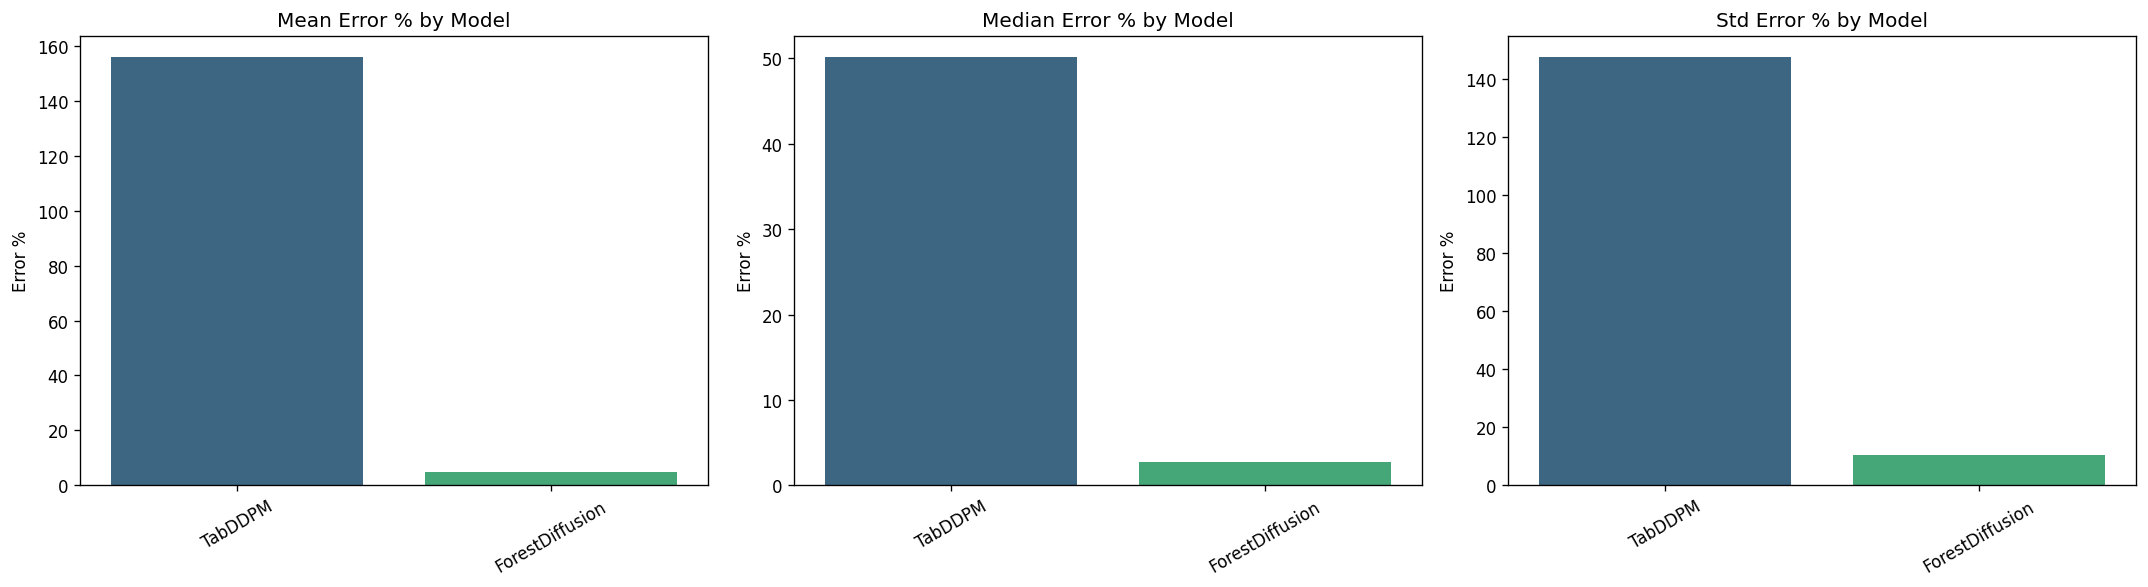

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "Cover_Type"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_df_aligned = _coerce_numeric_df(real_df, num_cols)
real_medians = real_df_aligned.median(numeric_only=True)
real_df_aligned = real_df_aligned.fillna(real_medians)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians)

    real_means = real_df_aligned.mean()
    synth_means = synth_df.mean()

    real_stds = real_df_aligned.std(ddof=1)
    synth_stds = synth_df.std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


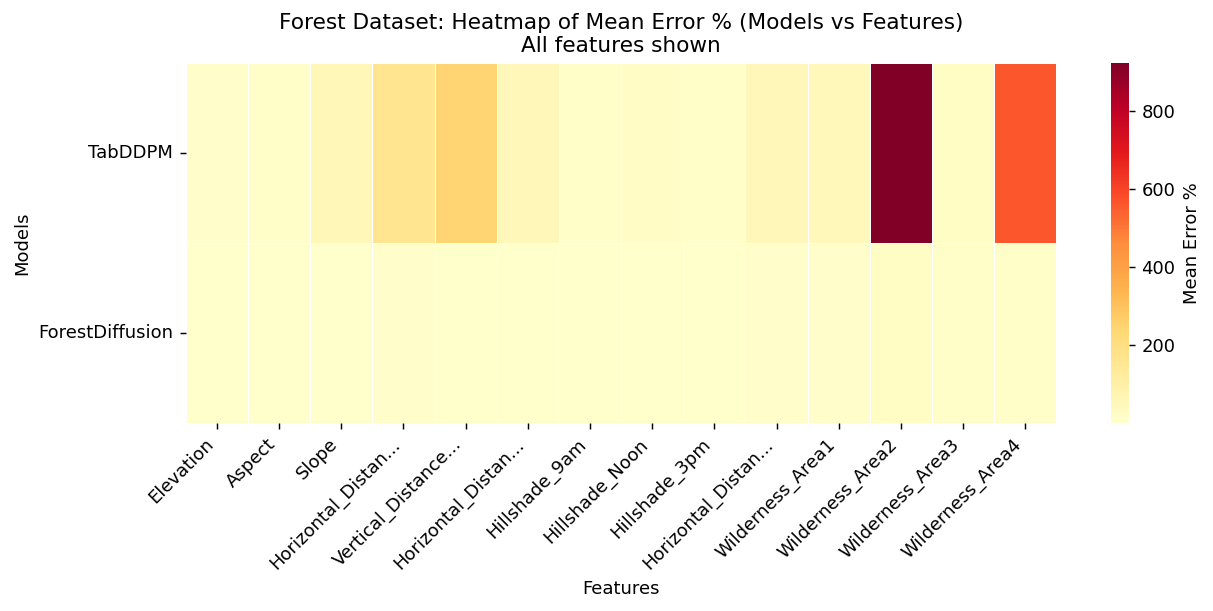

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

# Create heatmap from feature_error_by_model (previous cell)
heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Forest Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


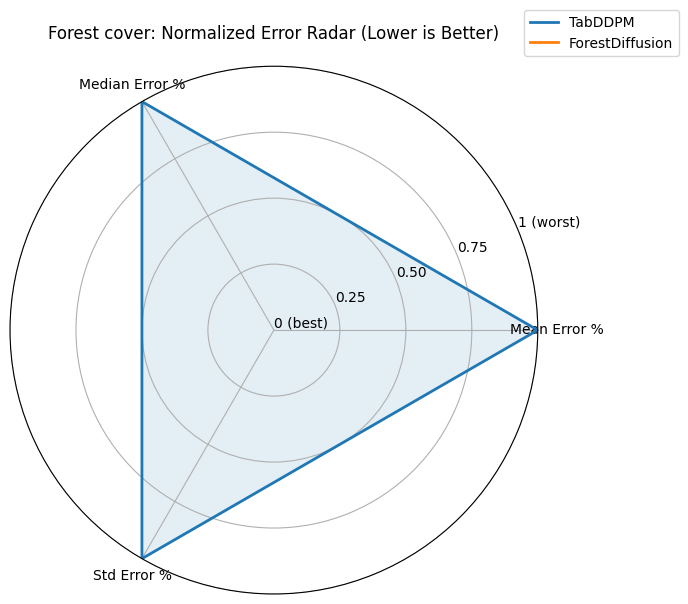

,Model,Mean Error %,Median Error %,Std Error %
0,TabDDPM,1.0,1.0,1.0
1,ForestDiffusion,0.0,0.0,0.0


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requires summary_df with columns:
# ["Model", "Mean Error %", "Median Error %", "Std Error %"]
# from previous statistical moments cell

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best / lowest error, 1 = worst / highest error)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Forest cover: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,ForestDiffusion,8.071429,8.0,19
1,TabDDPM,31.142857,34.5,72


/tmp/ipykernel_3559824/872643410.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")


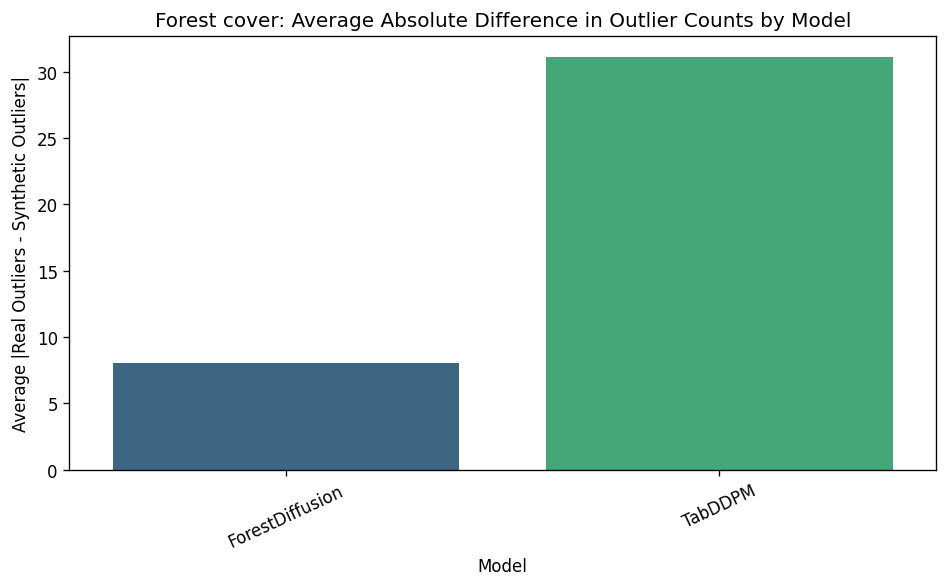

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["TabDDPM", "ForestDiffusion"]

target_col = "Cover_Type"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

# Handle NaN before outlier detection
real_df_clean = _coerce_numeric_df(real_df, num_cols)
real_medians = real_df_clean.median(numeric_only=True)
real_df_clean = real_df_clean.fillna(real_medians)
real_outliers = {c: outlier_count_iqr(real_df_clean[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_outputs[model].copy()

    # Clean synthetic data and align columns
    synth_df_clean = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians)
    synth_num_cols = [c for c in num_cols if c in synth_df_clean.columns]

    synth_outliers = {c: outlier_count_iqr(synth_df_clean[c]) for c in synth_num_cols}

    feat_df = pd.DataFrame({
        "Feature": synth_num_cols,
        "Real_Outliers": [real_outliers[c] for c in synth_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in synth_num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Forest cover: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [44]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(real_df, synth_df, num_cols=None, target_col=None):
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col is None:
        target_col = "Cover_Type"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R_clean = _coerce_numeric_df(real_df, num_cols)
    S_clean = _coerce_numeric_df(synth_df, num_cols)
    real_medians = R_clean.median(numeric_only=True)
    R_clean = R_clean.fillna(real_medians).to_numpy(dtype=float)
    S_clean = S_clean.fillna(real_medians).to_numpy(dtype=float)

    return normalize_rows(R_clean) @ normalize_rows(S_clean).T

# Fixed for Adult dataset pipeline
synthetic_data = synthetic_outputs

cosine_results = {}
cosine_dfs = {}

model_order = ["TabDDPM", "ForestDiffusion"]
target_col = "Cover_Type"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_aligned = _coerce_numeric_df(real_df, num_cols)
real_medians = real_aligned.median(numeric_only=True)
real_matrix = normalize_rows(real_aligned.fillna(real_medians).to_numpy(dtype=float))

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"Warning: {model_name} not found. Available: {list(synthetic_data.keys())}")
        continue

    synth_df = synthetic_data[model_name].copy()

    # Clean and align columns
    synth_clean = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians)
    print(f"Building cosine similarity for {model_name}...")

    synth_matrix = normalize_rows(synth_clean.to_numpy(dtype=float))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(f"{model_name} cosine sample:\n", cosine_df.round(3), "\n")

display(pd.DataFrame(cosine_results).T)


Building cosine similarity for TabDDPM...
TabDDPM cosine sample:
         S1     S2     S3     S4     S5     S6     S7     S8     S9    S10
R1   0.616  0.592  0.884  0.824  0.613  0.943  0.665  0.593  0.621  0.943
R2   0.875  0.782  0.624  0.575  0.892  0.743  0.696  0.784  0.891  0.744
R3   0.726  0.649  0.753  0.460  0.739  0.841  0.899  0.655  0.738  0.842
R4   0.379  0.352  0.923  0.500  0.378  0.942  0.903  0.354  0.385  0.942
R5   0.452  0.397  0.804  0.305  0.456  0.841  0.971  0.399  0.460  0.842
R6   0.980  0.869  0.351  0.362  0.974  0.492  0.589  0.866  0.981  0.492
R7   0.371  0.374  0.987  0.743  0.363  0.998  0.752  0.374  0.375  0.999
R8   0.766  0.721  0.749  0.527  0.777  0.843  0.859  0.724  0.775  0.844
R9   0.891  0.835  0.502  0.329  0.908  0.630  0.797  0.838  0.902  0.631
R10  0.939  0.807  0.434  0.479  0.963  0.576  0.569  0.813  0.956  0.577 

Building cosine similarity for ForestDiffusion...
ForestDiffusion cosine sample:
         S1     S2     S3     S4     

,avg_cosine,max_cosine
TabDDPM,0.720654,0.999512
ForestDiffusion,0.901380,0.999996


In [45]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    target_col = "Group" if "Group" in real_data.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


TabDDPM - Top 10 Real -> Synthetic Matchings
01. R345 -> S12   cosine similarity = 0.9995
02. R209 -> S12   cosine similarity = 0.9995
03. R743 -> S229   cosine similarity = 0.9994
04. R871 -> S12   cosine similarity = 0.9992
05. R7 -> S469   cosine similarity = 0.9992
06. R548 -> S484   cosine similarity = 0.9987
07. R436 -> S12   cosine similarity = 0.9984
08. R484 -> S229   cosine similarity = 0.9983
09. R158 -> S12   cosine similarity = 0.9982
10. R693 -> S167   cosine similarity = 0.9980

ForestDiffusion - Top 10 Real -> Synthetic Matchings
01. R348 -> S394   cosine similarity = 1.0000
02. R120 -> S480   cosine similarity = 1.0000
03. R857 -> S36   cosine similarity = 1.0000
04. R38 -> S140   cosine similarity = 1.0000
05. R928 -> S17   cosine similarity = 1.0000
06. R516 -> S113   cosine similarity = 1.0000
07. R154 -> S730   cosine similarity = 1.0000
08. R811 -> S67   cosine similarity = 1.0000
09. R484 -> S544   cosine similarity = 1.0000
10. R69 -> S574   cosine similarity =

In [46]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    target_col = "Group" if "Group" in real_df.columns else "Group"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()

# Use your actual synthetic DataFrames here
# Use TabDDPM and ForestDiffusion synthetic outputs
synthetic_data = {
    "TabDDPM": synthetic_outputs["TabDDPM"],
    "ForestDiffusion": synthetic_outputs["ForestDiffusion"],
}

results = {}

for name, synth_df in synthetic_data.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features)")
    print(f"==============================")

    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common].copy()

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

summary_df = pd.DataFrame(
    [{"Model": name, "Avg_Hungarian_Cosine": info["avg_similarity"]} for name, info in results.items()]
).sort_values("Avg_Hungarian_Cosine", ascending=False)

display(summary_df)



TabDDPM: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.8915

R953 <-> S164   cosine similarity = 0.9925
R558 <-> S417   cosine similarity = 0.9917
R393 <-> S310   cosine similarity = 0.9911
R320 <-> S656   cosine similarity = 0.9893
R427 <-> S62   cosine similarity = 0.9881
R436 <-> S719   cosine similarity = 0.9876
R682 <-> S797   cosine similarity = 0.9874
R658 <-> S901   cosine similarity = 0.9870
R7 <-> S497   cosine similarity = 0.9868
R548 <-> S74   cosine similarity = 0.9865

ForestDiffusion: Hungarian matching (cosine, numeric features)
Average cosine similarity (Hungarian match): 0.9975

R857 <-> S36   cosine similarity = 1.0000
R811 <-> S67   cosine similarity = 1.0000
R69 <-> S574   cosine similarity = 1.0000
R744 <-> S308   cosine similarity = 1.0000
R568 <-> S888   cosine similarity = 0.9999
R217 <-> S107   cosine similarity = 0.9999
R964 <-> S440   cosine similarity = 0.9999
R408 <-> S924   cosine similarity = 0.9999
R548 <-

,Model,Avg_Hungarian_Cosine
1,ForestDiffusion,0.997509
0,TabDDPM,0.891484


In [47]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

target_col = "Group" if "Group" in real_df.columns else "Group"
if target_col in feature_cols:
    feature_cols.remove(target_col)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_outputs
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

model_order = ["TabDDPM", "ForestDiffusion"]  # ← FIXED: Match your results keys
output_file = "Adult_Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            print(f"Skipping {model_name}: no Hungarian results found")
            continue
        if model_name not in synth_source:
            print(f"Skipping {model_name}: no synthetic data found")
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        display(summary_df)  # ← FIXED: Moved inside with block

print(f"Saved: {output_file}")


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
1,ForestDiffusion,1000,0.997509,0.998303,0.956144,0.999994
0,TabDDPM,1000,0.891484,0.910817,0.693613,0.992524


Saved: Adult_Hungarian_Matchings_All_Models.xlsx


# 7. Mahalanobis distance with Hungrain Mapping  

In [48]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

target_col = "Cover_Type"

data_numeric = real_sample.select_dtypes(include=[np.number]).copy()
if target_col in data_numeric.columns:
    data_numeric = data_numeric.drop(columns=[target_col])

num_cols = data_numeric.columns.tolist()
data_numeric = _coerce_numeric_df(real_sample, num_cols)
real_medians = data_numeric.median(numeric_only=True)
real_matrix = data_numeric.fillna(real_medians).to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (55,), Inv_cov shape: (55, 55)


In [50]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

target_col = "Cover_Type"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_aligned = _coerce_numeric_df(real_df, num_cols)
real_medians = real_aligned.median(numeric_only=True)
real_numeric = real_aligned.fillna(real_medians).to_numpy(dtype=float)

mu_real = np.mean(real_numeric, axis=0)
cov_real = np.cov(real_numeric, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

synth_source = synthetic_outputs
model_order = ["TabDDPM", "ForestDiffusion"]

mahalanobis_results = {}
available_models = []

for name in model_order:
    if name in synth_source:
        synth_df = synth_source[name].copy()
        synth_numeric = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians).to_numpy(dtype=float)

        dists = np.array([mahalanobis(x, mu_real, inv_cov_real) for x in synth_numeric])

        mahalanobis_results[name] = {
            "mean": float(np.mean(dists)),
            "median": float(np.median(dists)),
            "std": float(np.std(dists)),
            "min": float(np.min(dists)),
            "max": float(np.max(dists)),
            "distances": dists,
        }
        available_models.append(name)
        print(f"✓ {name}: mean Mahalanobis = {np.mean(dists):.3f}")
    else:
        print(f"✗ {name} not found in synthetic source. Available: {list(synth_source.keys())}")

# Create summary only for available models
if mahalanobis_results:
    summary = pd.DataFrame({
        name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
        for name, r in mahalanobis_results.items()
    }, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

    summary.index.name = "Model"
    summary = summary.sort_values("mean_dist")

    print("Mahalanobis distance to real distribution (lower is better):")
    display(summary)
else:
    print("No valid synthetic data found for Mahalanobis analysis.")

✓ TabDDPM: mean Mahalanobis = 636.568
✓ ForestDiffusion: mean Mahalanobis = 11.754
Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
ForestDiffusion,11.753581,3.184326,62.299715,1.624200,500.065922
TabDDPM,636.568492,502.238924,408.870909,13.844891,1505.741442


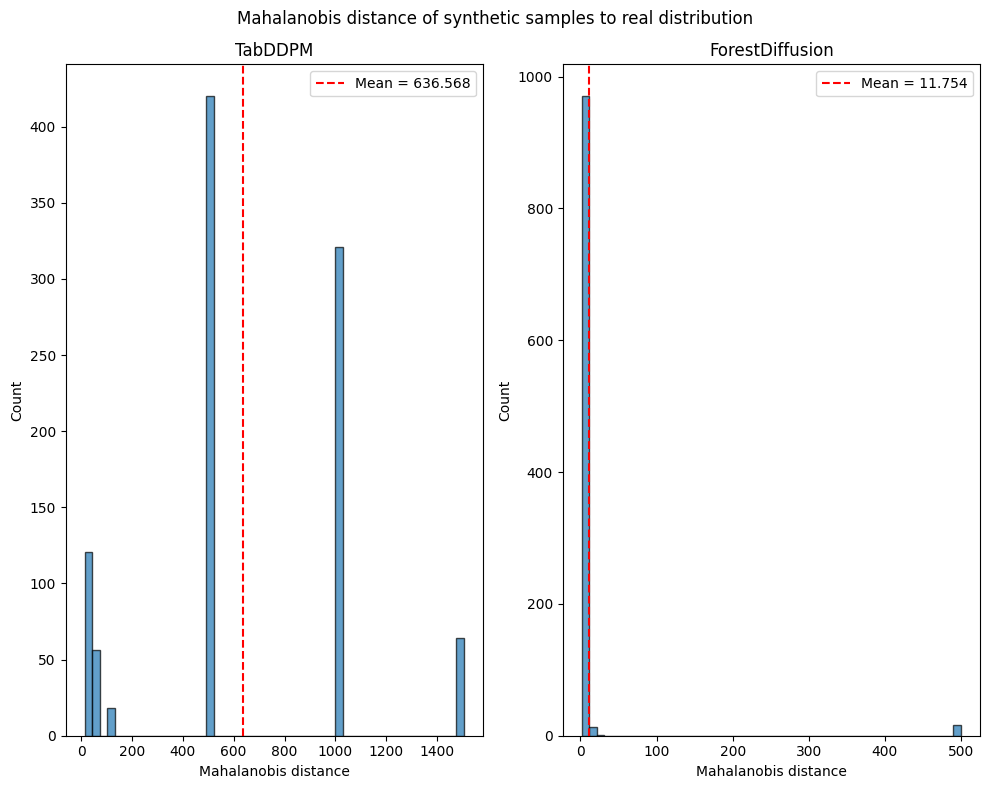

In [51]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(mahalanobis_results), figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_forestcover_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [52]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Fixed for Adult dataset pipeline
target_col = "Cover_Type"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_aligned = _coerce_numeric_df(real_df, num_cols)
real_medians = real_aligned.median(numeric_only=True)
real_matrix = real_aligned.fillna(real_medians).to_numpy(dtype=float)
cov_real = np.cov(real_matrix, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Map your synthetic outputs (from generation pipeline)
synthetic_data = synthetic_outputs

model_order = ["TabDDPM", "ForestDiffusion"]

for name in model_order:
    if name in synthetic_data:
        synth_df = synthetic_data[name].copy()
        synth_numeric = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians).to_numpy(dtype=float)

        n_matches = min(real_matrix.shape[0], synth_numeric.shape[0])
        print(f"✓ Processing {name} ({n_matches} matches from {synth_numeric.shape[0]} synth samples)")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic data. Available: {list(synthetic_data.keys())}")

# Summary table
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Adult Dataset: Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM (1000 matches from 1000 synth samples)
✓ Processing ForestDiffusion (1000 matches from 1000 synth samples)
Adult Dataset: Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,10.213563,1.699339,62.492556,500.092431,1000.0
TabDDPM,636.119261,502.141315,409.453674,1505.667604,1000.0


In [53]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

synth_source = synthetic_outputs

target_col = "Cover_Type"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_aligned = _coerce_numeric_df(real_df, num_cols)
real_medians = real_aligned.median(numeric_only=True)
real_matrix = real_aligned.fillna(real_medians).to_numpy(dtype=float)

cov_real = np.cov(real_matrix, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source:
        synth_df = synth_source[name].copy()
        synth_numeric = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians).to_numpy(dtype=float)

        # REMOVED size check - Hungarian handles rectangular matrices automatically
        n_real, n_synth = real_matrix.shape[0], synth_numeric.shape[0]
        n_matches = min(n_real, n_synth)
        print(f"✓ Processing {name}: {n_real} real vs {n_synth} synth → {n_matches} matches")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_real": n_real,
            "n_synth": n_synth,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")


✓ Processing TabDDPM: 1000 real vs 1000 synth → 1000 matches
✓ Processing ForestDiffusion: 1000 real vs 1000 synth → 1000 matches
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
ForestDiffusion,10.213563,1.699339,62.492556,500.092431,1000.0
TabDDPM,636.119261,502.141315,409.453674,1505.667604,1000.0


In [54]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

synth_source = synthetic_outputs

target_col = "Cover_Type"
real_df = real_sample.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_aligned = _coerce_numeric_df(real_df, num_cols)
real_medians = real_aligned.median(numeric_only=True)
real_matrix = real_aligned.fillna(real_medians).to_numpy(dtype=float)

greedy_results = {}
comparison_rows = []

# Your GAN models
for name in ["TabDDPM", "ForestDiffusion"]:
    if name in synth_source and name in hungarian_results:
        synth_df = synth_source[name].copy()
        synth_numeric = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians).to_numpy(dtype=float)

        print(f"✓ Processing {name}: {real_matrix.shape[0]} real vs {synth_numeric.shape[0]} synth")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        total_g, mean_g, _ = greedy_one_to_one_matching(D)

        greedy_results[name] = {
            "total_distance": total_g,
            "mean_distance": mean_g
        }

        # Compare with Hungarian results
        h_total = hungarian_results[name]["total_distance"]
        h_mean = hungarian_results[name]["mean_distance_per_match"]

        comparison_rows.append({
            "Model": name,
            "Greedy total": total_g,
            "Hungarian total": h_total,
            "Greedy mean": mean_g,
            "Hungarian mean": h_mean,
            "Total diff (Greedy - Hungarian)": total_g - h_total,
            "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
        })
        print(f"  Greedy mean: {mean_g:.4f} vs Hungarian: {h_mean:.4f} (diff: {mean_g-h_mean:.4f})")
    else:
        print(f"✗ Skipping {name} (missing data or Hungarian results)")

# Greedy summary
if greedy_results:
    greedy_summary = pd.DataFrame({
        name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
        for name in greedy_results
    }, index=["total_distance", "mean_distance"]).T
    greedy_summary.index.name = "Model"

    print("Greedy one-to-one matching (Mahalanobis distance):")
    display(greedy_summary)

    print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
    comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
    display(comparison_df)
else:
    print("No valid models for greedy matching.")


✓ Processing TabDDPM: 1000 real vs 1000 synth
  Greedy mean: 636.1656 vs Hungarian: 636.1193 (diff: 0.0463)
✓ Processing ForestDiffusion: 1000 real vs 1000 synth
  Greedy mean: 10.3564 vs Hungarian: 10.2136 (diff: 0.1428)
Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
TabDDPM,636165.608200,636.165608
ForestDiffusion,10356.368361,10.356368



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
TabDDPM,636165.608200,636119.260813,636.165608,636.119261,46.347386,0.046347
ForestDiffusion,10356.368361,10213.563451,10.356368,10.213563,142.804910,0.142805


In [55]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Fixed for Adult dataset pipeline
real_df = real_sample.copy()
target_col = "Cover_Type"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_real_df = _coerce_numeric_df(real_df, feature_cols)
real_medians = X_real_df.median(numeric_only=True)
X_real = X_real_df.fillna(real_medians).to_numpy(dtype=float)

# Covariance with regularization (pinv is better than inv for stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models from generation pipeline
model_order = ["TabDDPM", "ForestDiffusion"]
hungarian_results = {}

synthetic_data = synthetic_outputs

for model_name in model_order:
    if model_name in synthetic_data:
        synth_df = synthetic_data[model_name].copy()
        X_synth = _coerce_numeric_df(synth_df, feature_cols).fillna(real_medians).to_numpy(dtype=float)

        print(f"✓ Processing {model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian handles rectangular matrices automatically
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        hungarian_results[model_name] = {
            "row_ind": row_ind,
            "col_ind": col_ind,
            "dists": dists
        }

        # Top matches
        order = np.argsort(dists)
        top_k = min(20, len(order))
        print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
        for rank, k in enumerate(order[:top_k], 1):
            print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")
    else:
        print(f"✗ {model_name} not in synthetic data. Available: {list(synthetic_data.keys())}")

# Summary stats
if hungarian_results:
    summary_stats = pd.DataFrame({
        model_name: {
            "mean_dist": np.mean(hungarian_results[model_name]["dists"]),
            "median_dist": np.median(hungarian_results[model_name]["dists"]),
            "min_dist": np.min(hungarian_results[model_name]["dists"])
        }
        for model_name in hungarian_results
    }).T.sort_values("mean_dist")
    print("\nAdult Dataset: Summary Mahalanobis distances (lower is better):")
    display(summary_stats)


✓ Processing TabDDPM: 1000 real vs 1000 synth

TabDDPM - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R416 -> S524   distance = 12.1069
02. R428 -> S61   distance = 12.2625
03. R221 -> S96   distance = 12.4190
04. R909 -> S943   distance = 12.8537
05. R911 -> S600   distance = 12.8740
06. R502 -> S671   distance = 13.0162
07. R703 -> S498   distance = 13.0196
08. R577 -> S726   distance = 13.0268
09. R309 -> S355   distance = 13.1340
10. R466 -> S528   distance = 13.1821
11. R202 -> S832   distance = 13.2008
12. R198 -> S700   distance = 13.4371
13. R393 -> S875   distance = 13.6501
14. R291 -> S927   distance = 13.7878
15. R175 -> S91   distance = 13.8347
16. R902 -> S689   distance = 13.9732
17. R938 -> S997   distance = 13.9894
18. R937 -> S873   distance = 14.5146
19. R57 -> S294   distance = 14.5538
20. R485 -> S509   distance = 14.6882
✓ Processing ForestDiffusion: 1000 real vs 1000 synth

ForestDiffusion - Top 20 Hungarian matchings (lowest Mahalanobis distance)

,mean_dist,median_dist,min_dist
ForestDiffusion,10.213563,1.699339,0.058110
TabDDPM,636.119261,502.141315,12.106948


In [56]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd

# Direct synthetic source (your pipeline)
synth_source = synthetic_outputs

# Fixed for Adult dataset pipeline
real_df = real_sample.copy()
target_col = "Cover_Type"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_real_df = _coerce_numeric_df(real_df, feature_cols)
real_medians = X_real_df.median(numeric_only=True)
X_real = X_real_df.fillna(real_medians).to_numpy(dtype=float)

# Covariance with regularization (pinv for numerical stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models from generation pipeline
model_order = ["TabDDPM", "ForestDiffusion"]

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name].copy()
        X_synth = _coerce_numeric_df(synth_df, feature_cols).fillna(real_medians).to_numpy(dtype=float)

        print(f"\n{'='*60}")
        print(f"{model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        print(f"{'='*60}")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian matching (handles rectangular matrices automatically)
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

        print(f"{model_name} - Hungarian mappings for R1 to R20:")
        for r in range(20):
            if r in r_to_match:
                s, dist = r_to_match[r]
                print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
            else:
                print(f"R{r+1} -> No match found")

        # Summary stats for this model
        print(f"  Summary: mean={np.mean(dists):.4f}, median={np.median(dists):.4f}, min={np.min(dists):.4f}")
    else:
        print(f"✗ {model_name} not in synthetic_outputs. Available: {list(synth_source.keys())}")



TabDDPM: 1000 real vs 1000 synth
TabDDPM - Hungarian mappings for R1 to R20:
R1 -> S122   distance = 16.0746
R2 -> S233   distance = 1001.2267
R3 -> S705   distance = 1000.4732
R4 -> S334   distance = 500.2325
R5 -> S835   distance = 1001.2449
R6 -> S28   distance = 28.9236
R7 -> S378   distance = 502.4705
R8 -> S618   distance = 1000.5222
R9 -> S472   distance = 1001.2420
R10 -> S222   distance = 1000.4680
R11 -> S636   distance = 1000.1597
R12 -> S342   distance = 1000.5556
R13 -> S194   distance = 1000.1263
R14 -> S978   distance = 500.2159
R15 -> S9   distance = 500.8171
R16 -> S719   distance = 502.0592
R17 -> S23   distance = 500.8333
R18 -> S806   distance = 105.4749
R19 -> S955   distance = 44.0416
R20 -> S4   distance = 45.6103
  Summary: mean=636.1193, median=502.1413, min=12.1069

ForestDiffusion: 1000 real vs 1000 synth
ForestDiffusion - Hungarian mappings for R1 to R20:
R1 -> S432   distance = 6.3701
R2 -> S561   distance = 1.9043
R3 -> S742   distance = 1.7666
R4 -> S243


Processing TabDDPM: 1000 real vs 1000 synth


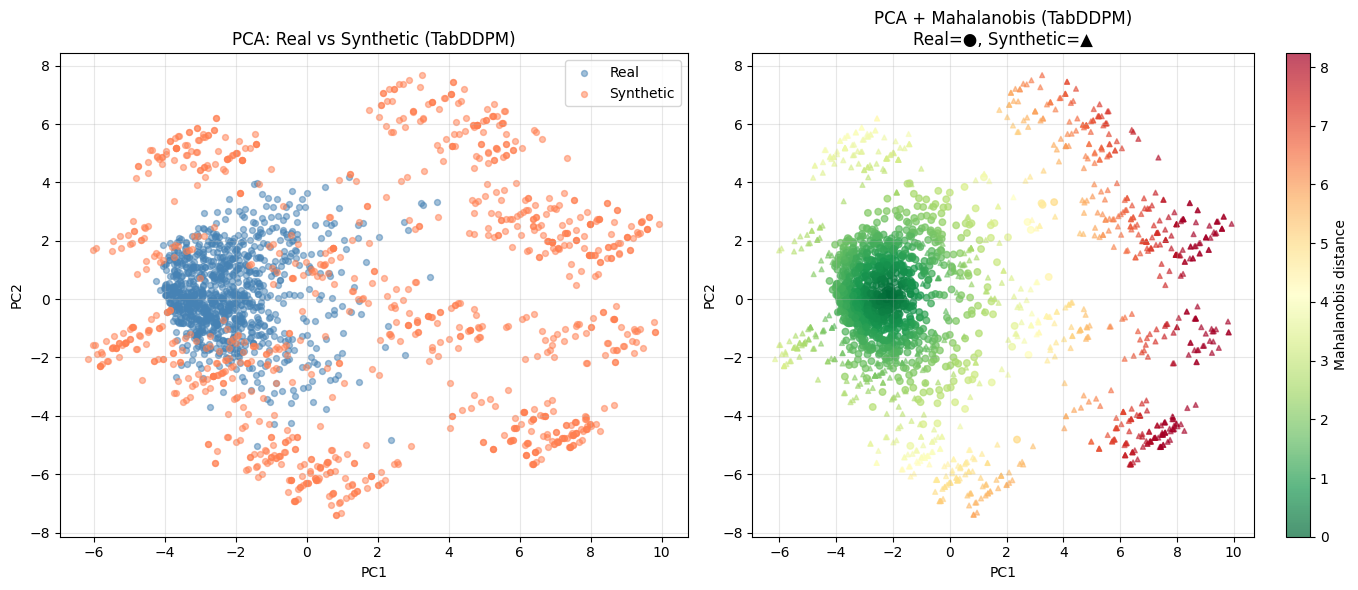

  Real mean MD: 1.2151, Synth mean MD: 5.0730, Delta: +3.8579

Processing ForestDiffusion: 1000 real vs 1000 synth


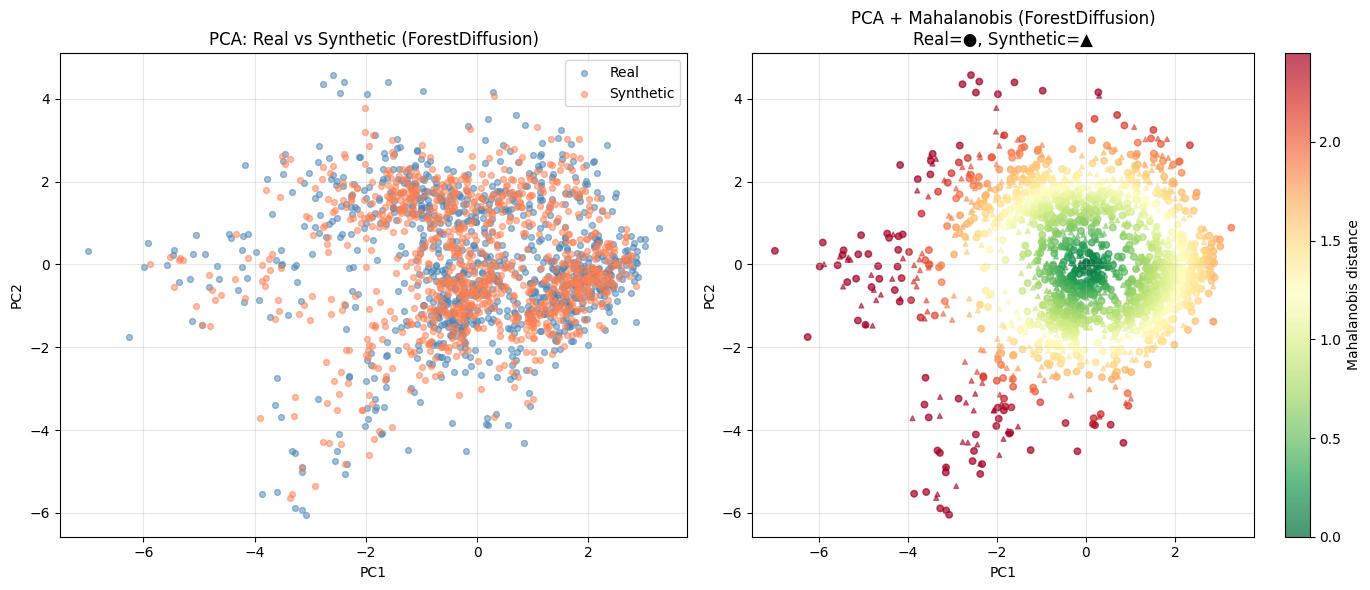

  Real mean MD: 1.2421, Synth mean MD: 1.1671, Delta: -0.0750

Adult Dataset: Summary PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
1,ForestDiffusion,1.242142,1.167135,-0.075007
0,TabDDPM,1.215090,5.072992,3.857902


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

# Direct pipeline reference
synth_source = synthetic_outputs

model_order = ["TabDDPM", "ForestDiffusion"]
real_df = real_sample.copy()
target_col = "Cover_Type"
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_real_df = _coerce_numeric_df(real_df, feature_cols)
real_medians = X_real_df.median(numeric_only=True)
X_r = X_real_df.fillna(real_medians).to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic_outputs, skipping.")
        continue

    synth_df = synth_source[model_name].copy()
    X_s = _coerce_numeric_df(synth_df, feature_cols).fillna(real_medians).to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    print(f"\n{'='*60}")
    print(f"Processing {model_name}: {X_r.shape[0]} real vs {X_s.shape[0]} synth")
    print(f"{'='*60}")

    # PCA on combined data
    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    # Mahalanobis in PCA space (real distribution reference)
    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    # Plot 1: PCA scatter
    fig, axes = plt.subplots(1, len(model_order), figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Mahalanobis distance color-coded
    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"  Real mean MD: {d_r.mean():.4f}, Synth mean MD: {d_s.mean():.4f}, Delta: {d_s.mean()-d_r.mean():+.4f}")

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

# Summary table
if rows:
    summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
    print("\nAdult Dataset: Summary PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):")
    display(summary_df)
else:
    print("No valid models found.")


In [58]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Adult_Hungarian_Mahalanobis.xlsx"
):
    # Fixed model names to match your pipeline
    model_order = ["TabDDPM", "ForestDiffusion"]  # Match hungarian_results keys

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                print(f"Skipping {model_name}: missing data or results")
                continue

            synth_df = synthetic_data[model_name].copy()
            synth_df = _coerce_numeric_df(synth_df, num_cols).fillna(real_medians)

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            # Flexible distance key detection
            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                print(f"No distance array found for {model_name}, skipping")
                continue

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                # Limit to first 10 numeric features for Excel practicality
                for c in num_cols[:10]:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = model_name[:31]  # Excel sheet name limit
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✓ Exported {len(matched_df)} matches for {model_name}")

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            print("\nSummary table:")
            display(summary_df)

    print(f"\n✅ Excel file created: {filename}")

# ---- Run with your actual pipeline variables ----
synth_source = synthetic_outputs  # Your generation results
real_df = real_sample.copy()
target_col = "Cover_Type"
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]
real_aligned = _coerce_numeric_df(real_df, num_cols)
real_medians = real_aligned.median(numeric_only=True)

print(f"Forest Cover Dataset: {len(real_df)} samples, {len(num_cols)} numeric features")
print(f"Target column: {target_col}")
print(f"Available models: {list(synth_source.keys())}")
print(f"Hungarian results keys: {list(hungarian_results.keys()) if 'hungarian_results' in globals() else 'Not found'}")

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,  # From your Hungarian matching cell
    num_cols=num_cols,
    filename="ForestCover_Hungarian_Mahalanobis.xlsx"
)


Forest Cover Dataset: 1000 samples, 14 numeric features
Target column: Cover_Type
Available models: ['TabDDPM', 'ForestDiffusion']
Hungarian results keys: ['TabDDPM', 'ForestDiffusion']
✓ Exported 1000 matches for TabDDPM
✓ Exported 1000 matches for ForestDiffusion

Summary table:


,Model,Num_Matches,Mean_Distance,Median_Distance,Std_Distance,Min_Distance,Max_Distance
1,ForestDiffusion,1000,10.213563,1.699339,62.492556,0.058110,500.092431
0,TabDDPM,1000,636.119261,502.141315,409.453674,12.106948,1505.667604



✅ Excel file created: ForestCover_Hungarian_Mahalanobis.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [59]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

# Fixed for Adult dataset pipeline
target_col = "Cover_Type"
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns if c != target_col]
model_order = ["TabDDPM", "ForestDiffusion"]

# Clean and encode real data once
real_df = real_sample.copy()
real_features = _coerce_numeric_df(real_df, feature_cols)
real_medians = real_features.median(numeric_only=True)
real_df[feature_cols] = real_features.fillna(real_medians)
le = LabelEncoder()
y_real_encoded = le.fit_transform(clean_cover_type_labels(real_df[target_col]))  # Use clean labels

results = []

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not in synthetic_outputs")
        continue

    print(f"\n{'='*50}")
    print(f"MIA for {model_name}")
    print(f"{'='*50}")

    synth_df = synthetic_outputs[model_name].copy()
    synth_features = _coerce_numeric_df(synth_df, feature_cols).fillna(real_medians)
    synth_df[feature_cols] = synth_features

    # Encode synthetic labels using same encoder
    y_synth_encoded = le.transform(clean_cover_type_labels(synth_df[target_col]))

    X_train = real_df[feature_cols].to_numpy(dtype=float)
    y_train = y_real_encoded

    X_test = synth_df[feature_cols].to_numpy(dtype=float)
    y_test = y_synth_encoded

    model = LogisticRegression(max_iter=1000, random_state=42)
    metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)

    metrics["Model"] = model_name
    results.append(metrics)

    print(f"  AUC: {metrics['AUC']:.4f}")
    print(f"  Advantage: {metrics['Advantage']:.4f}")
    print(f"  TPR@FPR=0.01: {metrics['TPR_at_FPR_001']:.4f}")

# Summary
if results:
    summary_df = pd.DataFrame(results).set_index("Model")
    print("\nMIA Results (LOWER AUC = BETTER privacy protection):")
    display(summary_df.sort_values("AUC"))
else:
    print("No valid models found.")



MIA for TabDDPM
  AUC: 0.9407
  Advantage: 0.8350
  TPR@FPR=0.01: 0.0000

MIA for ForestDiffusion
  AUC: 0.4803
  Advantage: 0.0270
  TPR@FPR=0.01: 0.0320

MIA Results (LOWER AUC = BETTER privacy protection):


,AUC,Advantage,TPR_at_FPR_001
Model,,,
ForestDiffusion,0.480298,0.027,0.032
TabDDPM,0.940729,0.835,0.000


In [60]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

# Fixed for Adult dataset pipeline
feature_cols = [c for c in real_sample.select_dtypes(include=[np.number]).columns
                if c != "Cover_Type"]
real_features = _coerce_numeric_df(real_sample, feature_cols)
real_medians = real_features.median(numeric_only=True)
X_train = real_features.fillna(real_medians).to_numpy(dtype=float)

model_order = ["TabDDPM", "ForestDiffusion"]
rows = []

print("Mahalanobis MIA - Real vs Synthetic (Adult Dataset)")
print("="*70)

for model_name in model_order:
    if model_name not in synthetic_outputs:
        print(f"✗ {model_name} not in synthetic_outputs, skipping")
        continue

    print(f"\n✓ Processing {model_name}...")
    X_test = _coerce_numeric_df(synthetic_outputs[model_name], feature_cols).fillna(real_medians).to_numpy(dtype=float)

    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

# Results table
if rows:
    comparison_df = pd.DataFrame(rows)[
        ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
    ].sort_values("AUC", ascending=False).reset_index(drop=True)

    print("\nMIA (Mahalanobis Distance) Results:")
    print("• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)")
    print("• Train/Test MD: How far synthetic samples are from real distribution")
    print("• LOWER AUC = BETTER privacy protection")
    display(comparison_df)

    # Privacy ranking
    print("\nPrivacy Ranking (LOWER AUC = BETTER privacy):")
    ranked = comparison_df.sort_values("AUC").reset_index(drop=True)
    for idx, row in ranked.iterrows():
        rank_emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
        print(f"{rank_emoji} {row['Model']}: AUC={row['AUC']:.3f} | Test_MD={row['Test_MD_Mean']:.3f}")
else:
    print("No valid models found.")


Mahalanobis MIA - Real vs Synthetic (Adult Dataset)

✓ Processing TabDDPM...

✓ Processing ForestDiffusion...

MIA (Mahalanobis Distance) Results:
• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)
• Train/Test MD: How far synthetic samples are from real distribution
• LOWER AUC = BETTER privacy protection


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,TabDDPM,1.000000,1.000,1.00,3.43779,1625.165183
1,ForestDiffusion,0.518599,0.087,0.01,3.43779,24.377295



Privacy Ranking (LOWER AUC = BETTER privacy):
🥇 ForestDiffusion: AUC=0.519 | Test_MD=24.377
🥈 TabDDPM: AUC=1.000 | Test_MD=1625.165
